# Omni ChromHMM SAGAconf Analysis

## Compute

In [1]:
import os
import sys
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import importlib

# Load configuration
config_path = "config_sagaconf.yaml"
if not os.path.exists(config_path):
    config_path = os.path.abspath(os.path.expanduser("~/work/omni-chromhmm/config_sagaconf.yaml"))

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

project_root = os.path.dirname(os.path.abspath(config_path))
scripts_dir = os.path.join(project_root, "scripts", "analysis")
scripts_rules_dir = os.path.join(project_root, "scripts", "rules")
scripts_root_dir = os.path.join(project_root, "scripts")
workdir = os.path.expanduser(config.get("workdir", "."))

sys.path.insert(0, scripts_dir)
sys.path.insert(0, scripts_rules_dir)
sys.path.insert(0, scripts_root_dir)

import match
import utils
import analyze
import compare
import compare_methods
import summary_plots
import interpretation
from IPython.display import Image, display
import glob
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor, as_completed

# Re-import the analysis modules
for _m in (analyze, match, compare, compare_methods, summary_plots, utils, interpretation):
    importlib.reload(_m)

method_palette = {
    "ChromHMM": utils.BIN_COLORS["default"],
    "HOMER": utils.BIN_COLORS["homer"],
    "MACS2": utils.BIN_COLORS["macs2"],
    "OmniPeak": utils.BIN_COLORS["omnipeak"],
    "HOMER KMeans": utils.BIN_COLORS["homer"],
    "MACS2 KMeans": utils.BIN_COLORS["macs2"],
    "OmniPeak KMeans": utils.BIN_COLORS["omnipeak"],
    "Joint ChromHMM": utils.BIN_COLORS["default"],
    "Joint HOMER KMeans": utils.BIN_COLORS["homer"],
    "Joint MACS2 KMeans": utils.BIN_COLORS["macs2"],
    "Joint OmniPeak KMeans": utils.BIN_COLORS["omnipeak"],
}

os.chdir(workdir)
os.makedirs("out/summary_plots", exist_ok=True)
print(f"Project root: {project_root}")
print(f"Workdir     : {workdir}")

P = config["params"]
DATASETS = config["datasets"]
NSTATES = P["n_states"]
MATCH_METHOD = "matched"
DO_REPLICATES = P.get("replicates", False)

METHOD_LABELS = [
    ("chromhmm_default", "ChromHMM"),
    ("kmeans_homer", "HOMER KMeans"),
    ("kmeans_macs2", "MACS2 KMeans"),
    ("kmeans_omni", "OmniPeak KMeans"),
    ("joint_chromhmm", "Joint ChromHMM"),
    ("joint_kmeans_homer", "Joint HOMER KMeans"),
    ("joint_kmeans_macs2", "Joint MACS2 KMeans"),
    ("joint_kmeans_omni", "Joint OmniPeak KMeans"),
]
METHOD_ORDER = [m[1] for m in METHOD_LABELS]
METHOD_MAP = dict(METHOD_LABELS)

def get_method_path(ds, method, rep=None):
    folder = ds
    if rep:
        folder = f"{ds}/{rep}"
    
    if method == "chromhmm_default":
        cell = DATASETS[ds]["cell"]
        return f"{folder}/chromhmm_default_result/{cell}_{NSTATES}_dense_matched.bed"
    if method == "joint_chromhmm":
        return f"{ds}/joint_chromhmm/{rep or 'rep1'}_{NSTATES}_dense.bed"
    if method.startswith("kmeans_"):
        caller = method.replace("kmeans_", "")
        return f"{folder}/{caller}/{caller}_kmeans_states_matched.bed"
    if method.startswith("joint_kmeans_"):
        caller = method.replace("joint_kmeans_", "")
        return f"{ds}/joint_kmeans/{caller}/{rep or 'rep1'}_kmeans_joint_states.bed"
    return None

# --- Segmentation layout of a dataset -------------------------------------
# get_method_path() above resolves one segmentation; these turn the (dataset,
# method, replicate) grid into the paths, bin sizes and directories the rest of
# the notebook works with, so the layout is written down exactly once.

CHROMHMM_BIN = P["chromhmm_bin"]


def method_bin_size(method_key):
    """Native bin size of a method (each peak caller keeps its own resolution)."""
    if "omni" in method_key:
        return P.get("omni_bin", 100)
    if "homer" in method_key:
        return P.get("homer_bin", 200)
    if "macs2" in method_key:
        return P.get("macs2_bin", 100)
    return CHROMHMM_BIN


def dataset_outdir(ds):
    """Directory holding the aggregated results of one dataset."""
    return f"out/{ds}/{MATCH_METHOD}"


def method_outdir(ds, method_key, rep):
    """Analysis directory of a single segmentation."""
    outdir = f"{dataset_outdir(ds)}/{method_key}"
    return outdir if rep == "rep1" else f"{outdir}_{rep}"


def dataset_reps(ds):
    """Replicates of a dataset: rep1 and rep2, or rep1 alone."""
    return ["rep1", "rep2"] if DATASETS[ds].get("replicates", True) else ["rep1"]


def dataset_segmentations(ds):
    """(method_key, method_name, rep, path) of every segmentation of ds on disk."""
    result = []
    for method_key, method_name in METHOD_LABELS:
        for rep in dataset_reps(ds):
            path = get_method_path(ds, method_key, rep)
            if path and os.path.exists(path):
                result.append((method_key, method_name, rep, path))
    return result


# --- Shared analysis helpers ----------------------------------------------

def nonempty(df):
    """Cache guard: an empty table means the inputs were not on disk yet."""
    return not df.empty


def load_per_dataset_tsv(filename):
    """Concatenated out/<ds>/matched/<filename> over every dataset.

    Adds the Dataset column and maps each segmentation label to its display
    Method, keeping only the methods of METHOD_ORDER. Empty until run_analysis()
    below has aggregated at least one dataset.
    """
    frames = []
    for ds in DATASETS:
        path = f"{dataset_outdir(ds)}/{filename}"
        if os.path.exists(path):
            df = pd.read_csv(path, sep="\t")
            df["Dataset"] = ds
            frames.append(df)
    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames)
    df["Method"] = df["segmentation"].map(
        lambda x: METHOD_MAP.get(x.replace("_rep1", "").replace("_rep2", ""), x))
    return df[df["Method"].isin(METHOD_ORDER)]


def compute_metrics(s1_path, s2_path):
    """Agreement of two segmentations, None when they cannot be compared.

    The metrics themselves come from match.agreement_metrics(); a pair that
    shares no state or never overlaps is reported as None and left out of the
    plots, rather than entering them as a row of zeros.
    """
    if not os.path.exists(s1_path) or not os.path.exists(s2_path):
        return None
    s1, s2 = match.load_bed(s1_path), match.load_bed(s2_path)
    l1, l2 = match.state_lengths(s1), match.state_lengths(s2)
    overlap = match.pair_overlap(s1, s2)
    states = set(l1) | set(l2)
    if not states or sum(overlap.get((a, b), 0) for a in states for b in states) == 0:
        return None
    return match.agreement_metrics(overlap, l1, l2)


def agreement_rows(pairs, desc):
    """DataFrame of compute_metrics() over (method_name, dataset, path1, path2)."""
    rows = []
    for method_name, ds, path1, path2 in tqdm(pairs, desc=desc):
        metrics = compute_metrics(path1, path2)
        if metrics:
            rows.append({"Method": method_name, "Dataset": ds, **metrics})
    return pd.DataFrame(rows)


Project root: /Users/Oleg.Shpynov/work/omni-chromhmm
Workdir     : /Users/Oleg.Shpynov/data/2026_sagaconf


## 5. General processing (emissions and enrichment)

In [2]:
# Configuration for analysis
GENCODE_GTF = config["tools"].get("gencode_gtf")
COORDS_DIR = config["tools"].get("coords_dir")
annotations = sorted(glob.glob(os.path.join(workdir, COORDS_DIR, "*.bed.gz"))) if COORDS_DIR else []

# Bump after changing analyze.py / compare.py to invalidate every cached aggregation.
ANALYSIS_CACHE_VERSION = 1
# Produced by compare.run_compare and consumed by the plots below; a missing one
# invalidates the stamp, so deleting a result is enough to force a rerun.
COMPARE_OUTPUTS = ["segment_stats.tsv", "entropy_summary.tsv"]


def compare_signature(ds):
    """Identity of every input compare.run_compare() reads for this dataset:
    the segmentations, their emission matrices and their per-state reports."""
    items = []
    for method_key, _, rep, path in dataset_segmentations(ds):
        items.append({
            "label": f"{method_key}_{rep}",
            "bin": method_bin_size(method_key),
            "seg": utils.file_stamp(path),
            "bin_emissions": utils.file_stamp(path.replace(".bed", ".bin_emissions.npz")),
            "bw_emissions": utils.file_stamp(path.replace(".bed", ".bw_emissions.npz")),
            "report": utils.file_stamp(f"{method_outdir(ds, method_key, rep)}/report.tsv"),
        })
    return {"version": ANALYSIS_CACHE_VERSION, "skip_noqh": True, "items": items}


def run_analysis(force=False):
    """Analyze every segmentation, then aggregate the results per dataset.

    Both steps are cached, so re-running the cell only computes what is missing:
    a segmentation is skipped once its report.tsv is there, and the (expensive)
    aggregation of a dataset is skipped while its inputs are unchanged since the
    stamp of the cached run, out/<ds>/matched/compare_stamp.json.
    force=True recomputes everything.
    """
    futures = {}
    reanalyzed = set()   # datasets with a fresh analysis: aggregation must rerun
    # We use a subset of markers if necessary, but here we assume everything is set up.
    with ProcessPoolExecutor(max_workers=max(1, os.cpu_count() // 2)) as executor:
        for ds in DATASETS:
            for method_key, method_name, rep, path in dataset_segmentations(ds):
                outdir = method_outdir(ds, method_key, rep)
                if not force and os.path.exists(f"{outdir}/report.tsv"):
                    continue
                print(f"Analyzing {method_name} ({rep}) for {ds}...")

                # Determine inputs (binarized data)
                inputs = None
                if "chromhmm" in method_key:
                    inputs = [f"{ds}/{rep}/chromhmm_default/*.txt"]
                elif "kmeans" in method_key:
                    caller = method_key.replace("joint_", "").replace("kmeans_", "")
                    inputs = [f"{ds}/{rep}/{caller}/chromhmm_peaks/chr*.txt.gz"]

                reanalyzed.add(ds)
                fut = executor.submit(
                    analyze.run_analyze,
                    seg=path, bin_size=method_bin_size(method_key),
                    outdir=outdir,
                    inputs=inputs,
                    annotations=annotations,
                    bw_emissions=path.replace(".bed", ".bw_emissions.npz"),
                    emissions_only=False,
                    skip_noqh=True,
                )
                futures[fut] = f"{method_name} ({rep}) for {ds}"

    for fut in as_completed(futures):
        try:
            fut.result()
        except Exception as e:
            print(f"  ERROR: {futures[fut]}: {e}")

    # 2. Aggregation step: run compare.run_compare to produce segment_stats.tsv and entropy_summary.tsv
    for ds in DATASETS:
        segmentations = dataset_segmentations(ds)
        if not segmentations:
            continue

        comp_outdir = dataset_outdir(ds)
        stamp_path = f"{comp_outdir}/compare_stamp.json"
        # Stamped before the run, so a segmentation that changes while compare is
        # running is not recorded as already aggregated.
        signature = compare_signature(ds)
        outputs = [f"{comp_outdir}/{name}" for name in COMPARE_OUTPUTS]
        if not force and ds not in reanalyzed and utils.stamp_current(stamp_path, signature, outputs):
            print(f"Aggregation for {ds} is up to date, skipped.")
            continue

        segs = [path for _, _, _, path in segmentations]
        bins = [method_bin_size(method_key) for method_key, _, _, _ in segmentations]
        # Important: labels must follow the _rep1 / _rep2 convention for should_compare to work
        labels = [f"{method_key}_{rep}" for method_key, _, rep, _ in segmentations]

        print(f"Aggregating results for {ds}...")
        compare.run_compare(seg=segs, bins=bins, labels=labels, all_pairs=False,
                            outdir=comp_outdir, analysis_dir=comp_outdir,
                            skip_noqh=True)
        utils.save_stamp(stamp_path, signature)


# Run analysis if needed
run_analysis()


Analyzing ChromHMM (rep1) for mcf7...
Analyzing ChromHMM (rep2) for mcf7...
Analyzing HOMER KMeans (rep1) for mcf7...
Analyzing HOMER KMeans (rep2) for mcf7...
Analyzing MACS2 KMeans (rep1) for mcf7...
Analyzing MACS2 KMeans (rep2) for mcf7...
Analyzing OmniPeak KMeans (rep1) for mcf7...
Analyzing OmniPeak KMeans (rep2) for mcf7...
Analyzing Joint ChromHMM (rep1) for mcf7...
Analyzing Joint ChromHMM (rep2) for mcf7...
Analyzing Joint HOMER KMeans (rep1) for mcf7...
Analyzing Joint HOMER KMeans (rep2) for mcf7...
Analyzing Joint MACS2 KMeans (rep1) for mcf7...
Analyzing Joint MACS2 KMeans (rep2) for mcf7...
Analyzing Joint OmniPeak KMeans (rep1) for mcf7...
Analyzing Joint OmniPeak KMeans (rep2) for mcf7...
Analyzing ChromHMM (rep1) for gm12878...
Analyzing ChromHMM (rep2) for gm12878...
Analyzing HOMER KMeans (rep1) for gm12878...
Analyzing HOMER KMeans (rep2) for gm12878...
Analyzing MACS2 KMeans (rep1) for gm12878...
Analyzing MACS2 KMeans (rep2) for gm12878...
Analyzing OmniPeak KMe

  Report: 15 states -> out/mcf7/matched/chromhmm_default_rep2/report.tsv
  Report: 15 states -> out/mcf7/matched/kmeans_macs2_rep2/report.tsv
  Report: 15 states -> out/mcf7/matched/chromhmm_default/report.tsv
  Report: 15 states -> out/mcf7/matched/kmeans_omni_rep2/report.tsv
  Report: 15 states -> out/mcf7/matched/kmeans_homer_rep2/report.tsv
  Report: 15 states -> out/mcf7/matched/kmeans_macs2/report.tsv
  Report: 15 states -> out/mcf7/matched/kmeans_omni/report.tsv
  Report: 15 states -> out/mcf7/matched/kmeans_homer/report.tsv
  Report: 15 states -> out/mcf7/matched/joint_chromhmm/report.tsv
  Report: 15 states -> out/mcf7/matched/joint_chromhmm_rep2/report.tsv
  Report: 15 states -> out/mcf7/matched/joint_kmeans_homer/report.tsv
  Report: 15 states -> out/mcf7/matched/joint_kmeans_homer_rep2/report.tsv
  Report: 15 states -> out/mcf7/matched/joint_kmeans_macs2/report.tsv
  Report: 15 states -> out/mcf7/matched/joint_kmeans_macs2_rep2/report.tsv
  Report: 15 states -> out/mcf7/mat

Aggregating results for mcf7...
  chromhmm_default_rep1: total transition entropy = 0.2840
  chromhmm_default_rep2: total transition entropy = 0.1910
  kmeans_homer_rep1: total transition entropy = 0.4414
  kmeans_homer_rep2: total transition entropy = 0.3554
  kmeans_macs2_rep1: total transition entropy = 0.1802
  kmeans_macs2_rep2: total transition entropy = 0.1205
  kmeans_omni_rep1: total transition entropy = 0.2205
  kmeans_omni_rep2: total transition entropy = 0.1825
  joint_chromhmm: total transition entropy = 0.2764
  joint_chromhmm: total transition entropy = 0.2013
  joint_kmeans_homer: total transition entropy = 0.4538
  joint_kmeans_homer: total transition entropy = 0.3663
  joint_kmeans_macs2: total transition entropy = 0.1688
  joint_kmeans_macs2: total transition entropy = 0.1237
  joint_kmeans_omni: total transition entropy = 0.2324
  joint_kmeans_omni: total transition entropy = 0.1765
  saved out/mcf7/matched/entropy_summary.tsv
  saved out/mcf7/matched/entropy_summar

  Comparing 8 pairs (vs ref + same-method rep1/rep2) with 8 processes ...
similarity = 0.7090
similarity = 0.8095
similarity = 0.8088
similarity = 0.8178
similarity = 0.9446
similarity = 0.7709
similarity = 0.9484
similarity = 0.7812


  chromhmm_default_rep1 vs chromhmm_default_rep2: comp_sim=0.9770, kappa=0.4064, jaccard=0.2560, emission=0.8277
  joint_chromhmm_rep1 vs joint_chromhmm_rep2: comp_sim=0.9955, kappa=0.5243, jaccard=0.3748, emission=0.9531
  kmeans_macs2_rep1 vs kmeans_macs2_rep2: comp_sim=0.9998, kappa=0.4140, jaccard=0.1560, emission=0.7161
  joint_kmeans_macs2_rep1 vs joint_kmeans_macs2_rep2: comp_sim=0.9998, kappa=0.4547, jaccard=0.2141, emission=0.9402
  kmeans_homer_rep1 vs kmeans_homer_rep2: comp_sim=0.9980, kappa=0.4198, jaccard=0.2131, emission=0.8434
  kmeans_omni_rep1 vs kmeans_omni_rep2: comp_sim=0.9986, kappa=0.4626, jaccard=0.2457, emission=0.7468
  joint_kmeans_omni_rep1 vs joint_kmeans_omni_rep2: comp_sim=0.9964, kappa=0.4888, jaccard=0.2936, emission=0.9698
  joint_kmeans_homer_rep1 vs joint_kmeans_homer_rep2: comp_sim=0.9974, kappa=0.4671, jaccard=0.2954, emission=0.9704
  saved out/mcf7/matched/kappa_matrix.tsv
  saved out/mcf7/matched/composition_similarity_matrix.tsv
  saved out/mcf

...

  chromhmm_default_rep1 vs chromhmm_default_rep2: comp_sim=0.9949, kappa=0.6301, jaccard=0.3281, emission=0.9468
  kmeans_macs2_rep1 vs kmeans_macs2_rep2: comp_sim=1.0000, kappa=0.4760, jaccard=0.1799, emission=0.7905
  joint_kmeans_macs2_rep1 vs joint_kmeans_macs2_rep2: comp_sim=1.0000, kappa=0.5107, jaccard=0.2518, emission=0.9676
  joint_chromhmm_rep1 vs joint_chromhmm_rep2: comp_sim=0.9994, kappa=0.7032, jaccard=0.4666, emission=0.9833
  kmeans_omni_rep1 vs kmeans_omni_rep2: comp_sim=0.9982, kappa=0.4423, jaccard=0.2124, emission=0.8914
  joint_kmeans_omni_rep1 vs joint_kmeans_omni_rep2: comp_sim=0.9979, kappa=0.4923, jaccard=0.3121, emission=0.9800
  kmeans_homer_rep1 vs kmeans_homer_rep2: comp_sim=0.9999, kappa=0.4846, jaccard=0.2795, emission=0.9491
  joint_kmeans_homer_rep1 vs joint_kmeans_homer_rep2: comp_sim=0.9998, kappa=0.5136, jaccard=0.3437, emission=0.9816
  saved out/k562/matched/kappa_matrix.tsv
  saved out/k562/matched/composition_similarity_matrix.tsv
  saved out/k56

  Comparing 8 pairs (vs ref + same-method rep1/rep2) with 8 processes ...
similarity = 0.8341
similarity = 0.6858
similarity = 0.8571
similarity = 0.8702
similarity = 0.8682
similarity = 0.8597
similarity = 0.9628
similarity = 0.9606


  joint_chromhmm_rep1 vs joint_chromhmm_rep2: comp_sim=0.9967, kappa=0.7426, jaccard=0.5538, emission=0.9886
  chromhmm_default_rep1 vs chromhmm_default_rep2: comp_sim=0.9208, kappa=0.4462, jaccard=0.4732, emission=0.9249
  kmeans_omni_rep1 vs kmeans_omni_rep2: comp_sim=0.9989, kappa=0.6298, jaccard=0.3477, emission=0.8991
  joint_kmeans_macs2_rep1 vs joint_kmeans_macs2_rep2: comp_sim=1.0000, kappa=0.5535, jaccard=0.2814, emission=0.9546
  kmeans_homer_rep1 vs kmeans_homer_rep2: comp_sim=0.9997, kappa=0.6246, jaccard=0.3220, emission=0.8905
  joint_kmeans_homer_rep1 vs joint_kmeans_homer_rep2: comp_sim=0.9997, kappa=0.6720, jaccard=0.4130, emission=0.9935
  kmeans_macs2_rep1 vs kmeans_macs2_rep2: comp_sim=1.0000, kappa=0.5178, jaccard=0.2047, emission=0.8178
  joint_kmeans_omni_rep1 vs joint_kmeans_omni_rep2: comp_sim=0.9987, kappa=0.6627, jaccard=0.3964, emission=0.9707
  saved out/cd14_monocyte/matched/kappa_matrix.tsv
  saved out/cd14_monocyte/matched/composition_similarity_matrix.t

  Comparing 8 pairs (vs ref + same-method rep1/rep2) with 8 processes ...
similarity = 0.7937
similarity = 0.6808
similarity = 0.8555
similarity = 0.8602
similarity = 0.9752
similarity = 0.9741
similarity = 0.7975
similarity = 0.8099


  joint_chromhmm_rep1 vs joint_chromhmm_rep2: comp_sim=0.9988, kappa=0.6993, jaccard=0.5063, emission=0.9637
  chromhmm_default_rep1 vs chromhmm_default_rep2: comp_sim=0.9819, kappa=0.3412, jaccard=0.3051, emission=0.8668
  joint_kmeans_macs2_rep1 vs joint_kmeans_macs2_rep2: comp_sim=1.0000, kappa=0.5490, jaccard=0.2762, emission=0.9771
  kmeans_macs2_rep1 vs kmeans_macs2_rep2: comp_sim=1.0000, kappa=0.5077, jaccard=0.1846, emission=0.9016
  joint_kmeans_homer_rep1 vs joint_kmeans_homer_rep2: comp_sim=1.0000, kappa=0.5693, jaccard=0.3764, emission=0.9808
  kmeans_homer_rep1 vs kmeans_homer_rep2: comp_sim=0.9999, kappa=0.5553, jaccard=0.3182, emission=0.9532
  joint_kmeans_omni_rep1 vs joint_kmeans_omni_rep2: comp_sim=0.9980, kappa=0.6105, jaccard=0.3642, emission=0.9819
  kmeans_omni_rep1 vs kmeans_omni_rep2: comp_sim=0.9987, kappa=0.5767, jaccard=0.2651, emission=0.7880
  saved out/hela_s3/matched/kappa_matrix.tsv
  saved out/hela_s3/matched/composition_similarity_matrix.tsv
  saved o

## 0. Peak calling stats per methods

In [3]:
def compute_peak_stats():
    frames = []
    for ds in DATASETS:
        p = f"{ds}/peaks/peak_stats.tsv"
        if os.path.exists(p):
            df = pd.read_csv(p, sep='\t')
            # Filter marks based on DATASETS[ds]['marks'] if available
            if 'marks' in DATASETS[ds]:
                df = df[df['mark'].isin(DATASETS[ds]['marks'])]
            df['Dataset'] = ds
            frames.append(df)
    if not frames:
        return pd.DataFrame()
    df_all = pd.concat(frames)
    df_all['method'] = df_all['method'].replace('Default', 'ChromHMM')
    return df_all


df_peaks = utils.cached_pickle("out/df_peaks.pkl", compute_peak_stats,
                               label="peak statistics", valid=nonempty)

if not df_peaks.empty:

    order = ["ChromHMM", "HOMER", "MACS2", "OmniPeak"]
    marks_present = df_peaks['mark'].unique()
    # Canonical order from summary_plots.py
    MARK_ORDER = ["H3K4me3", "H3K27ac", "H3K4me1", "H3K36me3", "H3K9me3", "H3K27me3"]
    marks = [m for m in MARK_ORDER if m in marks_present]
    marks += sorted([m for m in marks_present if m not in MARK_ORDER])

    # Plot 1: Number of peaks
    plt.figure(figsize=(max(8, len(marks) * 0.8), 5))
    sns.barplot(data=df_peaks, x='mark', y='n_peaks', order=marks,
                hue='method', hue_order=order, palette=method_palette,
                capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
                edgecolor="lightgrey", linewidth=1)
    plt.title("Number of peaks per mark", fontsize=11, fontweight="bold")
    plt.ylabel("Count", fontsize=9)
    plt.grid(axis='y', alpha=0.3)
    utils.strip_points(plt.gca(), data=df_peaks, x='mark', y='n_peaks', order=marks,
                       hue='method', hue_order=order, size=2)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.legend(title="Method", fontsize=8, title_fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("out/summary_plots/n_peaks.png", bbox_inches='tight')
    plt.close()

    # Plot 2: Average peak length
    plt.figure(figsize=(max(8, len(marks) * 0.8), 5))
    sns.barplot(data=df_peaks, x='mark', y='mean_length', order=marks,
                hue='method', hue_order=order, palette=method_palette,
                capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
                edgecolor="lightgrey", linewidth=1)
    plt.title("Average peak length per mark", fontsize=11, fontweight="bold")
    plt.ylabel("Length (bp)", fontsize=9)
    plt.grid(axis='y', alpha=0.3)
    utils.strip_points(plt.gca(), data=df_peaks, x='mark', y='mean_length', order=marks,
                       hue='method', hue_order=order, size=2)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.legend(title="Method", fontsize=8, title_fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("out/summary_plots/peak_length.png", bbox_inches='tight')
    plt.close()


Computing peak statistics...
Saved peak statistics to out/df_peaks.pkl


## 1. Number of segments stats per methods

In [4]:
df_segs = utils.cached_pickle(
    "out/df_segs.pkl", lambda: load_per_dataset_tsv("segment_stats.tsv"),
    label="segment statistics", valid=nonempty)

if not df_segs.empty:

    plt.figure(figsize=(12, 5))
    sns.barplot(data=df_segs, x='Method', y='n_segments', order=METHOD_ORDER,
                palette=method_palette, hue='Method', dodge=False,
                capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
                edgecolor="lightgrey", linewidth=1)
    utils.strip_points(plt.gca(), data=df_segs, x='Method', y='n_segments', order=METHOD_ORDER, size=2)
    plt.title("Number of segments per method", fontsize=11, fontweight="bold")
    plt.ylabel("Number of segments", fontsize=9)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.grid(axis='y', alpha=0.3)
    # Add labels over error bars
    yrange = plt.gca().get_ylim()[1] - plt.gca().get_ylim()[0]
    for i, method in enumerate(METHOD_ORDER):
        vals = df_segs[df_segs["Method"] == method]["n_segments"]
        if vals.empty: continue
        m, s = vals.mean(), vals.sem()
        if pd.isna(m): continue
        top = max(m + (s if not pd.isna(s) else 0), vals.max())
        plt.text(i, top + yrange * 0.01, f"{int(m)}", ha="center", va="bottom", fontsize=6)
    plt.savefig("out/summary_plots/n_segments.png", bbox_inches='tight')
    plt.close()


Computing segment statistics...
Saved segment statistics to out/df_segs.pkl


## 2. Transition matrix entropy per method

In [5]:
df_entropy = utils.cached_pickle(
    "out/df_entropy.pkl", lambda: load_per_dataset_tsv("entropy_summary.tsv"),
    label="transition matrix entropy", valid=nonempty)

if not df_entropy.empty:

    plt.figure(figsize=(12, 5))
    sns.barplot(data=df_entropy, x='Method', y='total_entropy', order=METHOD_ORDER,
                palette=method_palette, hue='Method', dodge=False,
                capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
                edgecolor="lightgrey", linewidth=1)
    utils.strip_points(plt.gca(), data=df_entropy, x='Method', y='total_entropy', order=METHOD_ORDER, size=2)
    plt.title("Transition matrix entropy per method", fontsize=11, fontweight="bold")
    plt.ylabel("Entropy (bits)", fontsize=9)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.grid(axis='y', alpha=0.3)
    # Add labels over error bars
    yrange = plt.gca().get_ylim()[1] - plt.gca().get_ylim()[0]
    for i, method in enumerate(METHOD_ORDER):
        vals = df_entropy[df_entropy["Method"] == method]["total_entropy"]
        if vals.empty: continue
        m, s = vals.mean(), vals.sem()
        if pd.isna(m): continue
        top = max(m + (s if not pd.isna(s) else 0), vals.max())
        plt.text(i, top + yrange * 0.01, f"{m:.2f}", ha="center", va="bottom", fontsize=6)
    plt.savefig("out/summary_plots/entropy.png", bbox_inches='tight')
    plt.close()


Computing transition matrix entropy...
Saved transition matrix entropy to out/df_entropy.pkl


## 3. State composition and lengths

In [6]:
# Collect valid tasks for state-based analysis
valid_tasks = [(f"{ds}_{rep}", method_name, path)
               for ds in DATASETS
               for _, method_name, rep, path in dataset_segmentations(ds)]

def state_comp_worker(task):
    folder, method_name, path = task
    try:
        segs = match.load_bed(path)
        lengths_by_state = defaultdict(list)
        for row in segs:
            name = row[3]
            if not name or name == ".": continue
            if "Unknown" in name:
                raise ValueError(f"Unknown state detected in {path}: {name}")
            lengths_by_state[name].append(row[2] - row[1])

        tot_bp = sum(sum(ls) for ls in lengths_by_state.values())

        res = []
        for st, ls in lengths_by_state.items():
            res.append({
                "Dataset": folder,
                "Method": method_name,
                "State": st,
                "Fraction": sum(ls) / tot_bp if tot_bp > 0 else 0,
                "MeanLength": np.mean(ls),
                "MedianLength": np.median(ls)
            })
        return res
    except Exception as e:
        return []

def compute_state_composition():
    """(composition table, {state: hex color}) over every segmentation."""
    per_task = [state_comp_worker(t) for t in tqdm(valid_tasks)]
    df = pd.DataFrame([row for rows in per_task for row in rows])

    # State colors, from the itemRgb column of the segmentation BEDs
    colors_hex = {}
    for _, _, path in tqdm(valid_tasks, desc="Extracting state colors"):
        if not os.path.exists(path): continue
        for row in match.load_bed(path):
            name = row[3]
            color = row[8] if len(row) > 8 else None
            if name not in colors_hex and color and color != "0,0,0":
                colors_hex[name] = analyze.rgb_str_to_hex(color)
    return df, colors_hex


df_comp, state_colors_hex = utils.cached_pickle(
    "out/df_comp.pkl", compute_state_composition,
    label="state composition and lengths")

# Fill missing colors from summary_plots.STATE_COLORS
states_present = df_comp["State"].unique()
for s in states_present:
    if s not in state_colors_hex or state_colors_hex[s] == "#000000":
        name_part = s.split("_")[1] if "_" in s else s
        found_color = None
        for canonical, rgb in summary_plots.STATE_COLORS.items():
            if name_part.startswith(canonical):
                found_color = "#{:02x}{:02x}{:02x}".format(int(rgb[0]*255), int(rgb[1]*255), int(rgb[2]*255))
                break
        if found_color:
            state_colors_hex[s] = found_color
        else:
            state_colors_hex[s] = "#888888"

states_order = summary_plots.sort_states(df_comp["State"].unique())
# Plot 3a. Average state composition per method (broken axis)
df_comp_filled = df_comp.pivot_table(index=["Method", "Dataset"], columns="State", values="Fraction", fill_value=0).stack().reset_index(name="Fraction")

BREAK_LOW = 0.20
BREAK_HIGH = 0.40
figw = max(12, len(states_order) * len(METHOD_ORDER) * 0.22)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True,
    figsize=(figw, 6),
    gridspec_kw={"height_ratios": [1, 4], "hspace": 0.06},
)

for ax in (ax_top, ax_bot):
    sns.barplot(
        data=df_comp_filled, x="State", y="Fraction", hue="Method",
        order=states_order, hue_order=METHOD_ORDER, palette=method_palette,
        ax=ax, capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
        legend=(ax is ax_top), edgecolor="lightgrey", linewidth=1
    )
    utils.strip_points(ax, data=df_comp_filled, x="State", y="Fraction", hue="Method",
                       order=states_order, hue_order=METHOD_ORDER,
                       size=1.5, alpha=0.4, jitter=0.2)

ax_top.set_ylim(BREAK_HIGH, 1.02)
ax_bot.set_ylim(0, BREAK_LOW)
ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(axis="x", bottom=False)

d = 0.012
kwargs = dict(transform=fig.transFigure, color="k", clip_on=False, linewidth=0.8)
for ax, sign in [(ax_top, -1), (ax_bot, 1)]:
    x0, x1 = ax.get_position().x0, ax.get_position().x1
    y = ax.get_position().y0 if sign == 1 else ax.get_position().y1
    for x in (x0, x1):
        fig.add_artist(plt.Line2D([x - d, x + d], [y + sign * d * 1.5, y - sign * d * 1.5], **kwargs))

for ax in (ax_top, ax_bot):
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.tick_params(axis="y", labelsize=8)

ax_bot.tick_params(axis="x", labelsize=8, rotation=45)
ax_bot.set_xlabel("Chromatin state", fontsize=9)
ax_top.set_xlabel("")
ax_top.set_title("Average state composition per method", fontsize=10, fontweight="bold")
ax_top.legend(title="Method", fontsize=8, title_fontsize=9,
              bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
if ax_bot.get_legend(): ax_bot.get_legend().remove()
ax_bot.set_ylabel("Fraction of genome", fontsize=9)
ax_top.set_ylabel("")

plt.savefig("out/summary_plots/avg_composition.png", bbox_inches="tight")
plt.close(fig)

# Plot 3b. Average state mean length per method
plt.figure(figsize=(figw, 6))
ax = plt.gca()
sns.barplot(
    data=df_comp, x="State", y="MeanLength", hue="Method",
    order=states_order, hue_order=METHOD_ORDER, palette=method_palette,
    ax=ax, capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0}, edgecolor="lightgrey", linewidth=1
)
utils.strip_points(ax, data=df_comp, x="State", y="MeanLength", hue="Method",
                   order=states_order, hue_order=METHOD_ORDER,
                   size=1.5, alpha=0.4, jitter=0.2)
ax.set_yscale("log")
ax.set_title("Average state mean length per method", fontsize=10, fontweight="bold")
ax.set_ylabel("Mean length (bp, log scale)", fontsize=9)
ax.grid(axis="y", alpha=0.3, linewidth=0.5)
ax.tick_params(axis="x", labelsize=8, rotation=45)
ax.legend(title="Method", fontsize=8, title_fontsize=9,
          bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.savefig("out/summary_plots/avg_mean_length.png", bbox_inches="tight")
plt.close()

# Plot 3c. Average state median length per method
plt.figure(figsize=(figw, 6))
ax = plt.gca()
sns.barplot(
    data=df_comp, x="State", y="MedianLength", hue="Method",
    order=states_order, hue_order=METHOD_ORDER, palette=method_palette,
    ax=ax, capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0}, edgecolor="lightgrey", linewidth=1
)
utils.strip_points(ax, data=df_comp, x="State", y="MedianLength", hue="Method",
                   order=states_order, hue_order=METHOD_ORDER,
                   size=1.5, alpha=0.4, jitter=0.2)
ax.set_yscale("log")
ax.set_title("Average state median length per method", fontsize=10, fontweight="bold")
ax.set_ylabel("Median length (bp, log scale)", fontsize=9)
ax.grid(axis="y", alpha=0.3, linewidth=0.5)
ax.tick_params(axis="x", labelsize=8, rotation=45)
ax.legend(title="Method", fontsize=8, title_fontsize=9,
          bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.savefig("out/summary_plots/avg_median_length.png", bbox_inches="tight")
plt.close()

# Plot 3d. Summary average state composition per method (stacked)
pivot_avg = df_comp.pivot_table(index=["Method", "Dataset"], columns="State", values="Fraction", fill_value=0).groupby("Method").mean()
pivot_avg = pivot_avg.reindex(METHOD_ORDER)
avail_states = [s for s in states_order if s in pivot_avg.columns]
pivot_avg = pivot_avg[avail_states]
colors = [state_colors_hex.get(s, "#888888") for s in avail_states]

# Assert normalization to 1.0
if not np.allclose(pivot_avg.sum(axis=1), 1.0, atol=1e-5):
    raise ValueError("Average composition not normalized to 1.0")

plt.figure(figsize=(8, 5))
ax = pivot_avg.plot(kind="bar", stacked=True, color=colors, width=0.6, ax=plt.gca(), linewidth=0)
pivot_avg.sum(axis=1).plot(kind="bar", ax=ax, width=0.6, facecolor="none", edgecolor="lightgrey", linewidth=1, legend=False)
ax.set_title("Average state composition per method", fontsize=11, fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize="small", title="State")
ax.set_xlabel("Method", fontsize=9)
ax.set_ylabel("Average Fraction of Genome", fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.grid(axis="y", alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.savefig("out/summary_plots/avg_composition_stacked.png", bbox_inches="tight")
plt.close()

# Plot 3e. State composition per dataset for each method
for method in METHOD_ORDER:
    method_df = df_comp[df_comp["Method"] == method]
    if method_df.empty: continue
    pivot_df = method_df.pivot(index="Dataset", columns="State", values="Fraction").fillna(0)
    avail_states = [s for s in states_order if s in pivot_df.columns]
    pivot_df = pivot_df[avail_states]
    colors = [state_colors_hex.get(s, "#888888") for s in avail_states]

    # Assert normalization to 1.0
    if not np.allclose(pivot_df.sum(axis=1), 1.0, atol=1e-5):
        raise ValueError(f"Composition for method {method} not normalized to 1.0")

    ax = pivot_df.plot(kind="bar", stacked=True, figsize=(max(10, len(pivot_df)*0.5), 6), color=colors, width=0.8, linewidth=0)
    pivot_df.sum(axis=1).plot(kind="bar", ax=ax, width=0.8, facecolor="none", edgecolor="lightgrey", linewidth=1, legend=False)
    ax.set_title(f"State composition per dataset - {method}", fontsize=11, fontweight="bold")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize="small", title="State")
    ax.set_xlabel("Dataset", fontsize=9)
    ax.set_ylabel("Fraction of Genome", fontsize=9)
    ax.tick_params(axis="x", labelsize=8, rotation=45)
    fig = ax.get_figure()
    fig.tight_layout()
    fig.savefig(f"out/summary_plots/composition_{method.lower().replace(' ', '_')}.png", bbox_inches="tight")
    plt.close(fig)


Computing state composition and lengths...


  0%|          | 0/80 [00:00<?, ?it/s]

Extracting state colors:   0%|          | 0/80 [00:00<?, ?it/s]

Saved state composition and lengths to out/df_comp.pkl


## 4. Replicate consistency (Jaccard / Kappa)

In [7]:
def compute_replicate_agreement():
    """rep1 vs rep2 of the same method, for every dataset that has both."""
    pairs = [(method_name, ds,
              get_method_path(ds, method_key, "rep1"),
              get_method_path(ds, method_key, "rep2"))
             for ds in DATASETS
             if os.path.isdir(f"{ds}/rep1") and os.path.isdir(f"{ds}/rep2")
             for method_key, method_name in METHOD_LABELS
             if get_method_path(ds, method_key, "rep1")
             and get_method_path(ds, method_key, "rep2")]
    return agreement_rows(pairs, "Replicates")


df_rep = utils.cached_pickle("out/df_rep.pkl", compute_replicate_agreement,
                             label="replicate consistency", valid=nonempty)

if not df_rep.empty:

    # Plot 1: Jaccard
    plt.figure(figsize=(8, 6))
    sns.barplot(data=df_rep, x='Method', y='Jaccard', order=METHOD_ORDER,
                palette=method_palette, hue='Method', dodge=False,
                capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
                edgecolor="lightgrey", linewidth=1)
    utils.strip_points(plt.gca(), data=df_rep, x='Method', y='Jaccard', order=METHOD_ORDER, size=2)
    plt.title("Replicate Jaccard Similarity", fontsize=11, fontweight="bold")
    plt.ylabel("Jaccard", fontsize=9)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', alpha=0.3)
    # Add labels over error bars
    yrange = plt.gca().get_ylim()[1] - plt.gca().get_ylim()[0]
    for i, method in enumerate(METHOD_ORDER):
        vals = df_rep[df_rep["Method"] == method]["Jaccard"]
        if vals.empty: continue
        m, s = vals.mean(), vals.sem()
        if pd.isna(m): continue
        top = max(m + (s if not pd.isna(s) else 0), vals.max())
        plt.text(i, top + yrange * 0.01, f"{m:.2f}", ha="center", va="bottom", fontsize=6)
    plt.savefig("out/summary_plots/replicate_jaccard.png", bbox_inches='tight')
    plt.close()

    # Plot 2: Kappa
    plt.figure(figsize=(8, 6))
    sns.barplot(data=df_rep, x='Method', y='Kappa', order=METHOD_ORDER,
                palette=method_palette, hue='Method', dodge=False,
                capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
                edgecolor="lightgrey", linewidth=1)
    utils.strip_points(plt.gca(), data=df_rep, x='Method', y='Kappa', order=METHOD_ORDER, size=2)
    plt.title("Replicate Cohen's Kappa", fontsize=11, fontweight="bold")
    plt.ylabel("Kappa", fontsize=9)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', alpha=0.3)
    # Add labels over error bars
    yrange = plt.gca().get_ylim()[1] - plt.gca().get_ylim()[0]
    for i, method in enumerate(METHOD_ORDER):
        vals = df_rep[df_rep["Method"] == method]["Kappa"]
        if vals.empty: continue
        m, s = vals.mean(), vals.sem()
        if pd.isna(m): continue
        top = max(m + (s if not pd.isna(s) else 0), vals.max())
        plt.text(i, top + yrange * 0.01, f"{m:.2f}", ha="center", va="bottom", fontsize=6)
    plt.savefig("out/summary_plots/replicate_kappa.png", bbox_inches='tight')
    plt.close()


Computing replicate consistency...


Replicates:   0%|          | 0/40 [00:00<?, ?it/s]

Saved replicate consistency to out/df_rep.pkl


## 4. Individual vs Joint correspondence (Jaccard / Kappa)

In [8]:
# Each peak caller, segmented on its own dataset vs segmented jointly.
COMP_PAIRS = [
    ("ChromHMM", "chromhmm_default", "joint_chromhmm"),
    ("HOMER", "kmeans_homer", "joint_kmeans_homer"),
    ("MACS2", "kmeans_macs2", "joint_kmeans_macs2"),
    ("OmniPeak", "kmeans_omni", "joint_kmeans_omni"),
]


def compute_joint_indiv_agreement():
    pairs = [(name, ds,
              get_method_path(ds, indiv_key, "rep1"),
              get_method_path(ds, joint_key, "rep1"))
             for ds in DATASETS
             for name, indiv_key, joint_key in COMP_PAIRS
             if get_method_path(ds, indiv_key, "rep1")
             and get_method_path(ds, joint_key, "rep1")]
    return agreement_rows(pairs, "Joint vs Individual")


df_ji = utils.cached_pickle("out/df_ji.pkl", compute_joint_indiv_agreement,
                            label="joint vs individual consistency", valid=nonempty)

if not df_ji.empty:
    order = ["ChromHMM", "HOMER", "MACS2", "OmniPeak"]

    # Plot 1: Jaccard
    plt.figure(figsize=(7, 6))
    sns.barplot(data=df_ji, x='Method', y='Jaccard', order=order,
                palette=method_palette, hue='Method', dodge=False,
                capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
                edgecolor="lightgrey", linewidth=1)
    utils.strip_points(plt.gca(), data=df_ji, x='Method', y='Jaccard', order=order, size=2)
    plt.title("Individual vs Joint Jaccard", fontsize=11, fontweight="bold")
    plt.ylabel("Jaccard", fontsize=9)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', alpha=0.3)
    # Add labels over error bars
    yrange = plt.gca().get_ylim()[1] - plt.gca().get_ylim()[0]
    for i, method_name in enumerate(order):
        vals = df_ji[df_ji["Method"] == method_name]["Jaccard"]
        if vals.empty: continue
        m, s = vals.mean(), vals.sem()
        if pd.isna(m): continue
        top = max(m + (s if not pd.isna(s) else 0), vals.max())
        plt.text(i, top + yrange * 0.01, f"{m:.2f}", ha="center", va="bottom", fontsize=6)
    plt.savefig("out/summary_plots/joint_indiv_jaccard.png", bbox_inches='tight')
    plt.close()

    # Plot 2: Kappa
    plt.figure(figsize=(7, 6))
    sns.barplot(data=df_ji, x='Method', y='Kappa', order=order,
                palette=method_palette, hue='Method', dodge=False,
                capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
                edgecolor="lightgrey", linewidth=1)
    utils.strip_points(plt.gca(), data=df_ji, x='Method', y='Kappa', order=order, size=2)
    plt.title("Individual vs Joint Kappa", fontsize=11, fontweight="bold")
    plt.ylabel("Kappa", fontsize=9)
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis='y', alpha=0.3)
    # Add labels over error bars
    yrange = plt.gca().get_ylim()[1] - plt.gca().get_ylim()[0]
    for i, method_name in enumerate(order):
        vals = df_ji[df_ji["Method"] == method_name]["Kappa"]
        if vals.empty: continue
        m, s = vals.mean(), vals.sem()
        if pd.isna(m): continue
        top = max(m + (s if not pd.isna(s) else 0), vals.max())
        plt.text(i, top + yrange * 0.01, f"{m:.2f}", ha="center", va="bottom", fontsize=6)
    plt.savefig("out/summary_plots/joint_indiv_kappa.png", bbox_inches='tight')
    plt.close()


Computing joint vs individual consistency...


Joint vs Individual:   0%|          | 0/20 [00:00<?, ?it/s]

Saved joint vs individual consistency to out/df_ji.pkl


## 6. Chromatin state type interpretation


In [9]:
# The interpretation itself lives in scripts/interpretation.py: it turns the
# per-state evidence of a segmentation (bin_emissions/state_emissions.tsv,
# enrichment/enrichment.tsv, report.tsv, entropy/transition_matrix.tsv) into one
# of the chromatin state types of the table shipped next to it,
# scripts/interpretation.csv.
TYPES_TABLE = interpretation.load_interpretation_table()
TYPE_ORDER = list(TYPES_TABLE.index)                    # order used in the CSV
TYPE_SHORT = TYPES_TABLE["Short Name"].to_dict()
TYPE_COLORS = interpretation.TYPE_COLORS

print(f"Chromatin state types from {interpretation.DEFAULT_INTERPRETATION_CSV}:")
display(TYPES_TABLE)
print("Marks per type family:", interpretation.MARK_GROUPS)

Chromatin state types from /Users/Oleg.Shpynov/work/omni-chromhmm/scripts/interpretation.csv:


,Short Name,Description
Chromatin State Type,,
Promoter,Prom,Presence of promoter-associated marks H3K4me3 ...
PromoterFlanking,Prom fla,Presence of promoter-associated marks H3K4me3 ...
Enhancer,Enha,Presence of the enhancer-associated marks H3K2...
EnhancerLow,Enha low,"Same as Enhancer, but with lower signal values."
Bivalent,Biva,Presence of both activating (H3K27ac) and repr...
CTCF,CTCF,"Presence of the transcription factor CTCF, tho..."
Transcribed,Tran,Characterized by the transcription-associated ...
K9K36,K9K36,"Presence of the marks H3K9me3 and H3K36me3, a ..."
FacultativeHet,Facu,"Facultative (Polycomb) Heterochromatin, charac..."


Marks per type family: {'prom': {'H3K4me3': 1.0, 'H3K9ac': 0.8, 'H3K4me2': 0.4, 'H2AFZ': 0.3}, 'enh': {'H3K27ac': 1.0, 'H3K4me1': 1.0}, 'tx': {'H3K36me3': 1.0, 'H3K79me2': 0.4, 'H4K20me1': 0.3}, 'facu': {'H3K27me3': 1.0}, 'cons': {'H3K9me3': 1.0, 'H3K9me2': 0.4}, 'ctcf': {'CTCF': 1.0}}


In [10]:
def compute_interpretation():
    """One row per state of every segmentation analyzed by run_analysis()."""
    MATCHING_JOINT = {
        "ChromHMM": "Joint ChromHMM",
        "HOMER KMeans": "Joint HOMER KMeans",
        "MACS2 KMeans": "Joint MACS2 KMeans",
        "OmniPeak KMeans": "Joint OmniPeak KMeans",
    }

    # 1. Precompute joint interpretations (once per dataset, as they are joint)
    joint_interpretations = {} # (ds, joint_method_name) -> df
    for ds in tqdm(DATASETS, desc="Joint Interpretation"):
        for method_key, method_name in METHOD_LABELS:
            if method_name in MATCHING_JOINT.values():
                # For joint models, we use rep1 to get the common interpretation
                outdir = method_outdir(ds, method_key, "rep1")
                df = interpretation.interpret_segmentation(outdir, TYPES_TABLE)
                if df is not None:
                    joint_interpretations[(ds, method_name)] = df

    # 2. Assign interpretations to all segmentations
    interpretations = []
    for ds in tqdm(DATASETS, desc="Interpretation"):
        reps = dataset_reps(ds)
        for rep in reps:
            for method_key, method_name in METHOD_LABELS:
                outdir = method_outdir(ds, method_key, rep)
                
                joint_name = MATCHING_JOINT.get(method_name)
                if joint_name:
                    # Individual method: transfer from its joint counterpart
                    joint_df = joint_interpretations.get((ds, joint_name))
                    if joint_df is None:
                        continue
                    
                    # Still need the individual report for its specific genome stats
                    ev = interpretation.load_segmentation_evidence(outdir)
                    if ev is None or ev.get("report") is None:
                        continue
                        
                    df = joint_df.copy()
                    # Preserve individual stats
                    rep_stats = ev["report"]
                    # Ensure alignment of states between individual and joint model
                    df["Fraction"] = rep_stats["total_bp"].reindex(df.index) / rep_stats["total_bp"].sum()
                    df["MedianLength"] = rep_stats["median_length"].reindex(df.index)
                    if ev.get("self_transition") is not None:
                        df["SelfTransition"] = ev["self_transition"].reindex(df.index)
                    else:
                        df["SelfTransition"] = np.nan
                else:
                    # Joint method or other: interpret normally (already computed or fresh)
                    if (ds, method_name) in joint_interpretations:
                        df = joint_interpretations[(ds, method_name)].copy()
                        # Update stats for the specific replicate if they differ
                        ev = interpretation.load_segmentation_evidence(outdir)
                        if ev is not None and ev.get("report") is not None:
                             rep_stats = ev["report"]
                             df["Fraction"] = rep_stats["total_bp"].reindex(df.index) / rep_stats["total_bp"].sum()
                             df["MedianLength"] = rep_stats["median_length"].reindex(df.index)
                             if ev.get("self_transition") is not None:
                                 df["SelfTransition"] = ev["self_transition"].reindex(df.index)
                    else:
                        df = interpretation.interpret_segmentation(outdir, TYPES_TABLE)
                
                if df is not None:
                    df = df.reset_index().rename(columns={"state": "State", "index": "State"})
                    df.insert(0, "Rep", rep)
                    df.insert(0, "Method", method_name)
                    df.insert(0, "Dataset", ds)
                    interpretations.append(df)
    return pd.concat(interpretations, ignore_index=True) if interpretations else pd.DataFrame()


df_interp = utils.cached_pickle("out/df_interp_matched.pkl", compute_interpretation,
                                label="state interpretation")

if not df_interp.empty:
    interp_tsv = "out/state_interpretation.tsv"
    df_interp.to_csv(interp_tsv, sep="\t", index=False, float_format="%.4f")
    print(f"{len(df_interp)} states of {len(df_interp.groupby(['Dataset', 'Rep', 'Method']))} "
          f"segmentations interpreted -> {interp_tsv}")

    # Interpreted type of every state, per dataset.
    for ds in DATASETS:
        for rep in ["rep1", "rep2"]:
            mat = interpretation.type_matrix(df_interp, ds, rep, methods=METHOD_ORDER)
            if mat.empty:
                continue
            print(f"\n### {ds} ({rep})")
            display(mat)

    # Types never assigned by any method — CTCF is expected here, none of these
    # datasets measures CTCF, and the table has no mark-based fallback for it.
    missing = [t for t in TYPE_ORDER if t not in set(df_interp["Type"])]
    print(f"\nTypes not assigned in any segmentation: {missing or 'none'}")


Computing state interpretation...


Joint Interpretation:   0%|          | 0/5 [00:00<?, ?it/s]

Interpretation:   0%|          | 0/5 [00:00<?, ?it/s]

Saved state interpretation to out/df_interp_matched.pkl
1200 states of 80 segmentations interpreted -> out/state_interpretation.tsv

### mcf7 (rep1)


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
ChromHMM,Enha low,Enha,Enha,Prom,Prom,Enha,Tran,Tran,Quie,Tran,K9K36,Facu,Quie,Facu,Cons
HOMER KMeans,Quie,Enha,Tran,Enha,Prom,Enha,Enha low,Cons,Facu,Tran,Enha,Tran,Tran,K9K36,Enha
MACS2 KMeans,Quie,Enha low,Enha,Prom,Enha low,Enha,Prom,Tran,Enha,Tran,Prom fla,Prom,Enha,Prom,Cons
OmniPeak KMeans,Facu,Quie,Enha,Tran,Tran,K9K36,Tran,Prom,Enha,Cons,Enha low,Tran,Tran,Cons,Enha
Joint ChromHMM,Enha low,Enha,Enha,Prom,Prom,Enha,Tran,Tran,Quie,Tran,K9K36,Facu,Quie,Facu,Cons
Joint HOMER KMeans,Quie,Enha,Tran,Enha,Prom,Enha,Enha low,Cons,Facu,Tran,Enha,Tran,Tran,K9K36,Enha
Joint MACS2 KMeans,Quie,Enha low,Enha,Prom,Enha low,Enha,Prom,Tran,Enha,Tran,Prom fla,Prom,Enha,Prom,Cons
Joint OmniPeak KMeans,Facu,Quie,Enha,Tran,Tran,K9K36,Tran,Prom,Enha,Cons,Enha low,Tran,Tran,Cons,Enha


...


### hela_s3 (rep1)


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
ChromHMM,Quie,Cons,Quie,Facu,Tran,Quie,Tran,Tran,Prom,Enha,Prom,Prom,Enha,Enha low,Enha
HOMER KMeans,Quie,Tran,Enha,Facu,Tran,Tran,Cons,Enha low,Enha low,Tran,Enha,Enha,Prom fla,Tran,Prom
MACS2 KMeans,Quie,Enha low,Prom,Enha,Prom,Prom,Enha,Enha low,Prom fla,Enha,Enha low,Tran,Prom,Prom fla,Prom
OmniPeak KMeans,Quie,Facu,Tran,Prom,Prom,Enha low,Tran,Tran,Enha,Tran,Enha,Facu,Tran,Cons,Facu
Joint ChromHMM,Quie,Cons,Quie,Facu,Tran,Quie,Tran,Tran,Prom,Enha,Prom,Prom,Enha,Enha low,Enha
Joint HOMER KMeans,Quie,Tran,Enha,Facu,Tran,Tran,Cons,Enha low,Enha low,Tran,Enha,Enha,Prom fla,Tran,Prom
Joint MACS2 KMeans,Quie,Enha low,Prom,Enha,Prom,Prom,Enha,Enha low,Prom fla,Enha,Enha low,Tran,Prom,Prom fla,Prom
Joint OmniPeak KMeans,Quie,Facu,Tran,Prom,Prom,Enha low,Tran,Tran,Enha,Tran,Enha,Facu,Tran,Cons,Facu



### hela_s3 (rep2)


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
ChromHMM,Quie,Cons,Quie,Facu,Tran,Quie,Tran,Tran,Prom,Enha,Prom,Prom,Enha,Enha low,Enha
HOMER KMeans,Quie,Tran,Enha,Facu,Tran,Tran,Cons,Enha low,Enha low,Tran,Enha,Enha,Prom fla,Tran,Prom
MACS2 KMeans,Quie,Enha low,Prom,Enha,Prom,Prom,Enha,Enha low,Prom fla,Enha,Enha low,Tran,Prom,Prom fla,Prom
OmniPeak KMeans,Quie,Facu,Tran,Prom,Prom,Enha low,Tran,Tran,Enha,Tran,Enha,Facu,Tran,Cons,Facu
Joint ChromHMM,Quie,Cons,Quie,Facu,Tran,Quie,Tran,Tran,Prom,Enha,Prom,Prom,Enha,Enha low,Enha
Joint HOMER KMeans,Quie,Tran,Enha,Facu,Tran,Tran,Cons,Enha low,Enha low,Tran,Enha,Enha,Prom fla,Tran,Prom
Joint MACS2 KMeans,Quie,Enha low,Prom,Enha,Prom,Prom,Enha,Enha low,Prom fla,Enha,Enha low,Tran,Prom,Prom fla,Prom
Joint OmniPeak KMeans,Quie,Facu,Tran,Prom,Prom,Enha low,Tran,Tran,Enha,Tran,Enha,Facu,Tran,Cons,Facu



Types not assigned in any segmentation: ['CTCF']


Average fraction of genome per interpreted type:


Type,Promoter,PromoterFlanking,Enhancer,EnhancerLow,Bivalent,CTCF,Transcribed,K9K36,FacultativeHet,ConstitutiveHet,Quiescent
Method,,,,,,,,,,,
ChromHMM,0.0103,0.0047,0.0361,0.0141,0.0008,0.0,0.0663,0.0006,0.0359,0.0124,0.8188
HOMER KMeans,0.0122,0.0079,0.0268,0.0184,0.0000,0.0,0.0713,0.0010,0.0281,0.0175,0.8169
MACS2 KMeans,0.0077,0.0034,0.0052,0.0134,0.0000,0.0,0.0032,0.0000,0.0007,0.0009,0.9655
OmniPeak KMeans,0.0104,0.0062,0.0231,0.0163,0.0020,0.0,0.0921,0.0013,0.0519,0.0318,0.7650
Joint ChromHMM,0.0113,0.0047,0.0170,0.0140,0.0010,0.0,0.0671,0.0005,0.0291,0.0151,0.8401
Joint HOMER KMeans,0.0122,0.0077,0.0241,0.0196,0.0000,0.0,0.0738,0.0010,0.0270,0.0183,0.8163
Joint MACS2 KMeans,0.0076,0.0035,0.0055,0.0135,0.0000,0.0,0.0027,0.0000,0.0007,0.0010,0.9656
Joint OmniPeak KMeans,0.0100,0.0066,0.0218,0.0173,0.0016,0.0,0.0932,0.0014,0.0505,0.0318,0.7658


### interpretation_mcf7.png


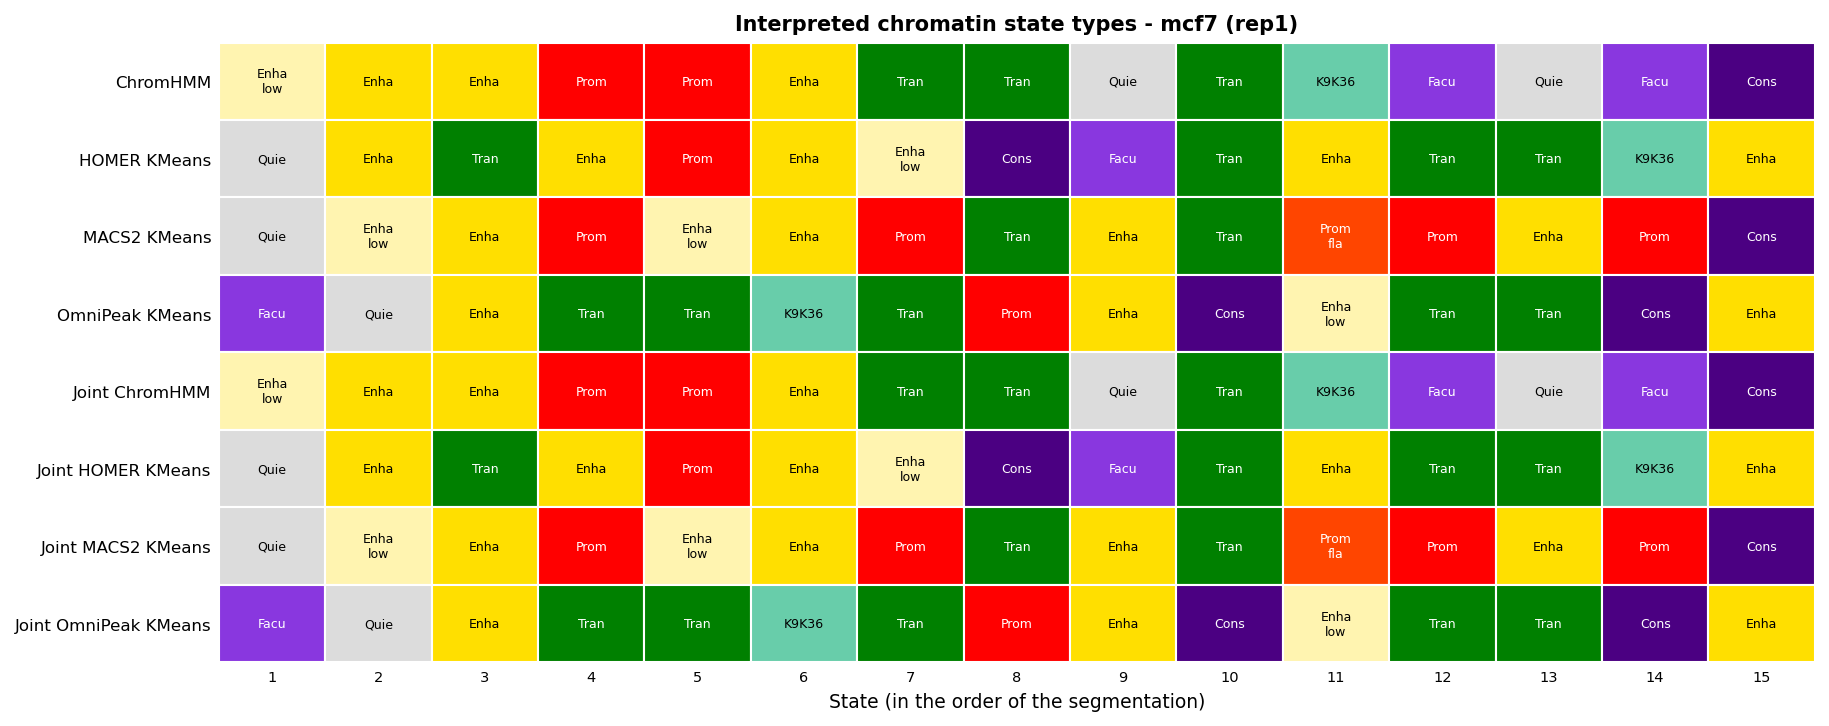

### interpretation_gm12878.png


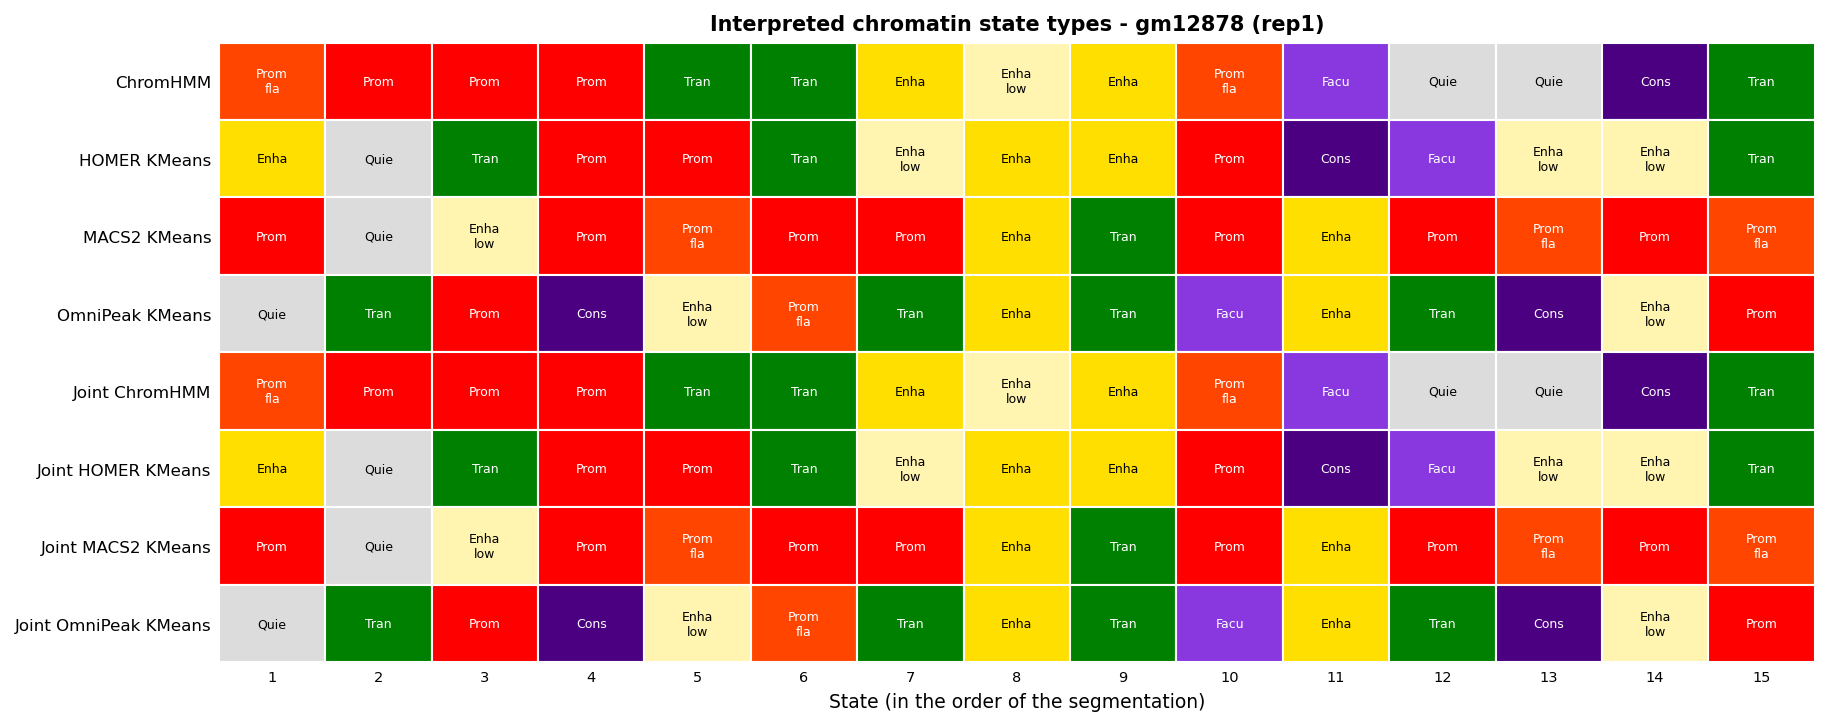

### interpretation_k562.png


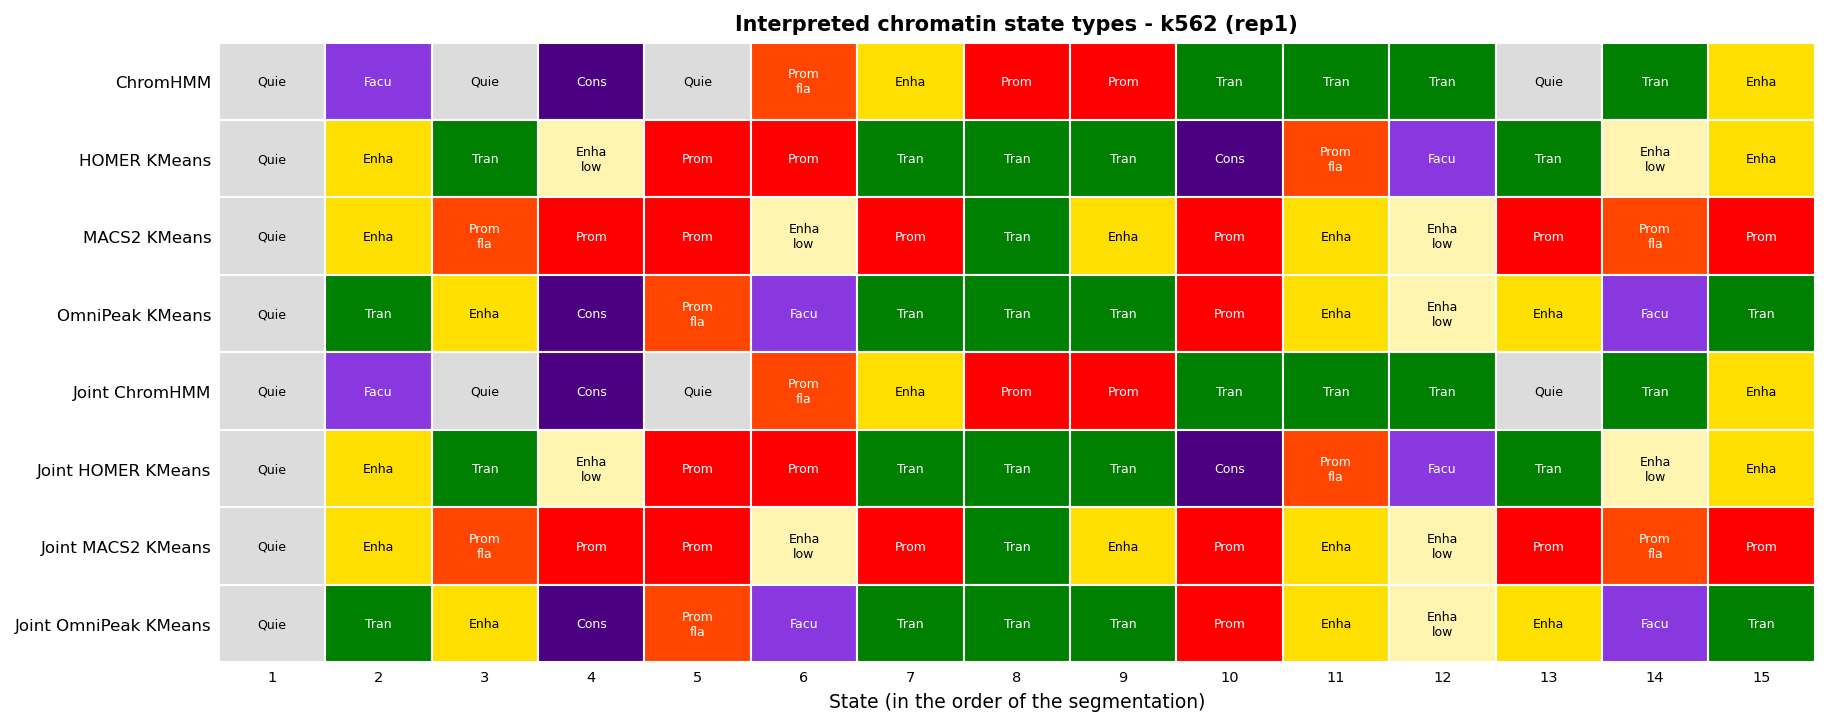

### interpretation_cd14_monocyte.png


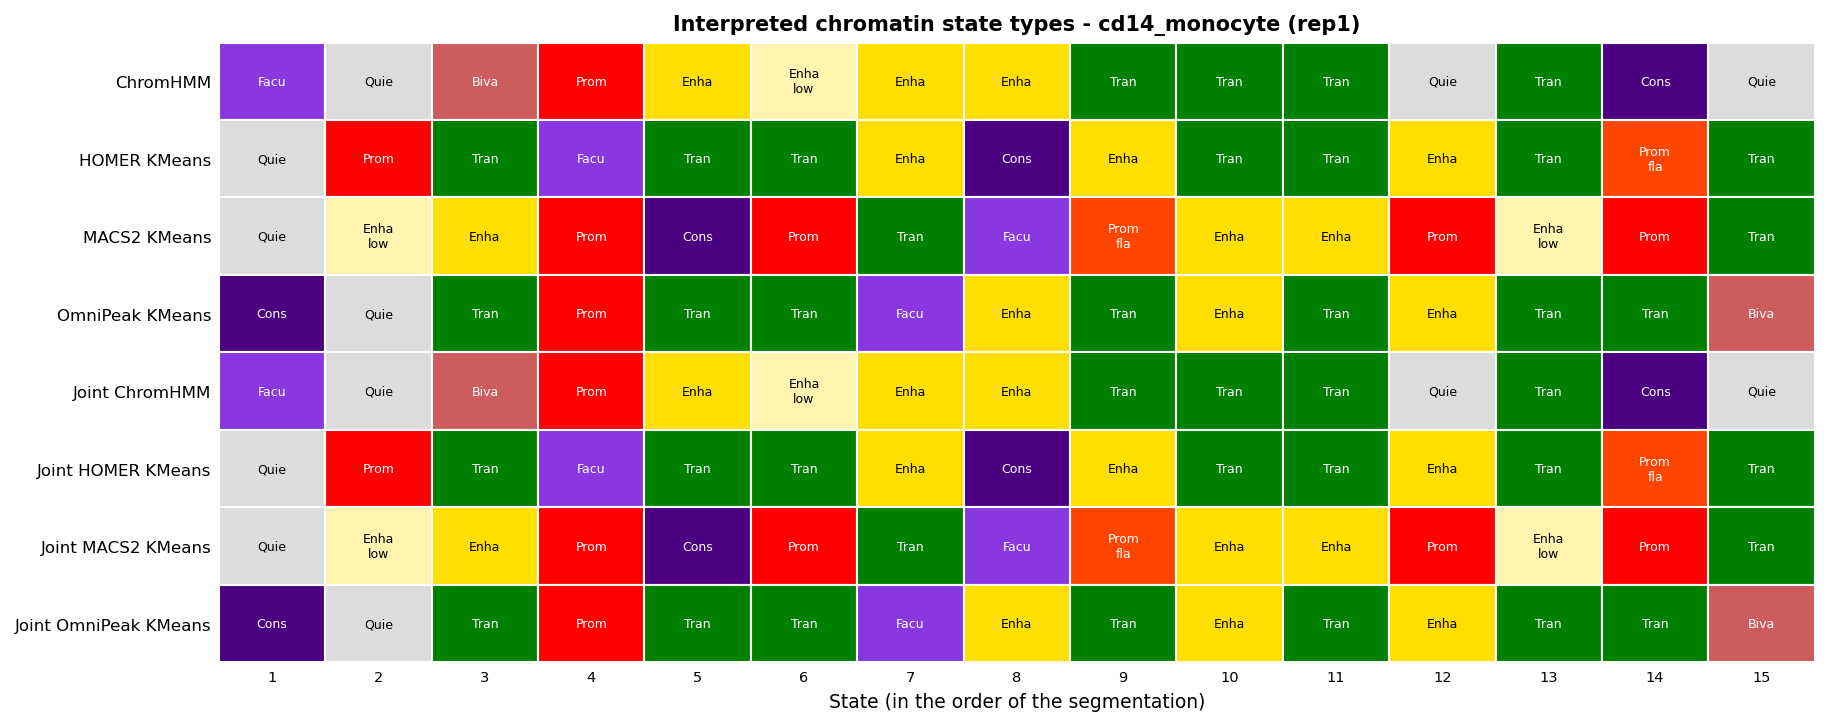

### interpretation_hela_s3.png


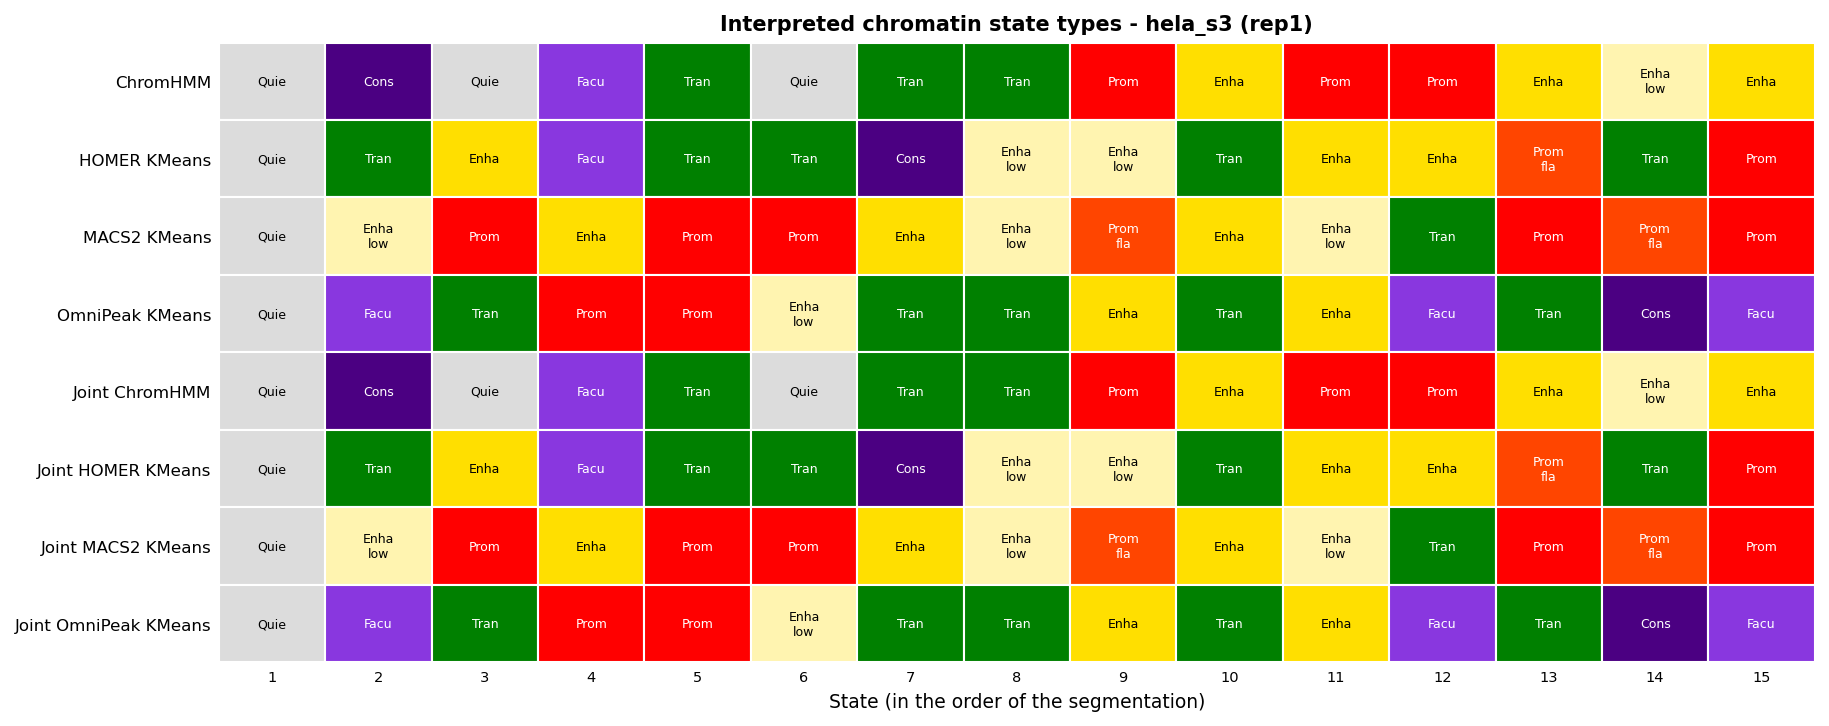

### interpretation_composition.png


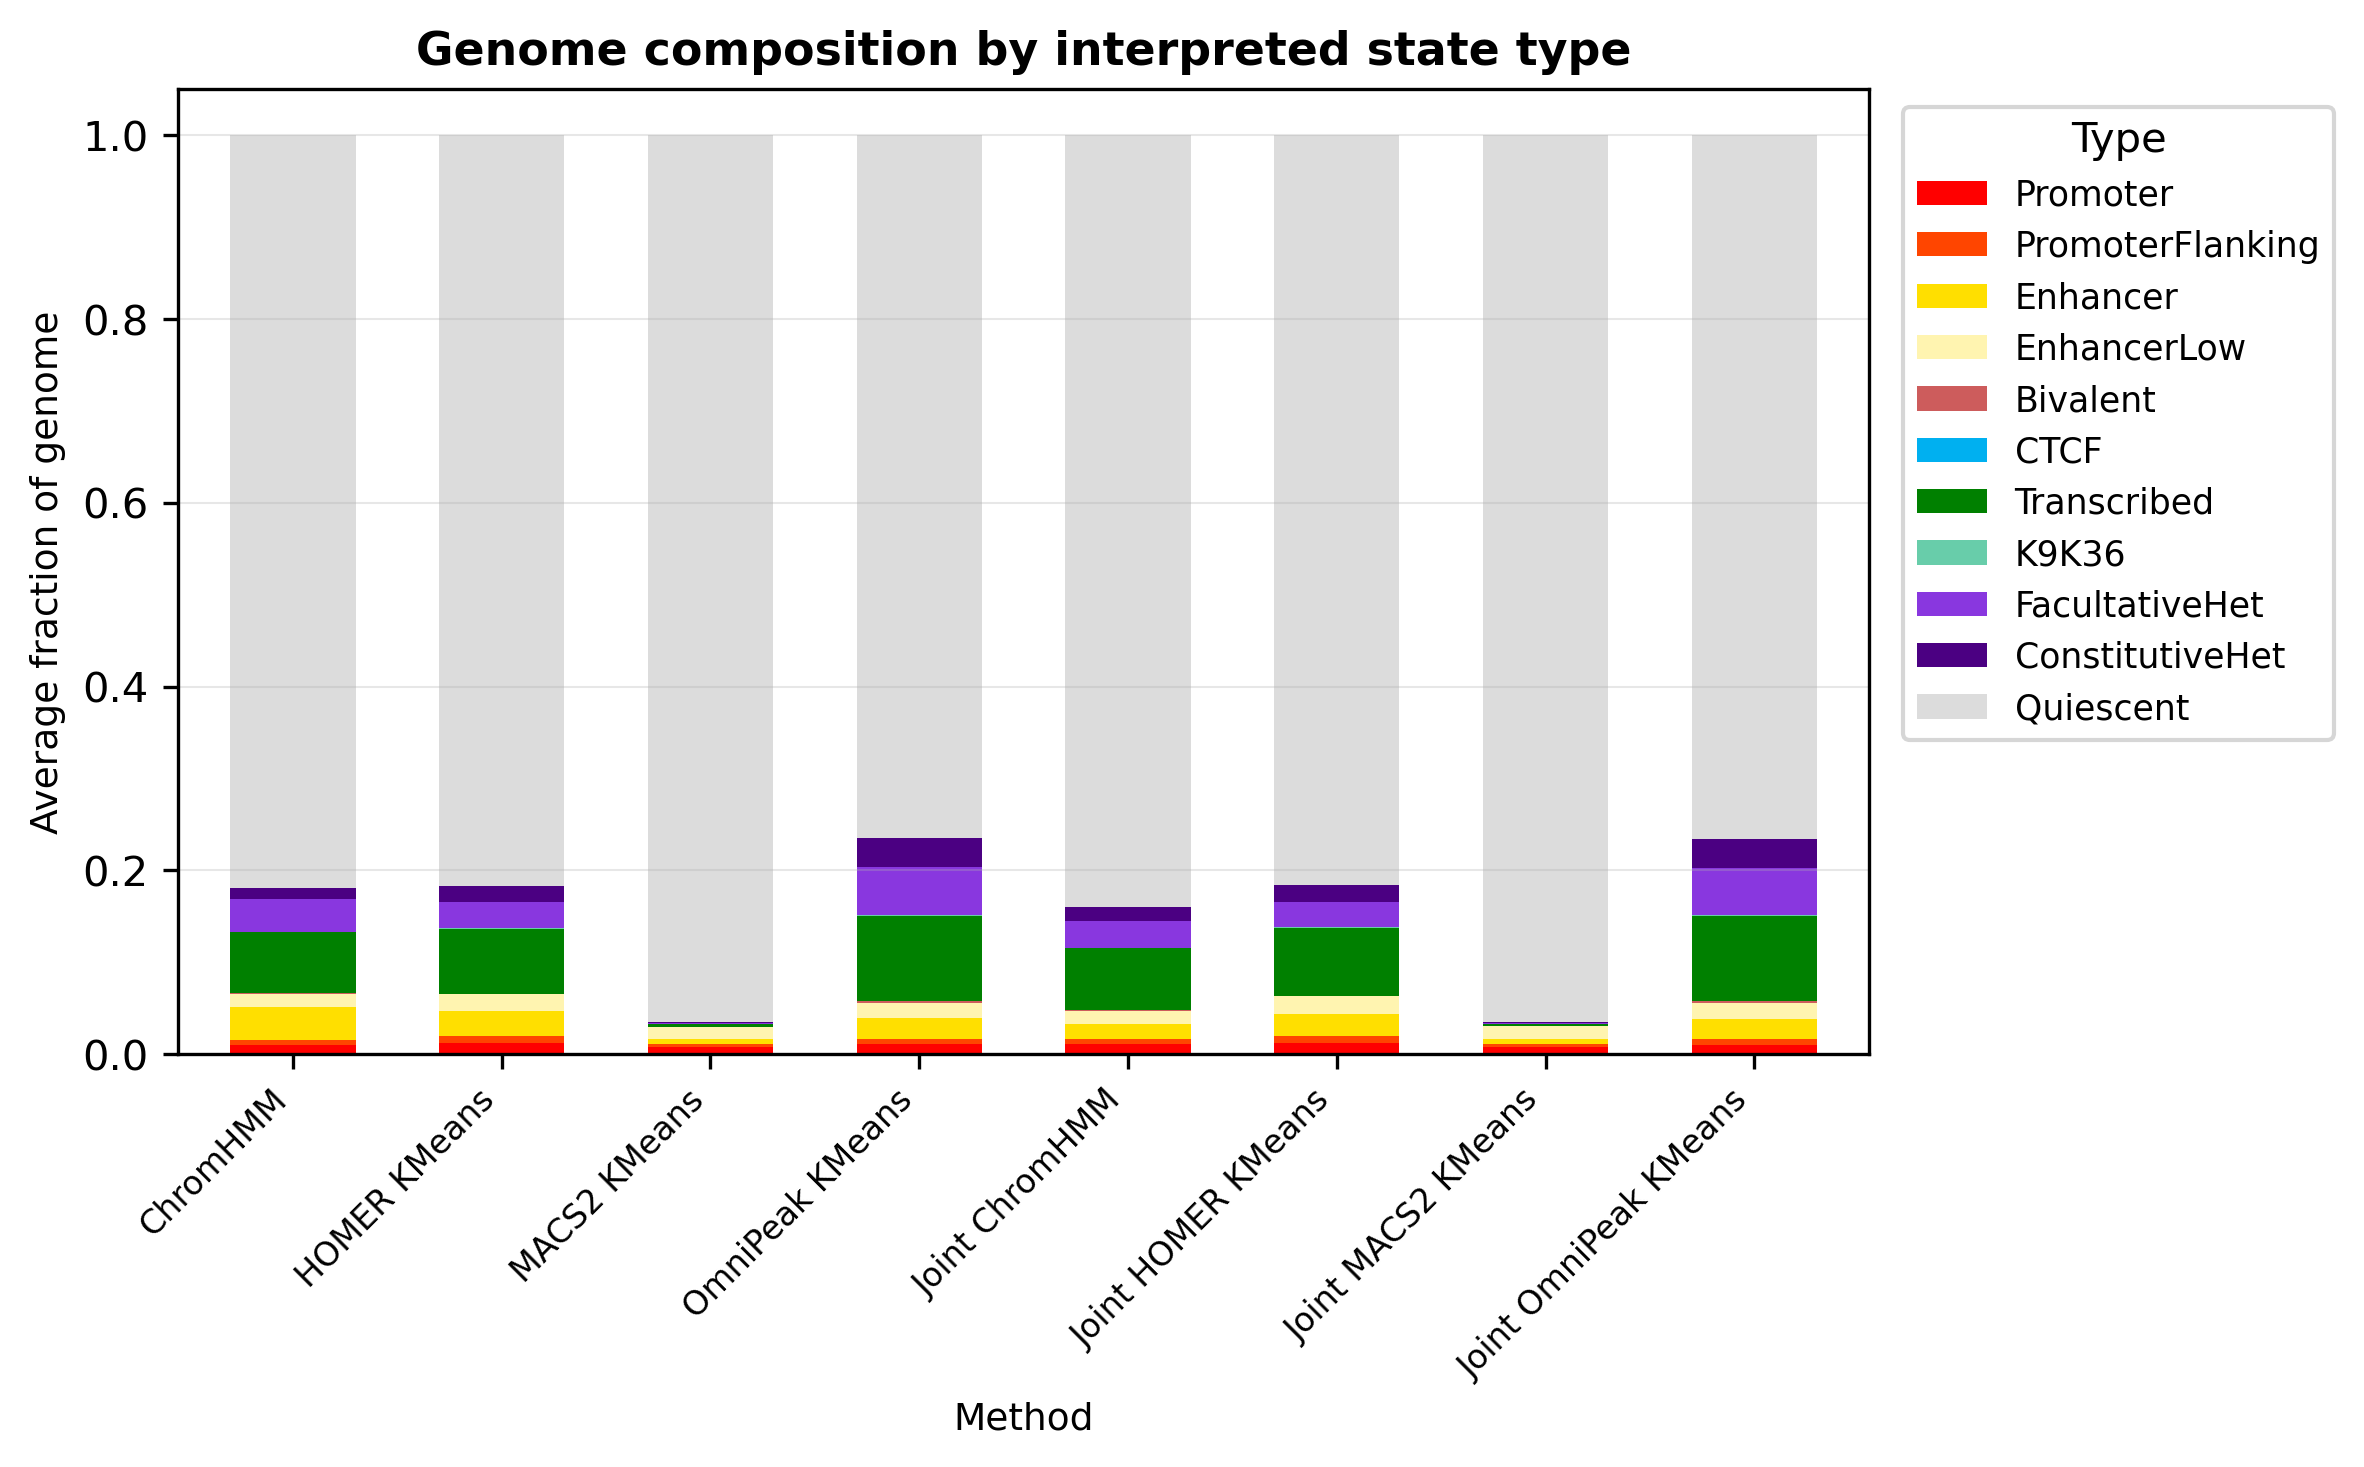

### interpretation_fraction.png


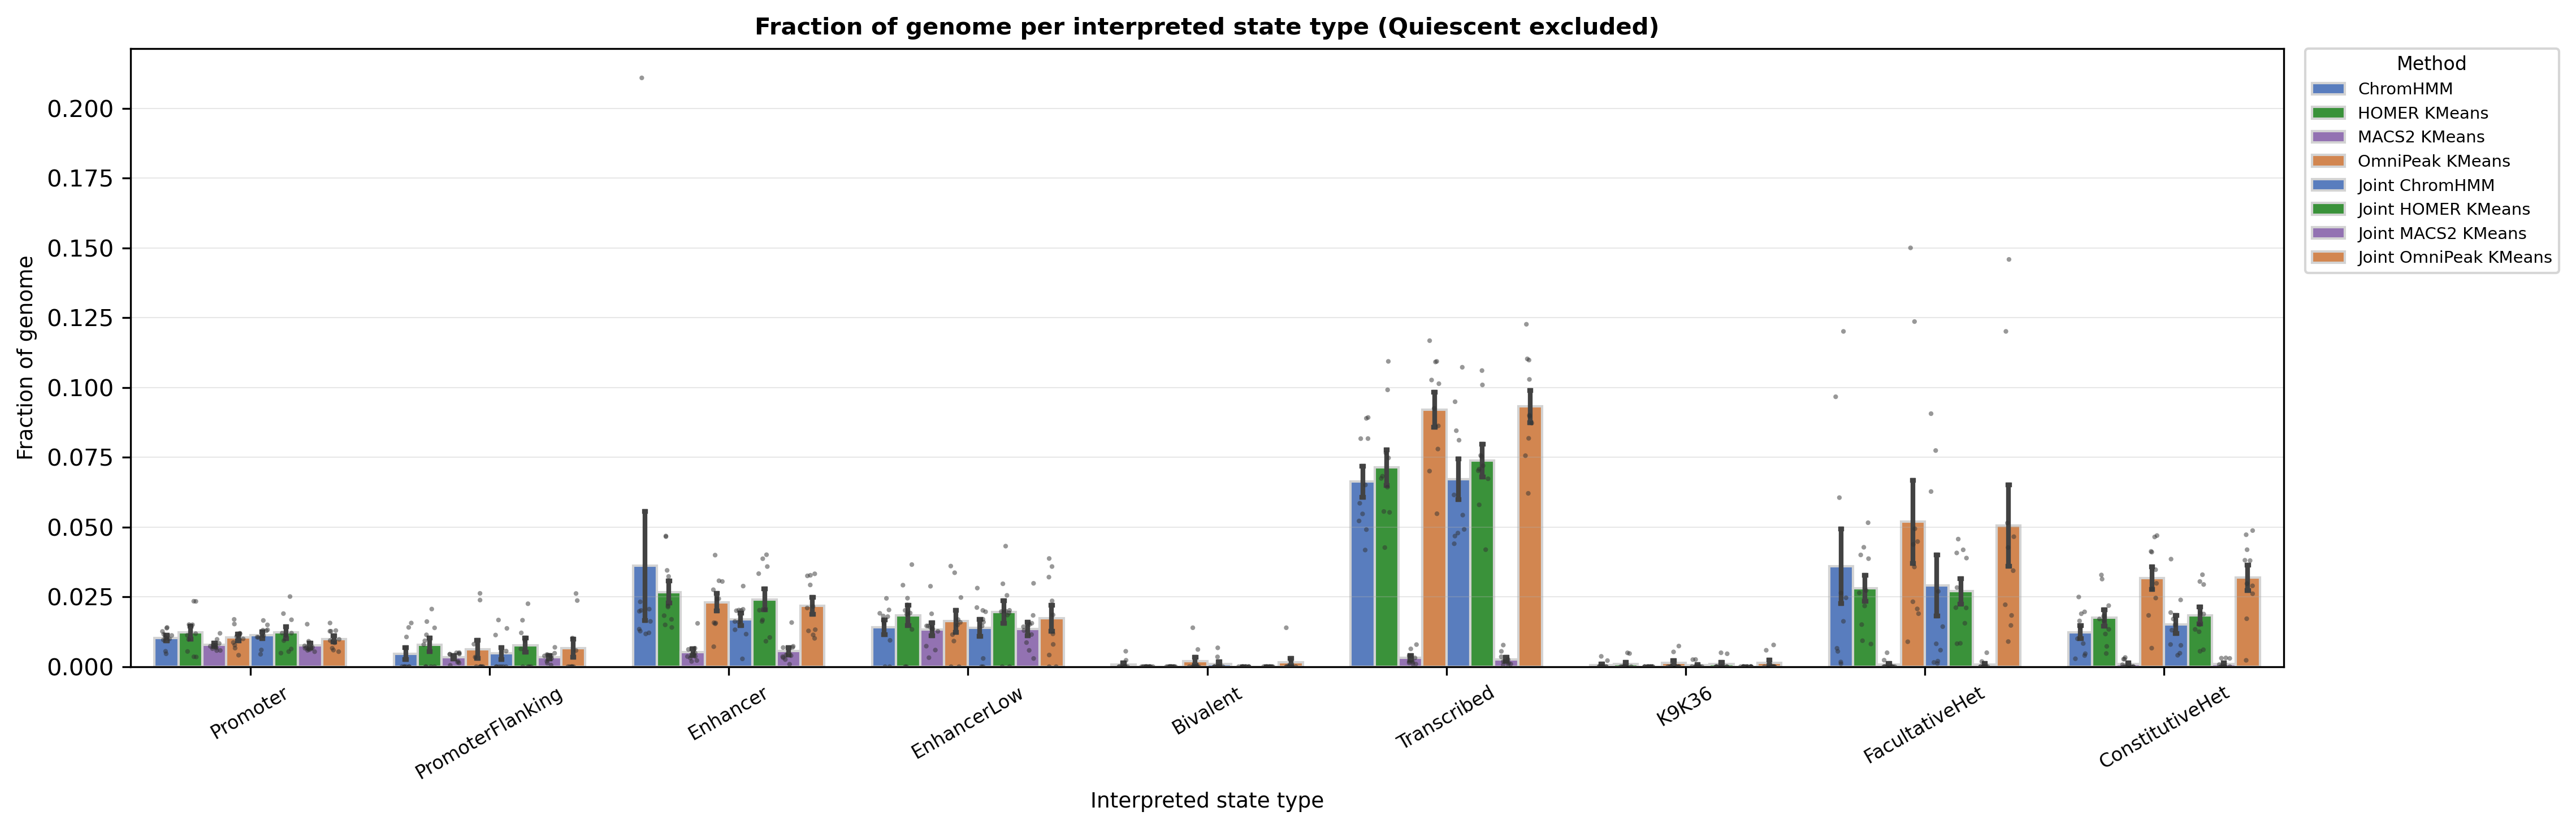

### interpretation_states_per_type.png


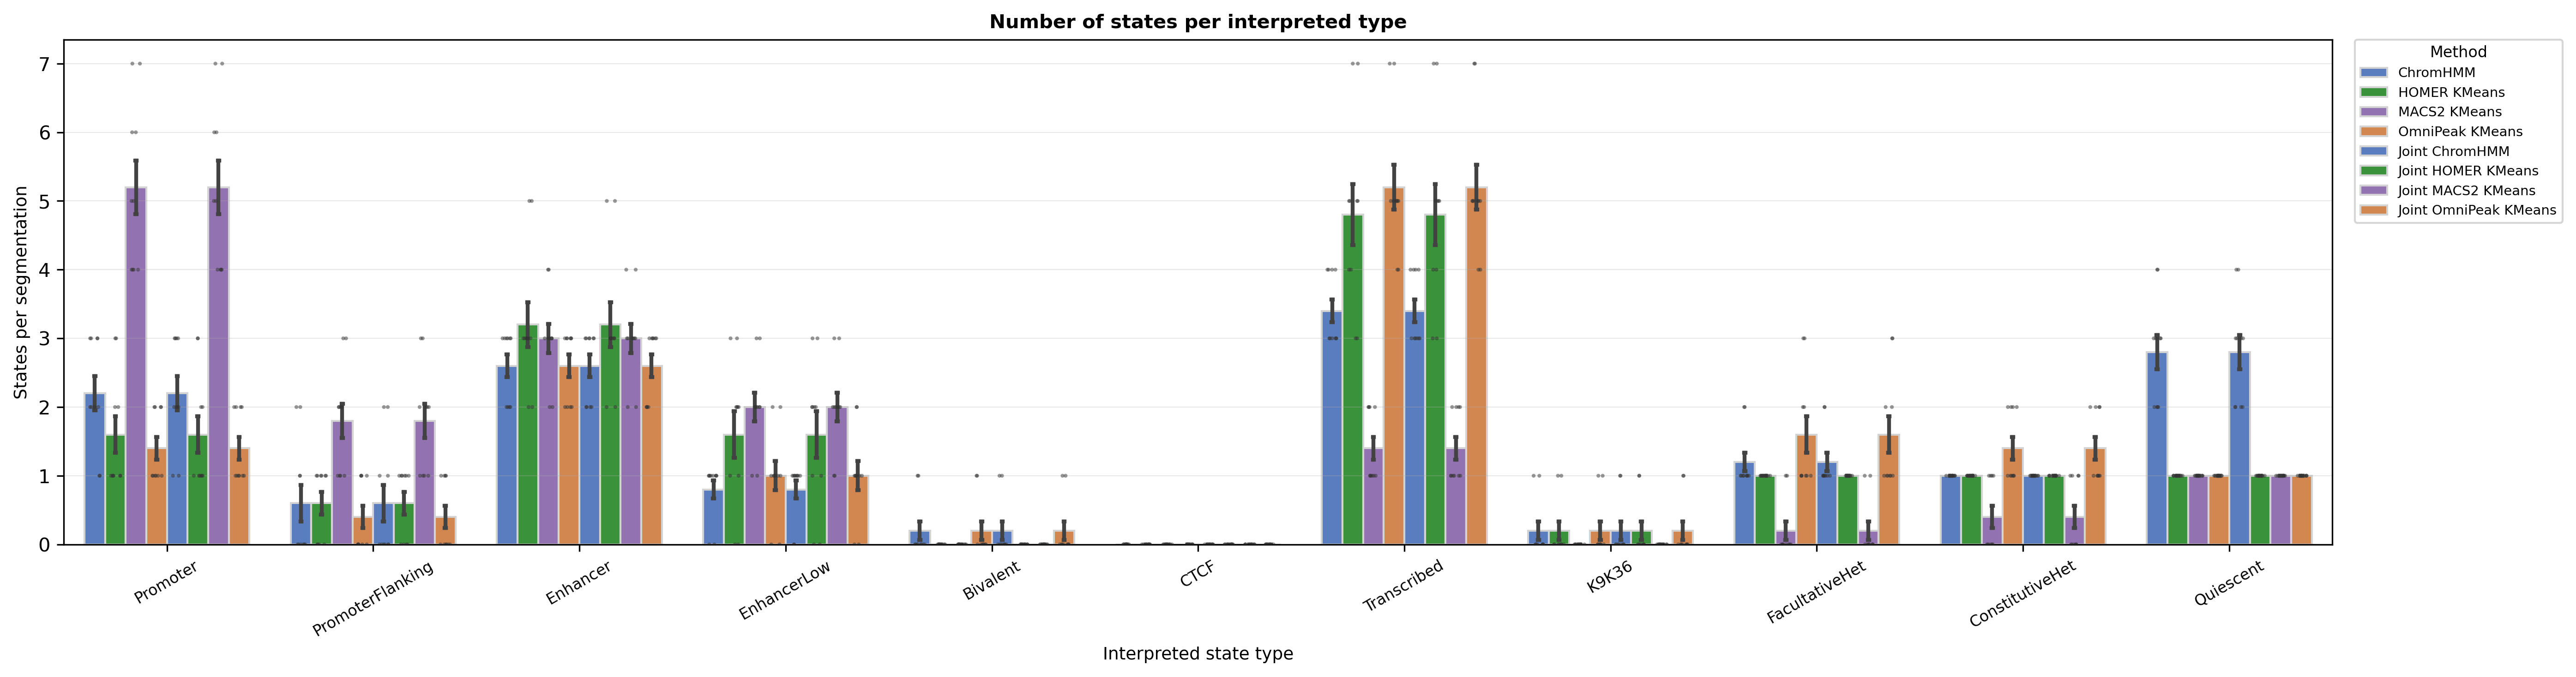

### interpretation_summary.png


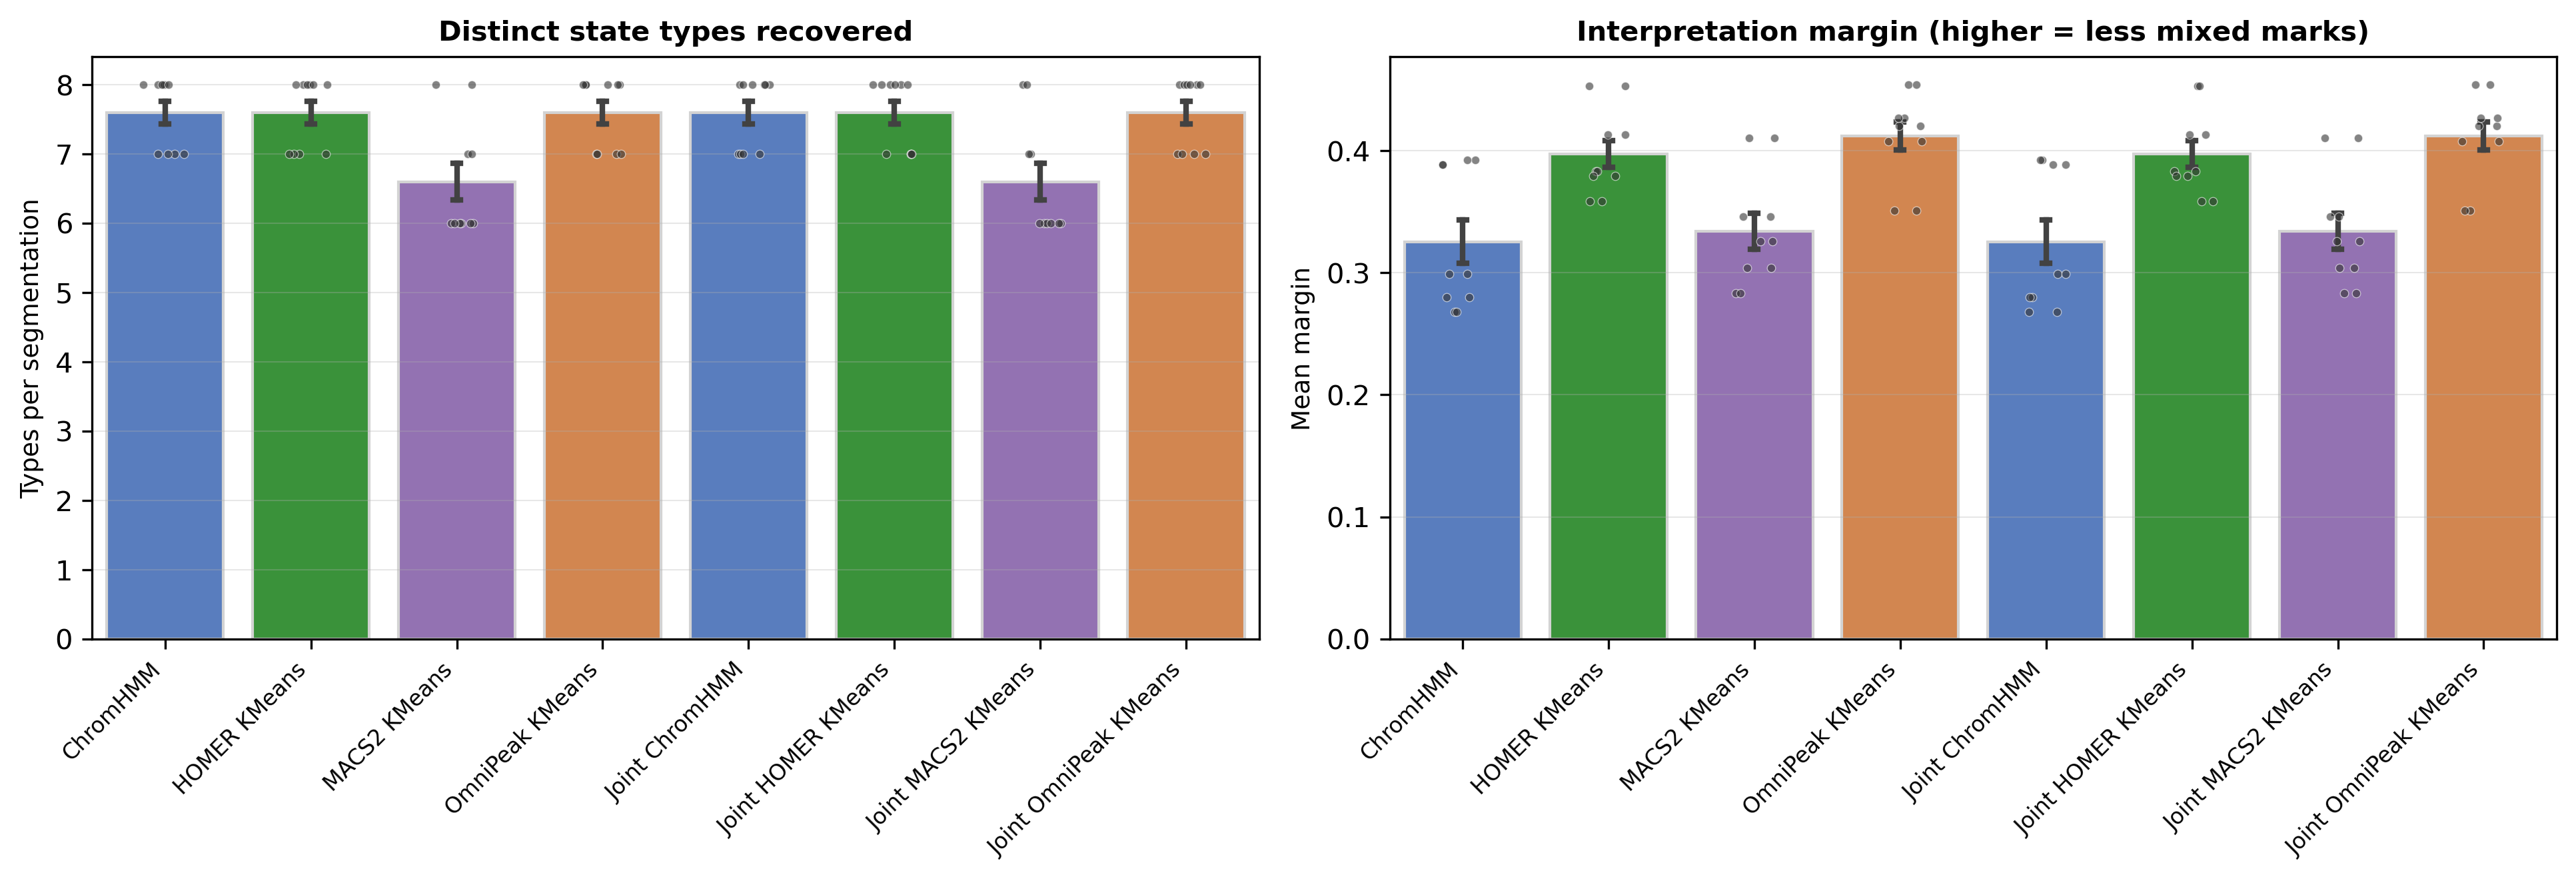

In [11]:
if not df_interp.empty:
    seg_keys = ["Dataset", "Rep", "Method"]

    # Plot 6a. Interpreted type of every state, per dataset
    for ds in DATASETS:
        mat = interpretation.type_matrix(df_interp, ds, "rep1", column="Type",
                                         methods=METHOD_ORDER)
        if mat.empty:
            continue
        fig, ax = plt.subplots(figsize=(0.62 * mat.shape[1] + 3, 0.42 * len(mat) + 1.6))
        for i, method in enumerate(mat.index):
            for j, state in enumerate(mat.columns):
                t = mat.iat[i, j]
                if not isinstance(t, str):
                    continue
                ax.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=TYPE_COLORS[t],
                                           edgecolor="white", linewidth=1))
                ax.text(j + 0.5, i + 0.5, TYPE_SHORT[t].replace(" ", "\n"), ha="center",
                        va="center", fontsize=6, color=interpretation.type_text_color(t))
        ax.set_xlim(0, mat.shape[1])
        ax.set_ylim(len(mat), 0)
        ax.set_xticks(np.arange(mat.shape[1]) + 0.5)
        ax.set_xticklabels(mat.columns, fontsize=7)
        ax.set_yticks(np.arange(len(mat)) + 0.5)
        ax.set_yticklabels(mat.index, fontsize=8)
        ax.set_title(f"Interpreted chromatin state types - {ds} (rep1)", fontsize=10,
                     fontweight="bold")
        ax.set_xlabel("State (in the order of the segmentation)", fontsize=9)
        ax.tick_params(length=0)
        for spine in ax.spines.values():
            spine.set_visible(False)
        plt.tight_layout()
        plt.savefig(f"out/summary_plots/interpretation_{ds}.png", bbox_inches="tight", dpi=150)
        plt.close(fig)

    # Genome fraction per interpreted type: types absent from a segmentation
    # contribute 0, so the bars compare methods on the same footing.
    frac = (df_interp.groupby(seg_keys + ["Type"])["Fraction"].sum()
            .unstack("Type").reindex(columns=TYPE_ORDER).fillna(0.0))
    frac_long = frac.stack().reset_index().rename(columns={0: "Fraction", "level_3": "Type"})

    # Plot 6b. Genome composition by interpreted type (stacked)
    pivot_types = frac.groupby("Method").mean().reindex(METHOD_ORDER).dropna(how="all")
    fig, ax = plt.subplots(figsize=(8, 5))
    pivot_types.plot(kind="bar", stacked=True, ax=ax, width=0.6, linewidth=0,
                     color=[TYPE_COLORS[t] for t in pivot_types.columns])
    ax.set_title("Genome composition by interpreted state type", fontsize=11, fontweight="bold")
    ax.set_ylabel("Average fraction of genome", fontsize=9)
    ax.set_xlabel("Method", fontsize=9)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize="small", title="Type")
    ax.set_xticks(np.arange(len(pivot_types)))
    ax.set_xticklabels(pivot_types.index, rotation=45, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    plt.tight_layout()
    plt.savefig("out/summary_plots/interpretation_composition.png", bbox_inches="tight")
    plt.close(fig)

    # Plot 6c. Genome fraction per interpreted type, without Quiescent
    signal = frac_long[frac_long["Type"] != "Quiescent"]
    types_present = [t for t in TYPE_ORDER
                     if t != "Quiescent" and signal.loc[signal["Type"] == t, "Fraction"].sum() > 0]
    plt.figure(figsize=(max(12, 1.7 * len(types_present)), 5))
    ax = plt.gca()
    sns.barplot(data=signal, x="Type", y="Fraction", hue="Method", order=types_present,
                hue_order=METHOD_ORDER, palette=method_palette, ax=ax, capsize=0.05,
                errorbar="se", err_kws={"linewidth": 2.0}, edgecolor="lightgrey", linewidth=1)
    utils.strip_points(ax, data=signal, x="Type", y="Fraction", hue="Method",
                       order=types_present, hue_order=METHOD_ORDER, size=2, alpha=0.5, jitter=0.2)
    ax.set_title("Fraction of genome per interpreted state type (Quiescent excluded)",
                 fontsize=10, fontweight="bold")
    ax.set_ylabel("Fraction of genome", fontsize=9)
    ax.set_xlabel("Interpreted state type", fontsize=9)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.tick_params(axis="x", labelsize=8, rotation=30)
    ax.legend(title="Method", fontsize=7, title_fontsize=8, bbox_to_anchor=(1.01, 1),
              loc="upper left", borderaxespad=0)
    plt.tight_layout()
    plt.savefig("out/summary_plots/interpretation_fraction.png", bbox_inches="tight")
    plt.close()

    # Plot 6d. How many states each method spends on every type
    counts = (df_interp.groupby(seg_keys + ["Type"]).size().unstack("Type")
              .reindex(columns=TYPE_ORDER).fillna(0).stack().reset_index()
              .rename(columns={0: "States", "level_3": "Type"}))
    plt.figure(figsize=(max(12, 1.7 * len(TYPE_ORDER)), 5))
    ax = plt.gca()
    sns.barplot(data=counts, x="Type", y="States", hue="Method", order=TYPE_ORDER,
                hue_order=METHOD_ORDER, palette=method_palette, ax=ax, capsize=0.05,
                errorbar="se", err_kws={"linewidth": 2.0}, edgecolor="lightgrey", linewidth=1)
    utils.strip_points(ax, data=counts, x="Type", y="States", hue="Method", order=TYPE_ORDER,
                       hue_order=METHOD_ORDER, size=2, alpha=0.5, jitter=0.2)
    ax.set_title("Number of states per interpreted type", fontsize=10, fontweight="bold")
    ax.set_ylabel("States per segmentation", fontsize=9)
    ax.set_xlabel("Interpreted state type", fontsize=9)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.tick_params(axis="x", labelsize=8, rotation=30)
    ax.legend(title="Method", fontsize=7, title_fontsize=8, bbox_to_anchor=(1.01, 1),
              loc="upper left", borderaxespad=0)
    plt.tight_layout()
    plt.savefig("out/summary_plots/interpretation_states_per_type.png", bbox_inches="tight")
    plt.close()

    # Plot 6e. Interpretability per method: types covered, and how clean the calls are
    summary = (df_interp.groupby(seg_keys)
               .agg(Types=("Type", "nunique"), Margin=("Margin", "mean")).reset_index())
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for ax, col, title, ylabel in [
        (axes[0], "Types", "Distinct state types recovered", "Types per segmentation"),
        (axes[1], "Margin", "Interpretation margin (higher = less mixed marks)", "Mean margin"),
    ]:
        sns.barplot(data=summary, x="Method", y=col, order=METHOD_ORDER, hue="Method",
                    hue_order=METHOD_ORDER, palette=method_palette, dodge=False, ax=ax,
                    capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
                    edgecolor="lightgrey", linewidth=1, legend=False)
        utils.strip_points(ax, data=summary, x="Method", y=col, order=METHOD_ORDER,
                           dodge=False, size=3, alpha=0.6)
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_xlabel("")
        ax.set_xticks(np.arange(len(METHOD_ORDER)))
        ax.set_xticklabels(METHOD_ORDER, rotation=45, ha="right", fontsize=8)
        ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    plt.tight_layout()
    plt.savefig("out/summary_plots/interpretation_summary.png", bbox_inches="tight")
    plt.close(fig)

    print("Average fraction of genome per interpreted type:")
    display(pivot_types.round(4))

    for img in [f"interpretation_{ds}.png" for ds in DATASETS] + [
            "interpretation_composition.png", "interpretation_fraction.png",
            "interpretation_states_per_type.png", "interpretation_summary.png"]:
        path = f"out/summary_plots/{img}"
        if os.path.exists(path):
            print(f"### {img}")
            display(Image(filename=path))


In [12]:
# 6f. Replicate consistency on interpreted NOQH states only
def compute_replicate_agreement_noqh():
    """rep1 vs rep2 of the same method, restricted to NOQH states (interpreted)."""
    if df_interp.empty:
        return pd.DataFrame()

    # Mapping: (Dataset, Method, Rep, State) -> Type
    interp_map = df_interp.set_index(["Dataset", "Method", "Rep", "State"])["Type"].to_dict()

    # Background types to exclude: Quiescent and Heterochromatin
    exclude_types = ["Quiescent", "FacultativeHet", "ConstitutiveHet"]

    rows = []
    datasets_with_reps = [ds for ds in DATASETS if os.path.isdir(f"{ds}/rep1") and os.path.isdir(f"{ds}/rep2")]

    for ds in tqdm(datasets_with_reps, desc="Replicates NOQH"):
        for method_key, method_name in METHOD_LABELS:
            p1 = get_method_path(ds, method_key, "rep1")
            p2 = get_method_path(ds, method_key, "rep2")
            if not p1 or not p2 or not os.path.exists(p1) or not os.path.exists(p2):
                continue

            # Load segmentations
            s1, s2 = match.load_bed(p1), match.load_bed(p2)
            l1, l2 = match.state_lengths(s1), match.state_lengths(s2)
            overlap = match.pair_overlap(s1, s2)

            # Map states to types
            m1 = {s: interp_map.get((ds, method_name, "rep1", str(s)), "Quiescent") for s in l1}
            m2 = {s: interp_map.get((ds, method_name, "rep2", str(s)), "Quiescent") for s in l2}

            # Aggregate overlap to types
            type_overlap = defaultdict(float)
            for (st1, st2), val in overlap.items():
                type_overlap[(m1[st1], m2[st2])] += val

            # Aggregate lengths to types
            type_l1 = defaultdict(float)
            for st1, val in l1.items():
                type_l1[m1[st1]] += val

            type_l2 = defaultdict(float)
            for st2, val in l2.items():
                type_l2[m2[st2]] += val

            # Compute agreement metrics
            metrics = match.agreement_metrics(type_overlap, type_l1, type_l2, exclude=exclude_types)
            if metrics:
                rows.append({"Method": method_name, "Dataset": ds, **metrics})

    return pd.DataFrame(rows)

def compute_replicate_agreement_per_type():
    """rep1 vs rep2 agreement for each interpreted state type."""
    if df_interp.empty:
        return pd.DataFrame()

    interp_map = df_interp.set_index(["Dataset", "Method", "Rep", "State"])["Type"].to_dict()
    exclude_types = []

    rows = []
    datasets_with_reps = [ds for ds in DATASETS if os.path.isdir(f"{ds}/rep1") and os.path.isdir(f"{ds}/rep2")]

    for ds in tqdm(datasets_with_reps, desc="Replicates per type"):
        for method_key, method_name in METHOD_LABELS:
            p1 = get_method_path(ds, method_key, "rep1")
            p2 = get_method_path(ds, method_key, "rep2")
            if not p1 or not p2 or not os.path.exists(p1) or not os.path.exists(p2):
                continue

            s1, s2 = match.load_bed(p1), match.load_bed(p2)
            l1, l2 = match.state_lengths(s1), match.state_lengths(s2)
            overlap = match.pair_overlap(s1, s2)

            m1 = {s: interp_map.get((ds, method_name, "rep1", str(s)), "Quiescent") for s in l1}
            m2 = {s: interp_map.get((ds, method_name, "rep2", str(s)), "Quiescent") for s in l2}

            type_overlap = defaultdict(float)
            for (st1, st2), val in overlap.items():
                type_overlap[(m1[st1], m2[st2])] += val
            
            type_l1 = defaultdict(float)
            for st1, val in l1.items():
                type_l1[m1[st1]] += val
            
            type_l2 = defaultdict(float)
            for st2, val in l2.items():
                type_l2[m2[st2]] += val

            all_types = sorted((set(type_l1.keys()) | set(type_l2.keys()) | 
                                {"FacultativeHet", "ConstitutiveHet", "Quiescent"}) - set(exclude_types))
            total = sum(type_overlap.values())
            if total == 0: continue

            for t in all_types:
                # Jaccard
                inter = type_overlap.get((t, t), 0)
                union = type_l1[t] + type_l2[t] - inter
                jaccard = inter / union if union > 0 else 1.0
                
                # Kappa (one-vs-rest)
                p1 = type_l1[t] / total
                p2 = type_l2[t] / total
                po = (inter + (total - type_l1[t] - type_l2[t] + inter)) / total
                pe = p1 * p2 + (1 - p1) * (1 - p2)
                kappa = (po - pe) / (1 - pe) if pe < 1 else 1.0
                
                rows.append({"Method": method_name, "Dataset": ds, "Type": t, "Jaccard": jaccard, "Kappa": kappa})

    return pd.DataFrame(rows)

df_rep_noqh = utils.cached_pickle("out/df_rep_noqh.pkl", compute_replicate_agreement_noqh,
                                  label="replicate consistency (NOQH)", valid=nonempty)
df_rep_per_type = utils.cached_pickle("out/df_rep_per_type.pkl", compute_replicate_agreement_per_type,
                                       label="replicate consistency per type", valid=nonempty)

if not df_rep_per_type.empty:
    types_order = [t for t in TYPE_ORDER if t in df_rep_per_type["Type"].unique() or t in ["FacultativeHet", "ConstitutiveHet", "Quiescent"]]
    for metric in ["Jaccard", "Kappa"]:
        plt.figure(figsize=(max(12, len(types_order) * 2), 6))
        ax = sns.barplot(data=df_rep_per_type, x="Type", y=metric, hue="Method",
                         order=types_order, hue_order=METHOD_ORDER, palette=method_palette,
                         capsize=0.1, errorbar="se", edgecolor="lightgrey", linewidth=1)
        utils.strip_points(ax, data=df_rep_per_type, x="Type", y=metric, hue="Method",
                           order=types_order, hue_order=METHOD_ORDER, size=2.5, alpha=0.6, jitter=0.2)
        
        ax.set_title(f"Replicate {metric} per interpreted state type", fontsize=11, fontweight="bold")
        ax.set_ylabel(metric, fontsize=9)
        ax.set_xlabel("Interpreted Type", fontsize=9)
        ax.set_ylim(0 if metric == "Jaccard" else None, 1.05)
        ax.grid(axis='y', alpha=0.3)
        plt.xticks(rotation=45, ha="right")
        ax.legend(title="Method", fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
        
        plt.savefig(f"out/summary_plots/interpretation_replicate_{metric.lower()}_per_type.png", bbox_inches='tight')
        plt.close()

        # Combined across methods
        plt.figure(figsize=(max(12, len(types_order) * 2), 6))
        ax = sns.barplot(data=df_rep_per_type, x="Type", y=metric,
                         order=types_order, color="#4878CF",
                         capsize=0.1, errorbar="se", edgecolor="lightgrey", linewidth=1)
        utils.strip_points(ax, data=df_rep_per_type, x="Type", y=metric,
                           order=types_order, size=2.5, alpha=0.6, jitter=0.2)
        ax.set_title(f"Average Replicate {metric} per interpreted type (combined across methods)", 
                     fontsize=11, fontweight="bold")
        ax.set_ylabel(metric, fontsize=9)
        ax.set_xlabel("Interpreted Type", fontsize=9)
        ax.set_ylim(0 if metric == "Jaccard" else None, 1.05)
        ax.grid(axis='y', alpha=0.3)
        plt.xticks(rotation=45, ha="right")
        plt.savefig(f"out/summary_plots/interpretation_replicate_{metric.lower()}_per_type_combined.png", 
                    bbox_inches='tight')
        plt.close()

if not df_rep_noqh.empty:
    for metric in ["Jaccard", "Kappa"]:
        plt.figure(figsize=(8, 6))
        sns.barplot(data=df_rep_noqh, x='Method', y=metric, order=METHOD_ORDER,
                    palette=method_palette, hue='Method', dodge=False,
                    capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
                    edgecolor="lightgrey", linewidth=1)
        utils.strip_points(plt.gca(), data=df_rep_noqh, x='Method', y=metric, order=METHOD_ORDER, size=2)
        plt.title(f"Replicate {metric} (Interpreted NOQH states)", fontsize=11, fontweight="bold")
        plt.ylabel(metric, fontsize=9)
        plt.xticks(rotation=45, ha="right")
        plt.grid(axis='y', alpha=0.3)

        # Add labels over error bars
        yrange = plt.gca().get_ylim()[1] - plt.gca().get_ylim()[0]
        for i, method in enumerate(METHOD_ORDER):
            vals = df_rep_noqh[df_rep_noqh["Method"] == method][metric]
            if vals.empty: continue
            m, s = vals.mean(), vals.sem()
            if pd.isna(m): continue
            top = max(m + (s if not pd.isna(s) else 0), vals.max())
            plt.text(i, top + yrange * 0.01, f"{m:.2f}", ha="center", va="bottom", fontsize=6)

        plt.savefig(f"out/summary_plots/interpretation_replicate_{metric.lower()}_noqh.png", bbox_inches='tight')
        plt.close()


Computing replicate consistency (NOQH)...


Replicates NOQH:   0%|          | 0/5 [00:00<?, ?it/s]

Saved replicate consistency (NOQH) to out/df_rep_noqh.pkl
Computing replicate consistency per type...


Replicates per type:   0%|          | 0/5 [00:00<?, ?it/s]

Saved replicate consistency per type to out/df_rep_per_type.pkl


## Show

### n_peaks.png


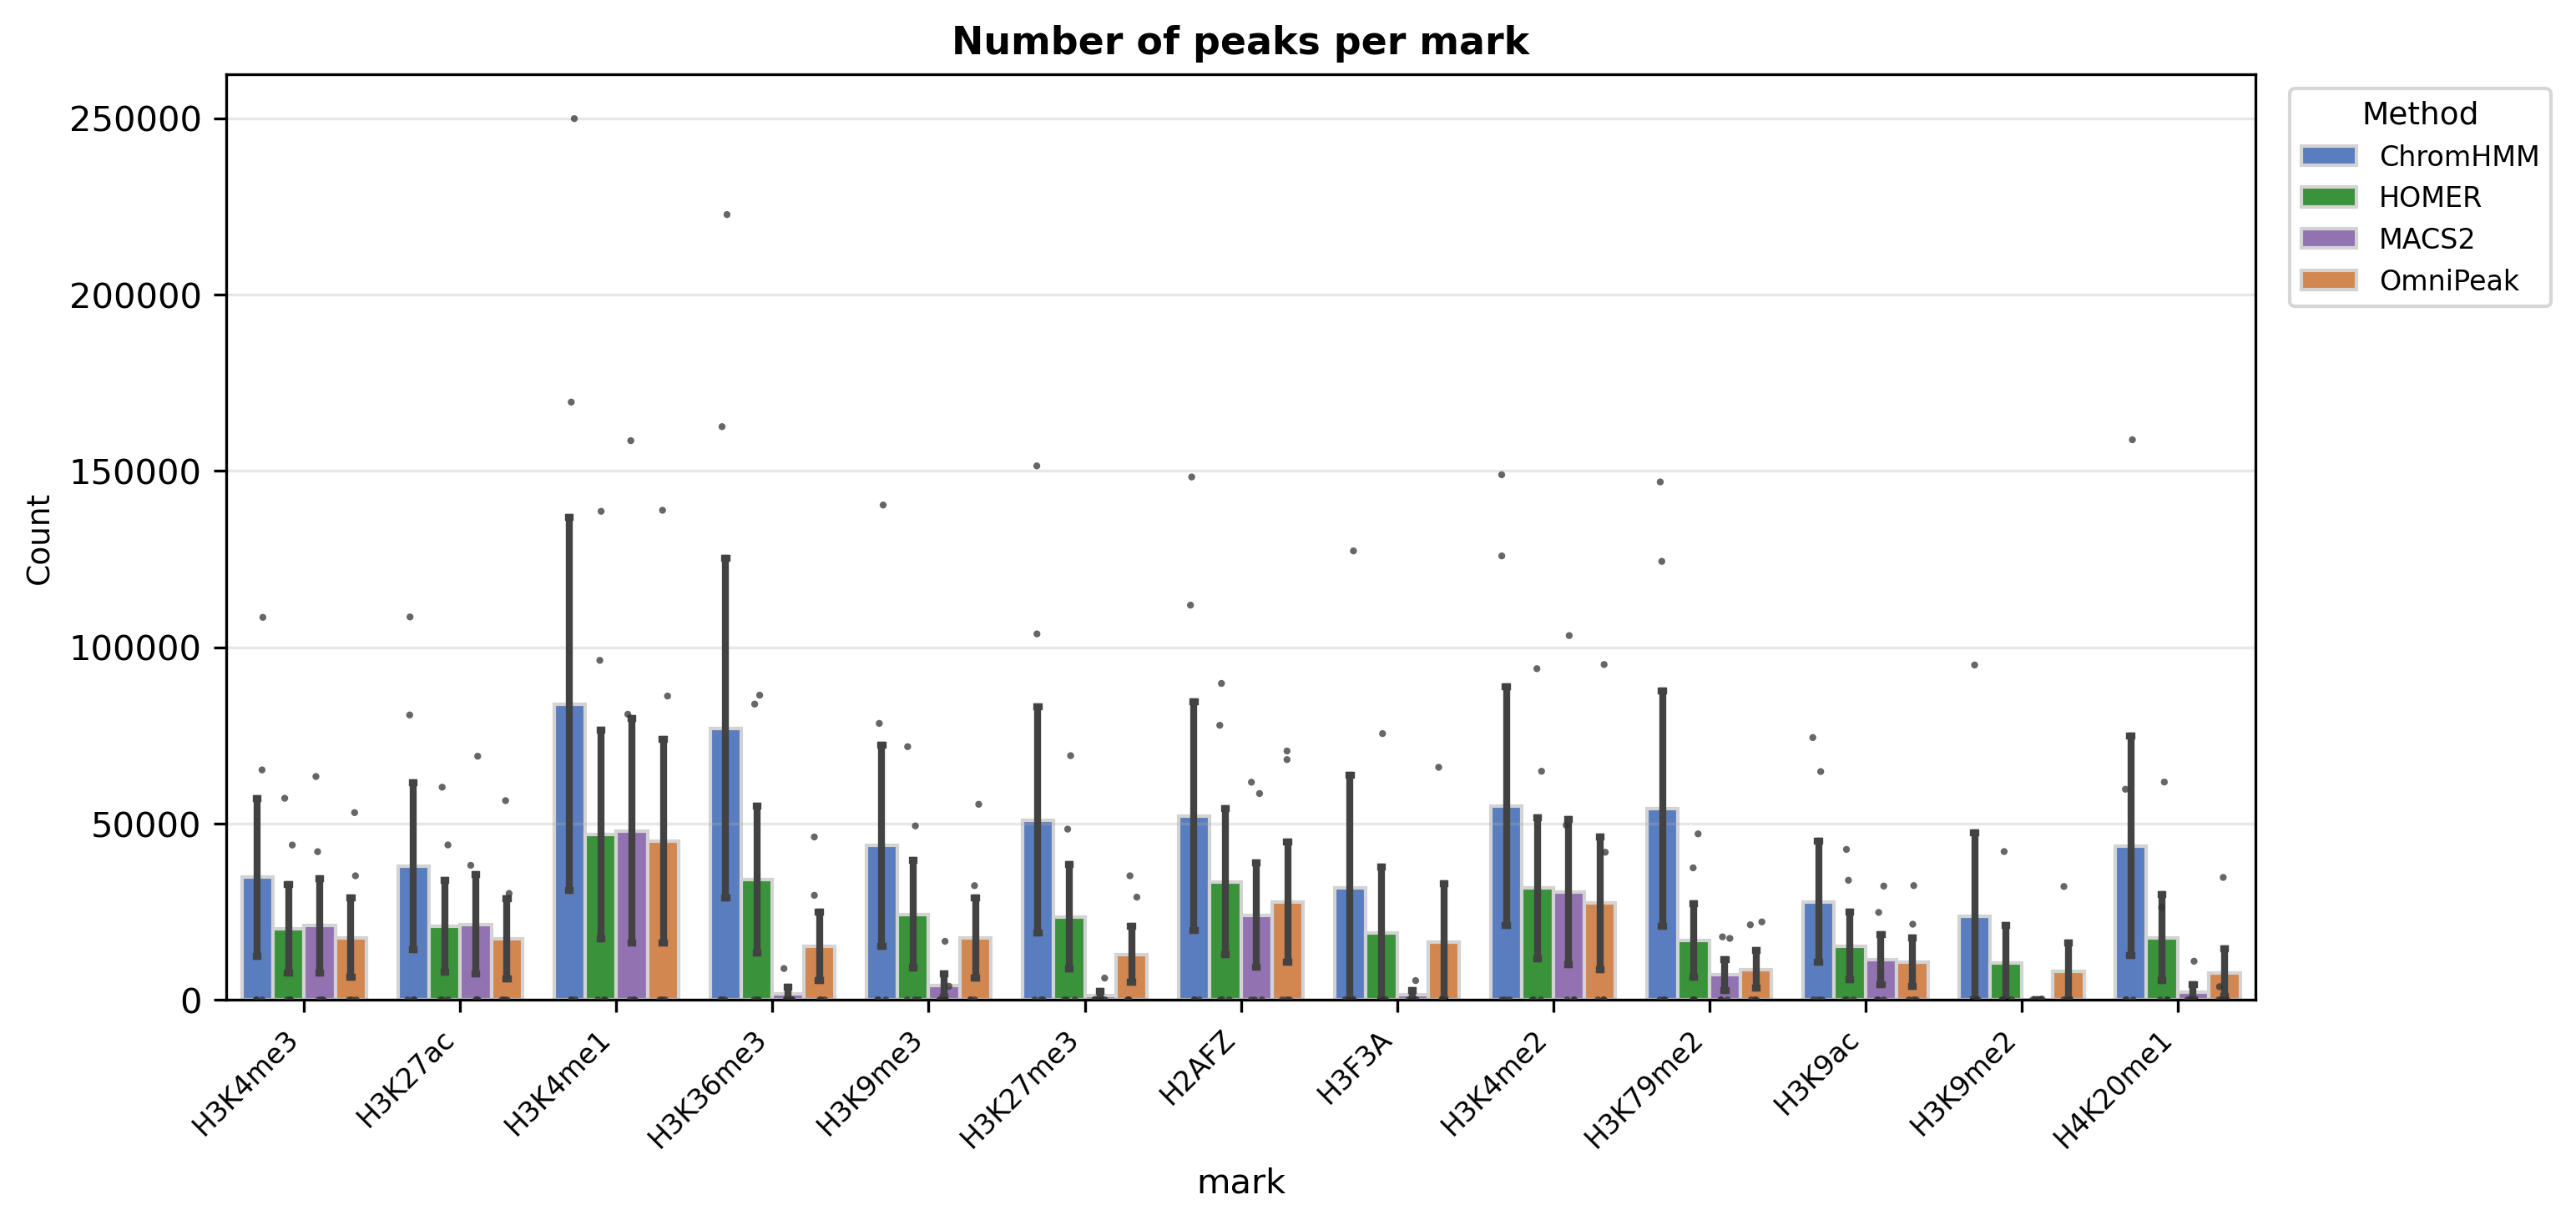

### peak_length.png


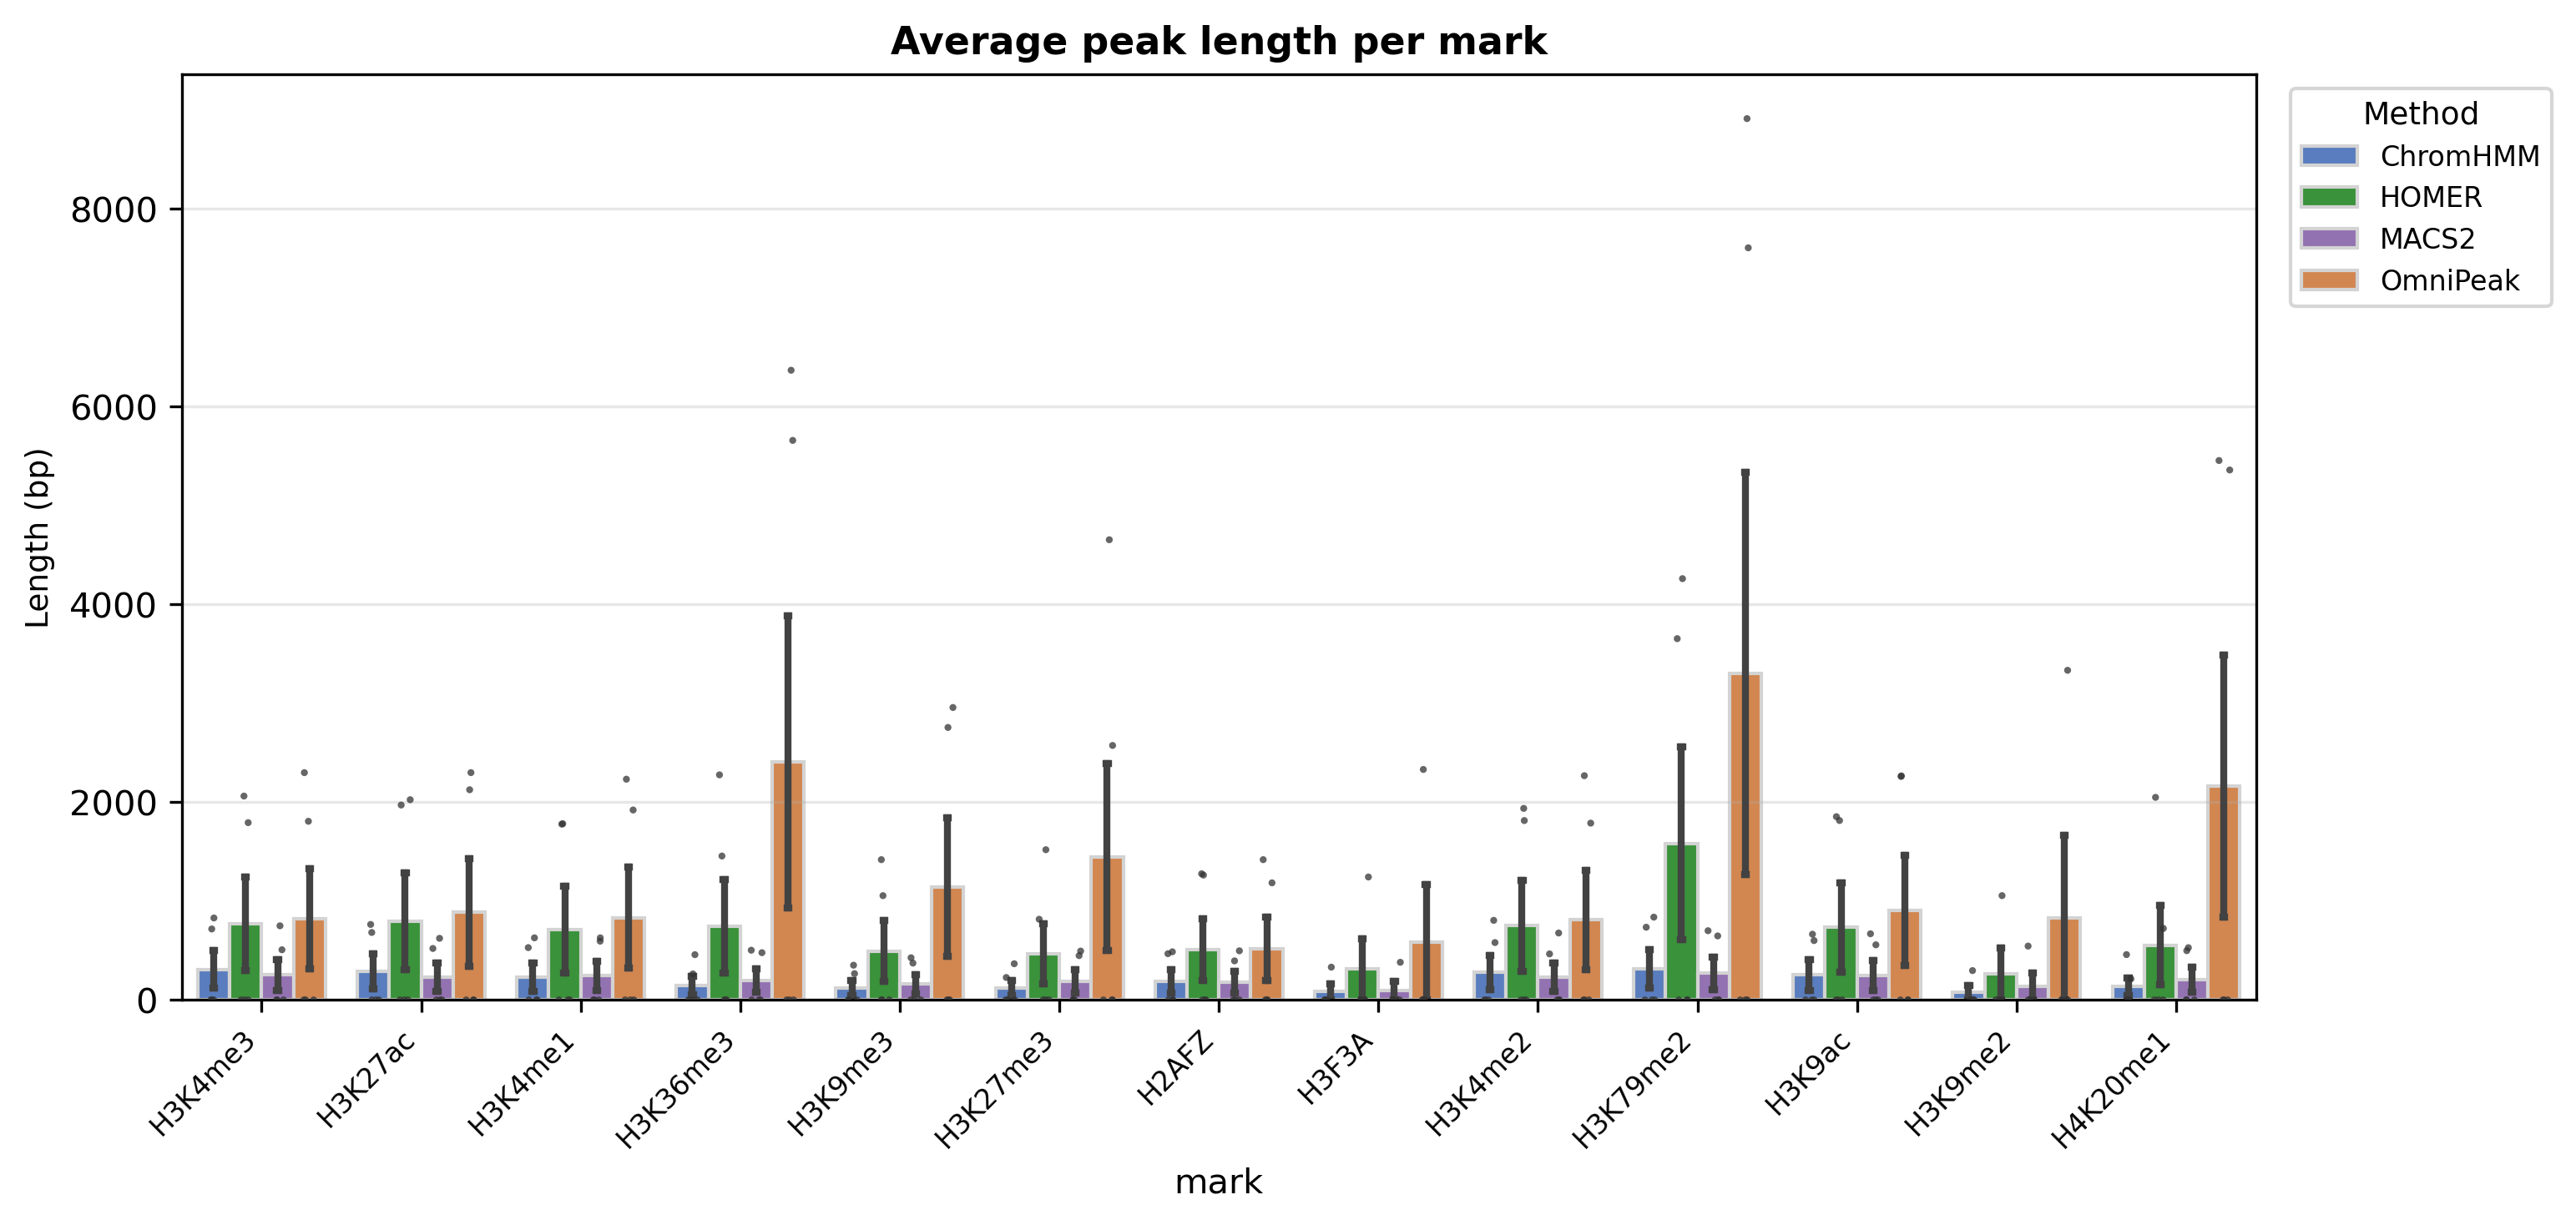

### n_segments.png


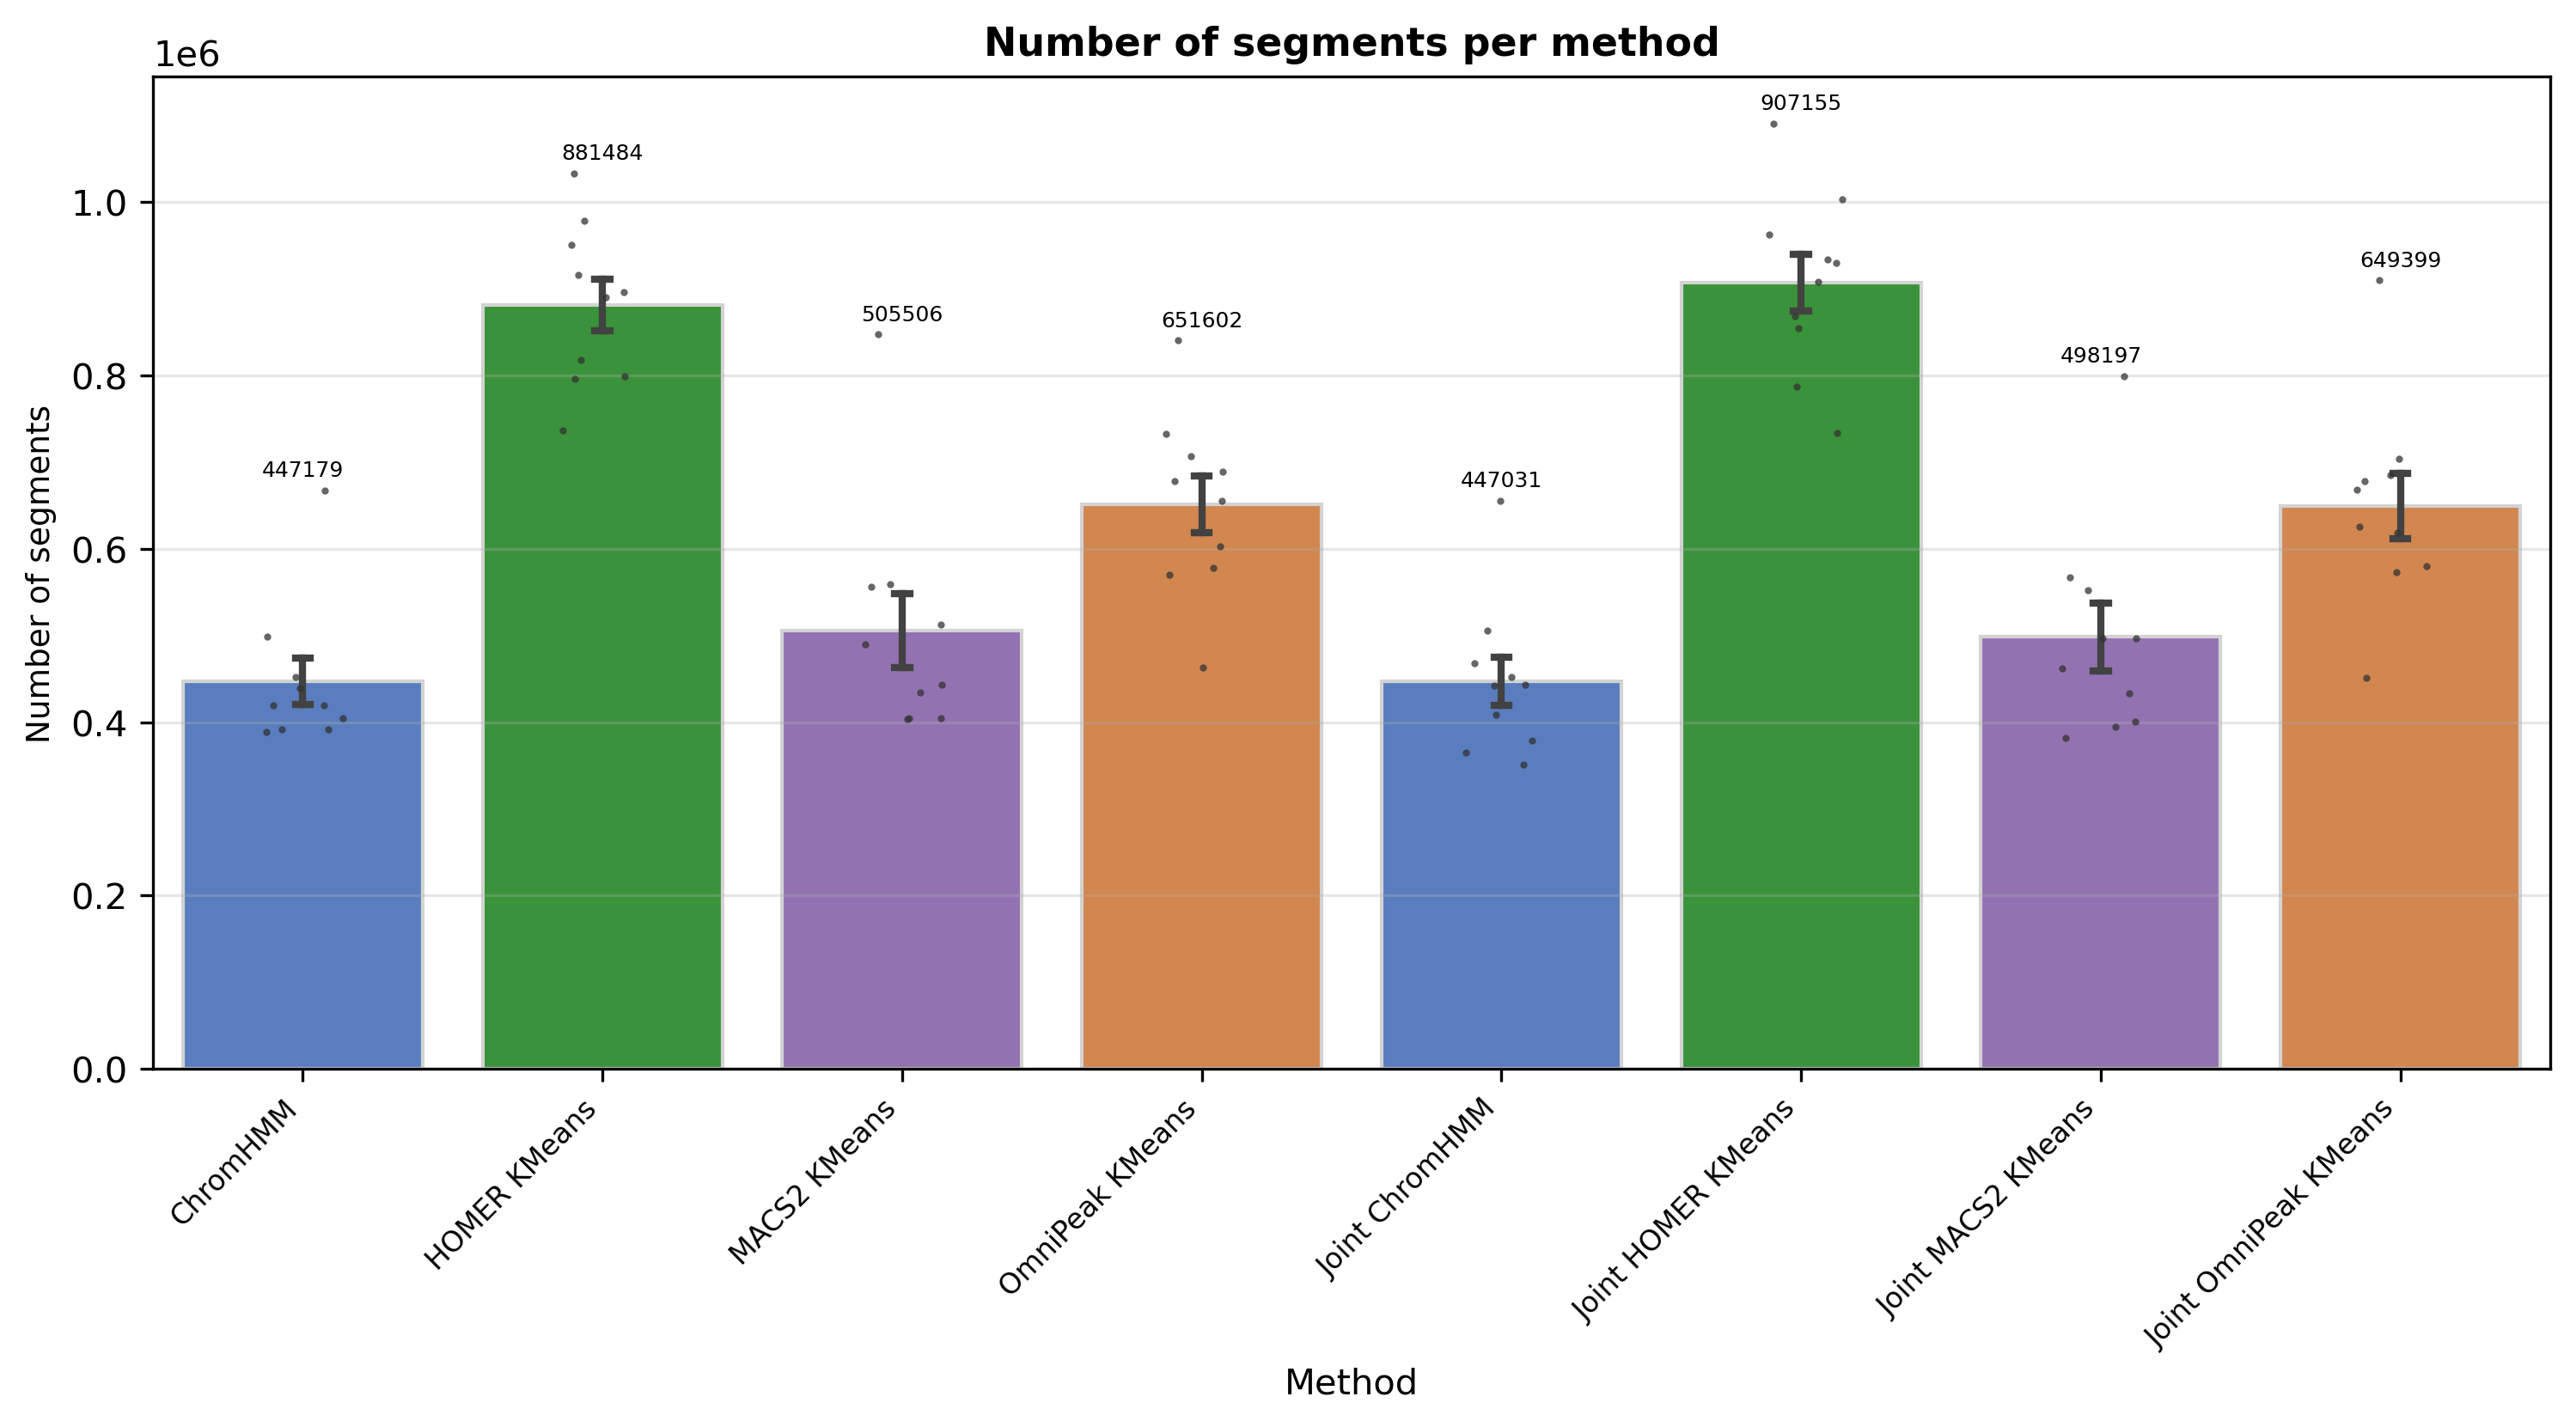

### entropy.png


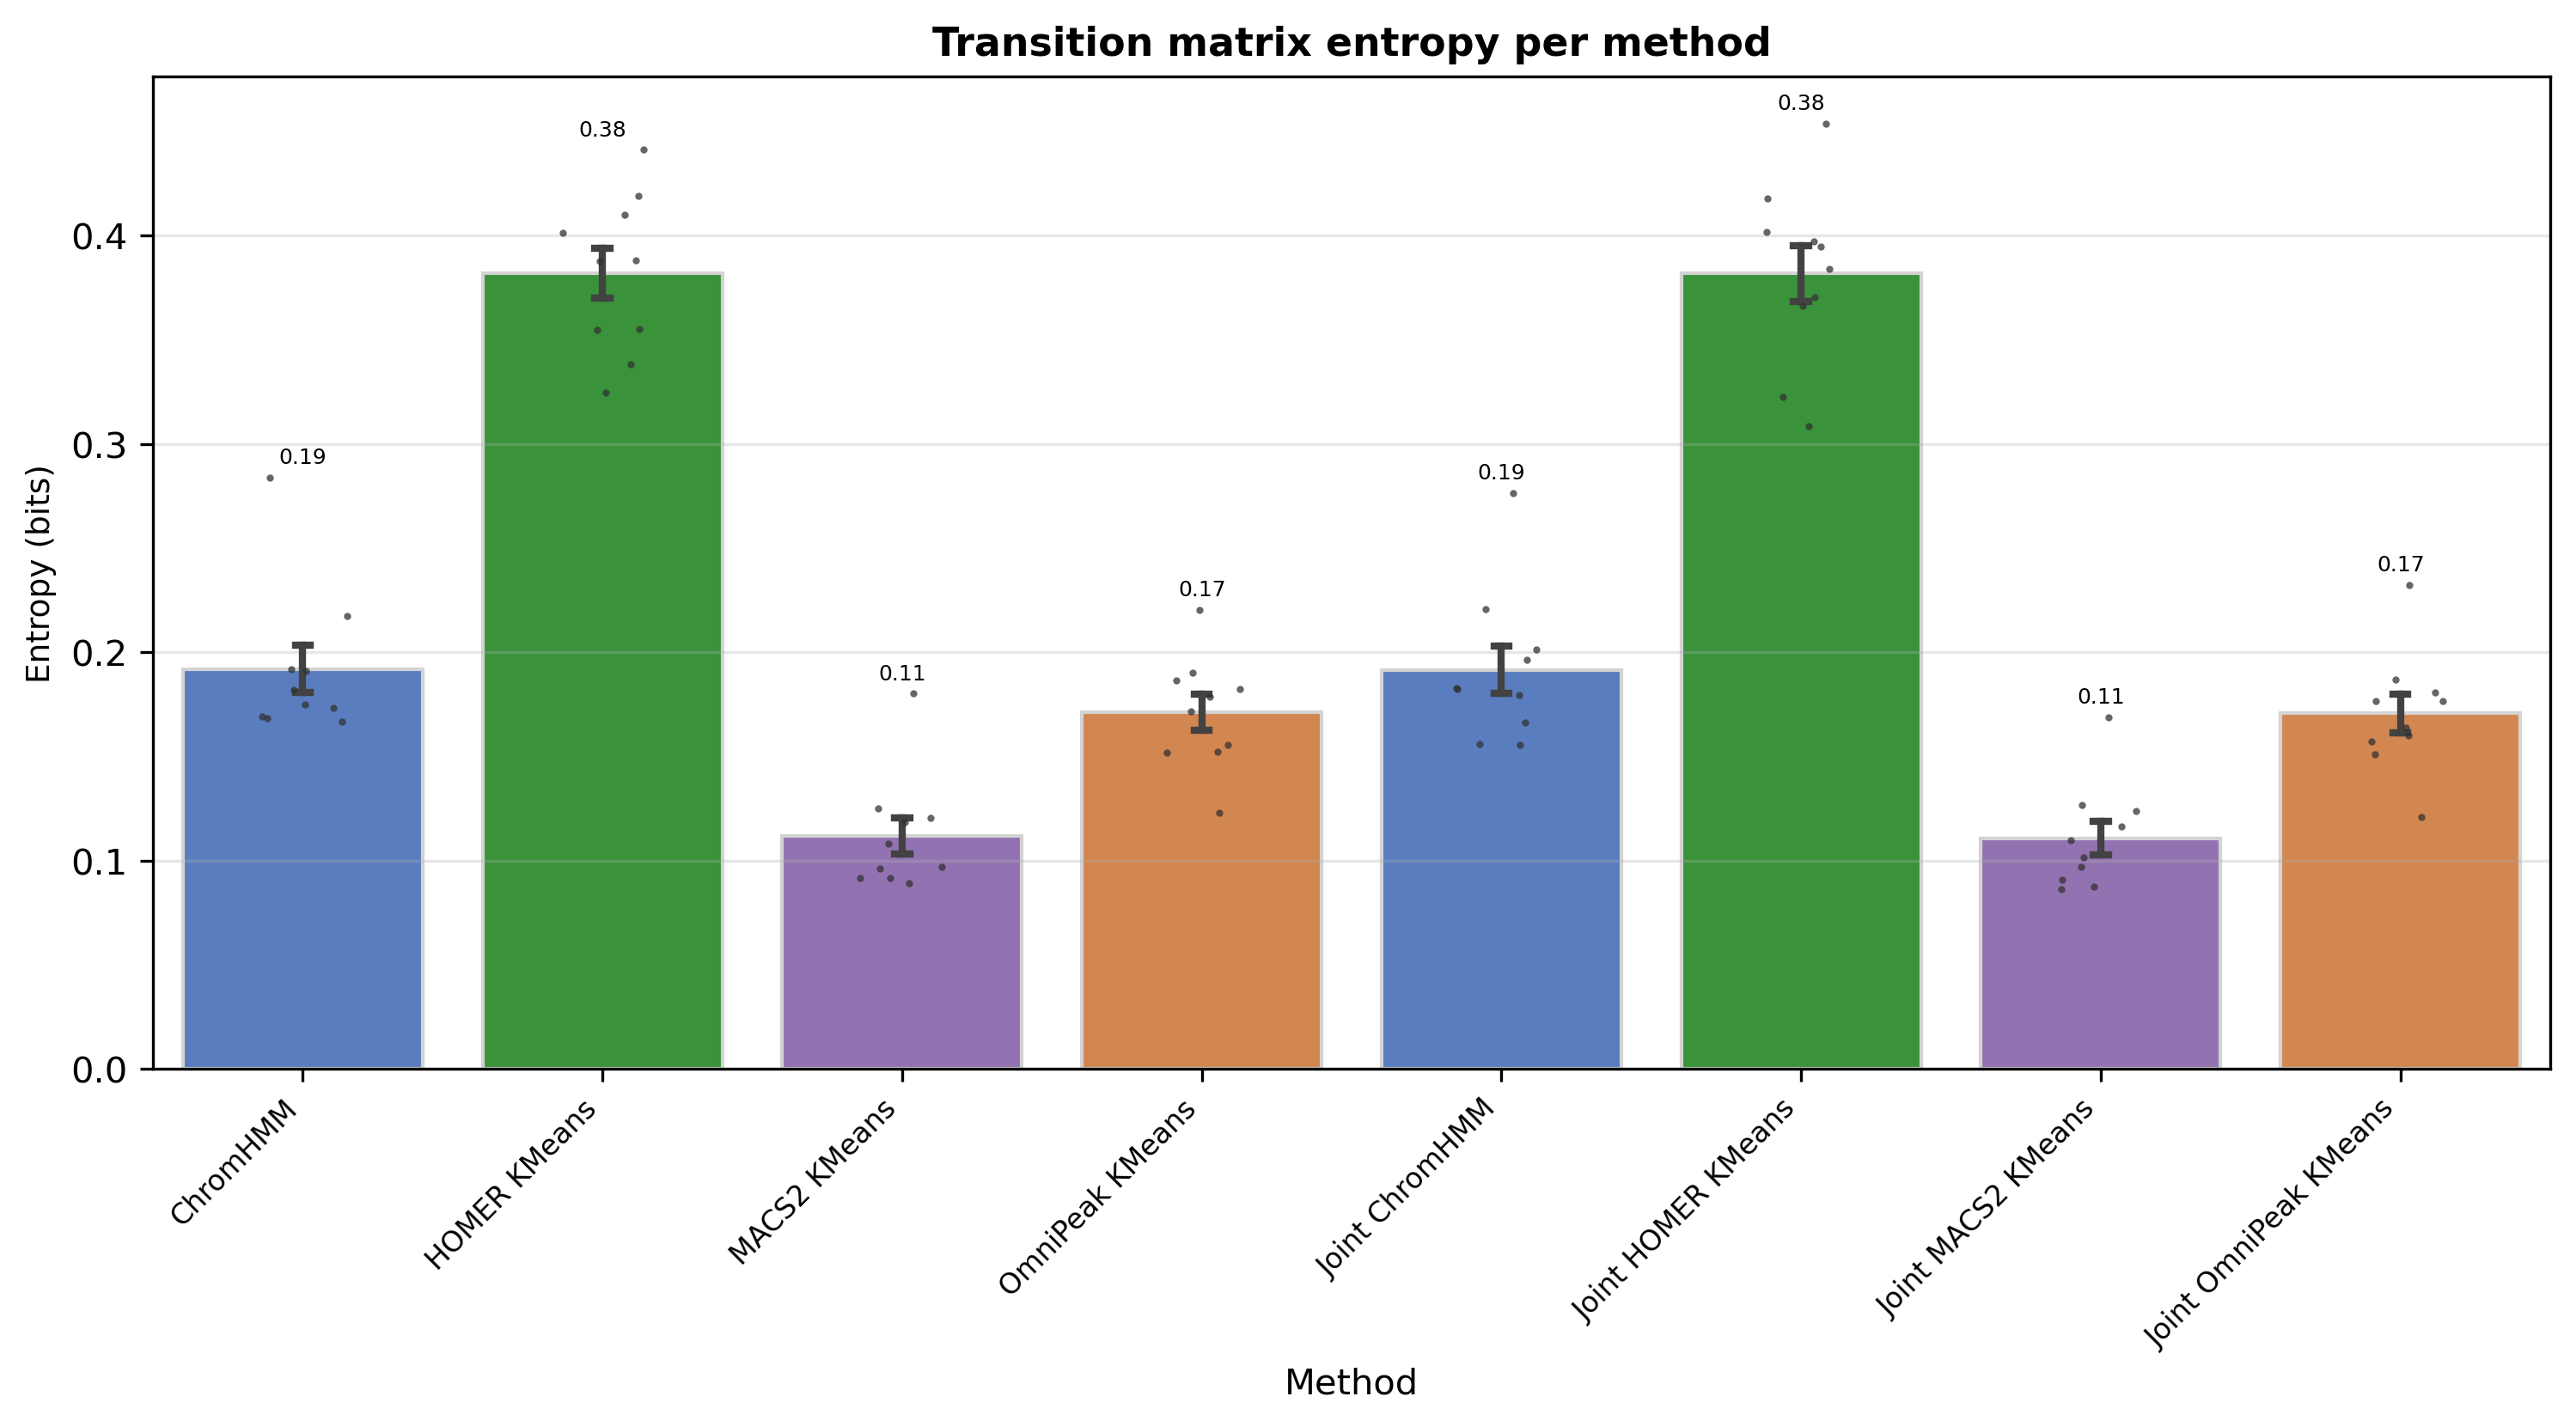

### replicate_jaccard.png


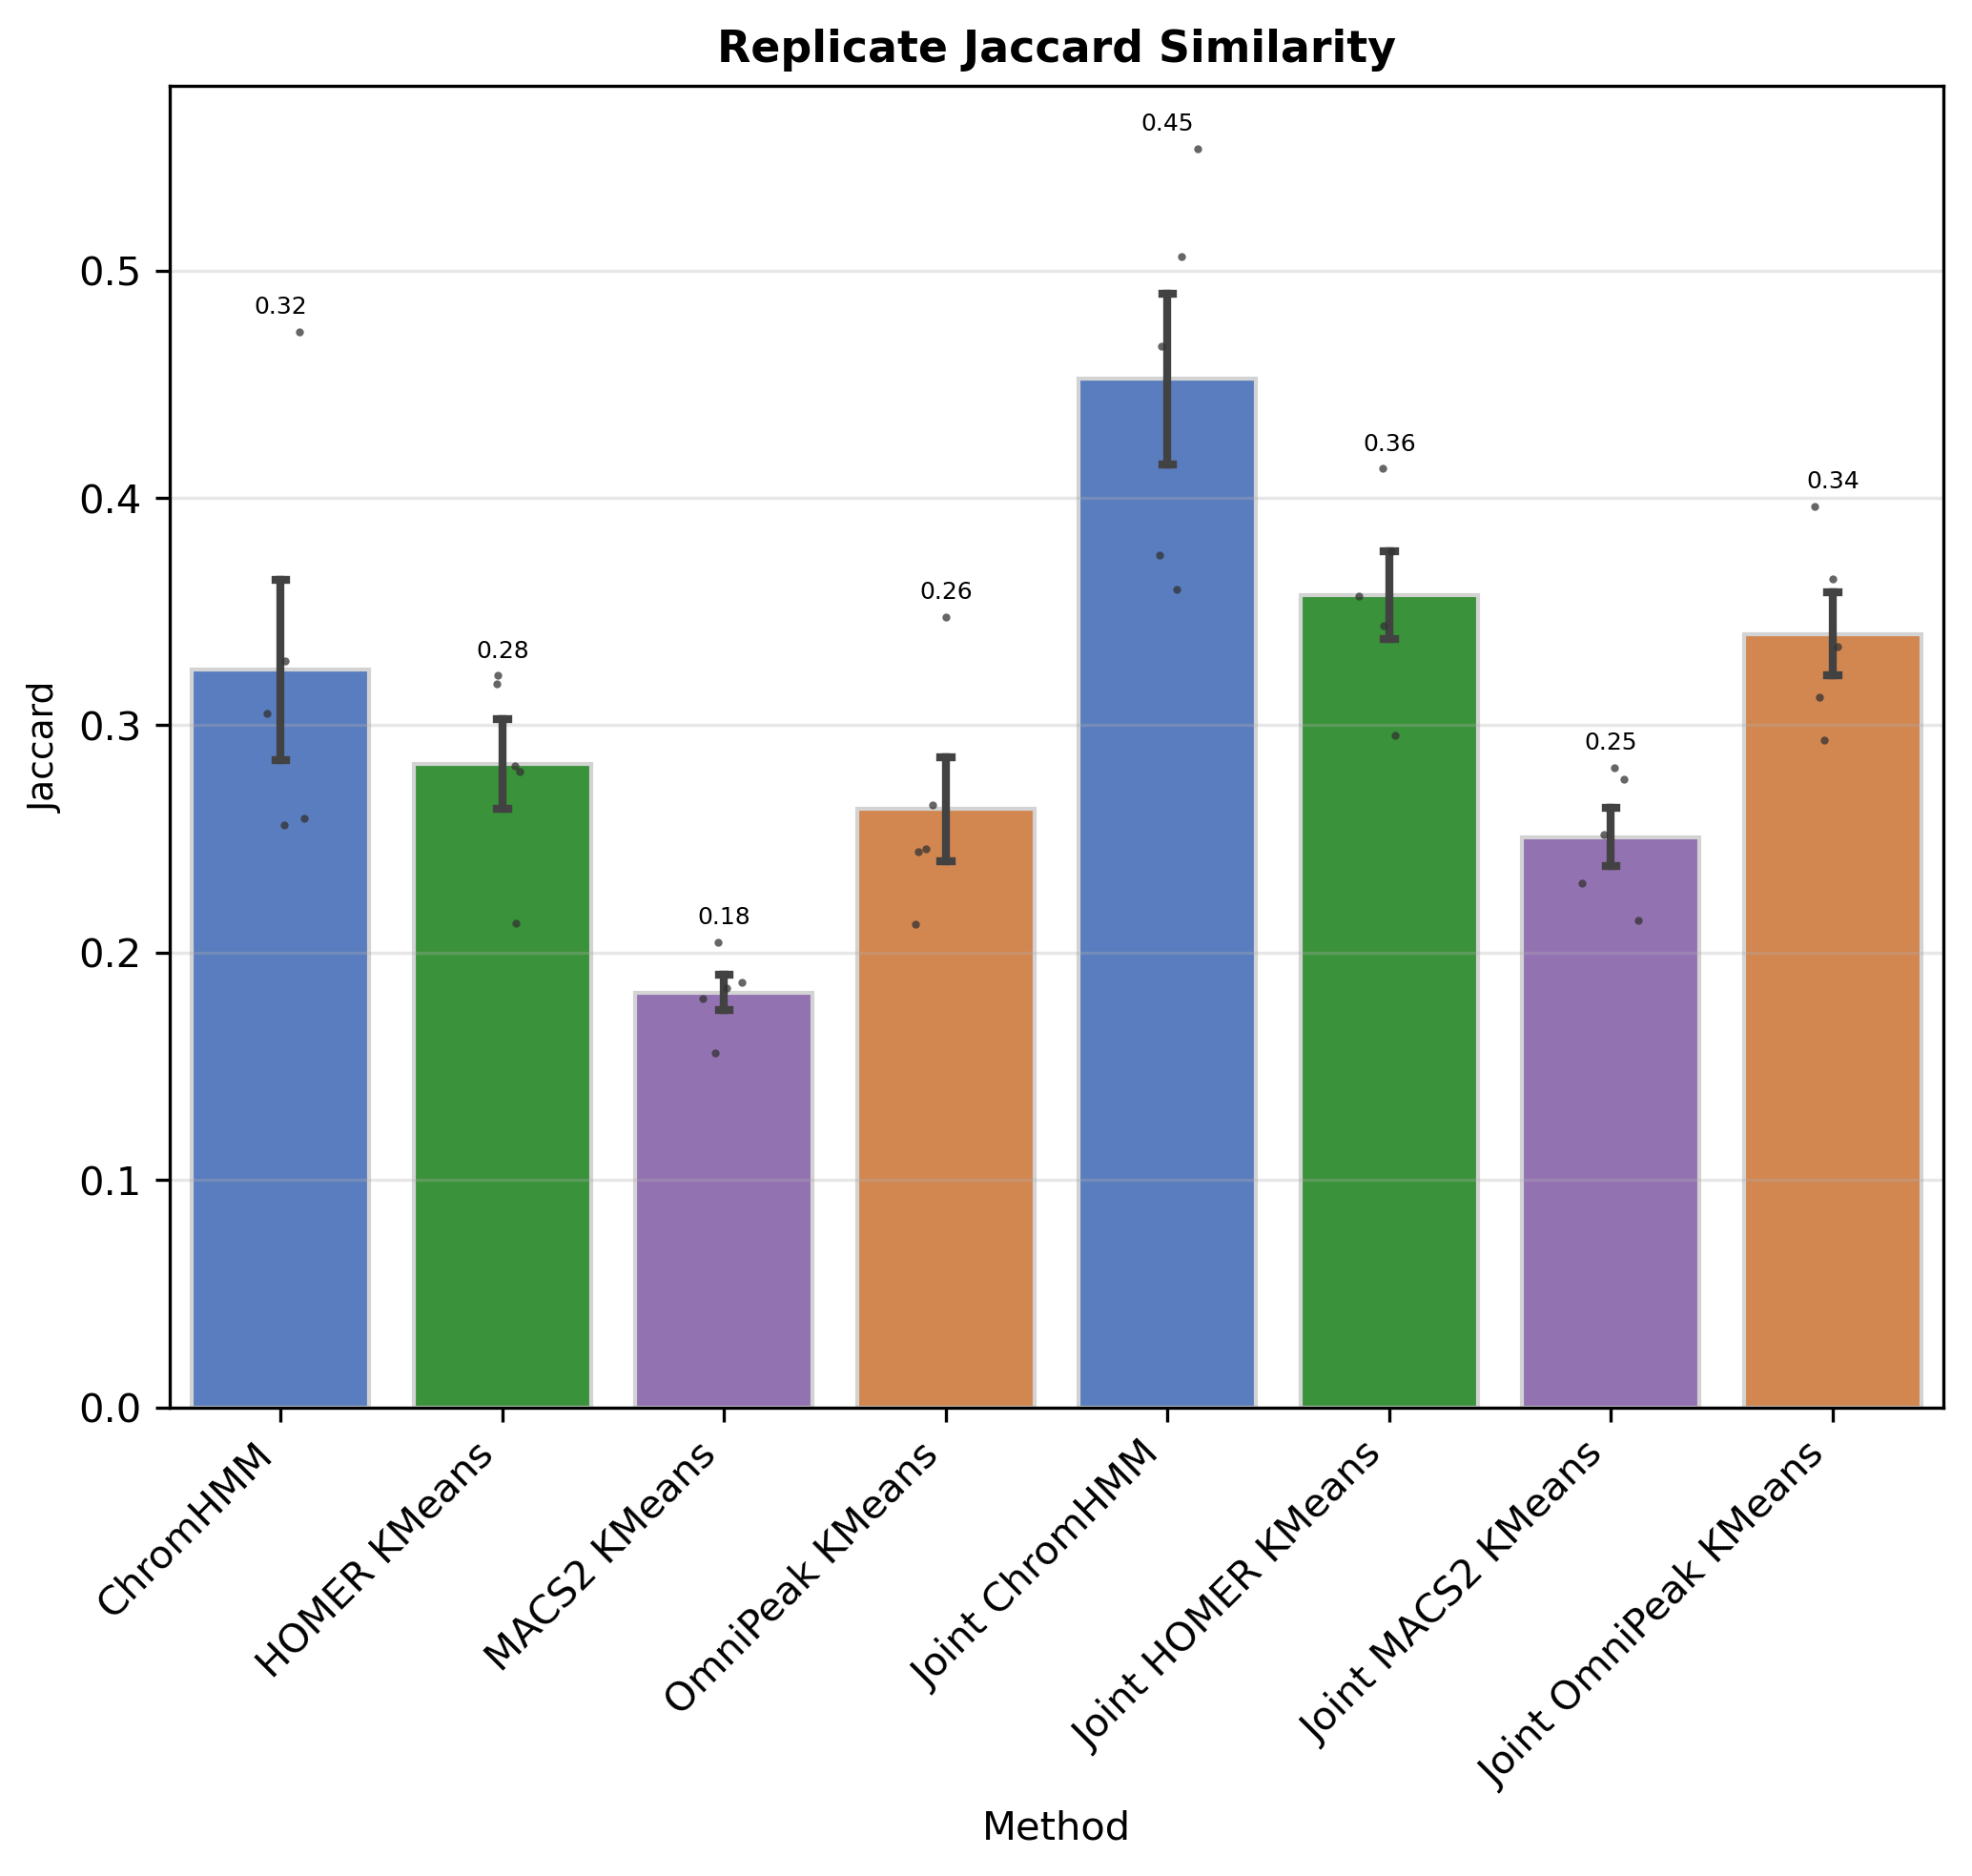

### replicate_kappa.png


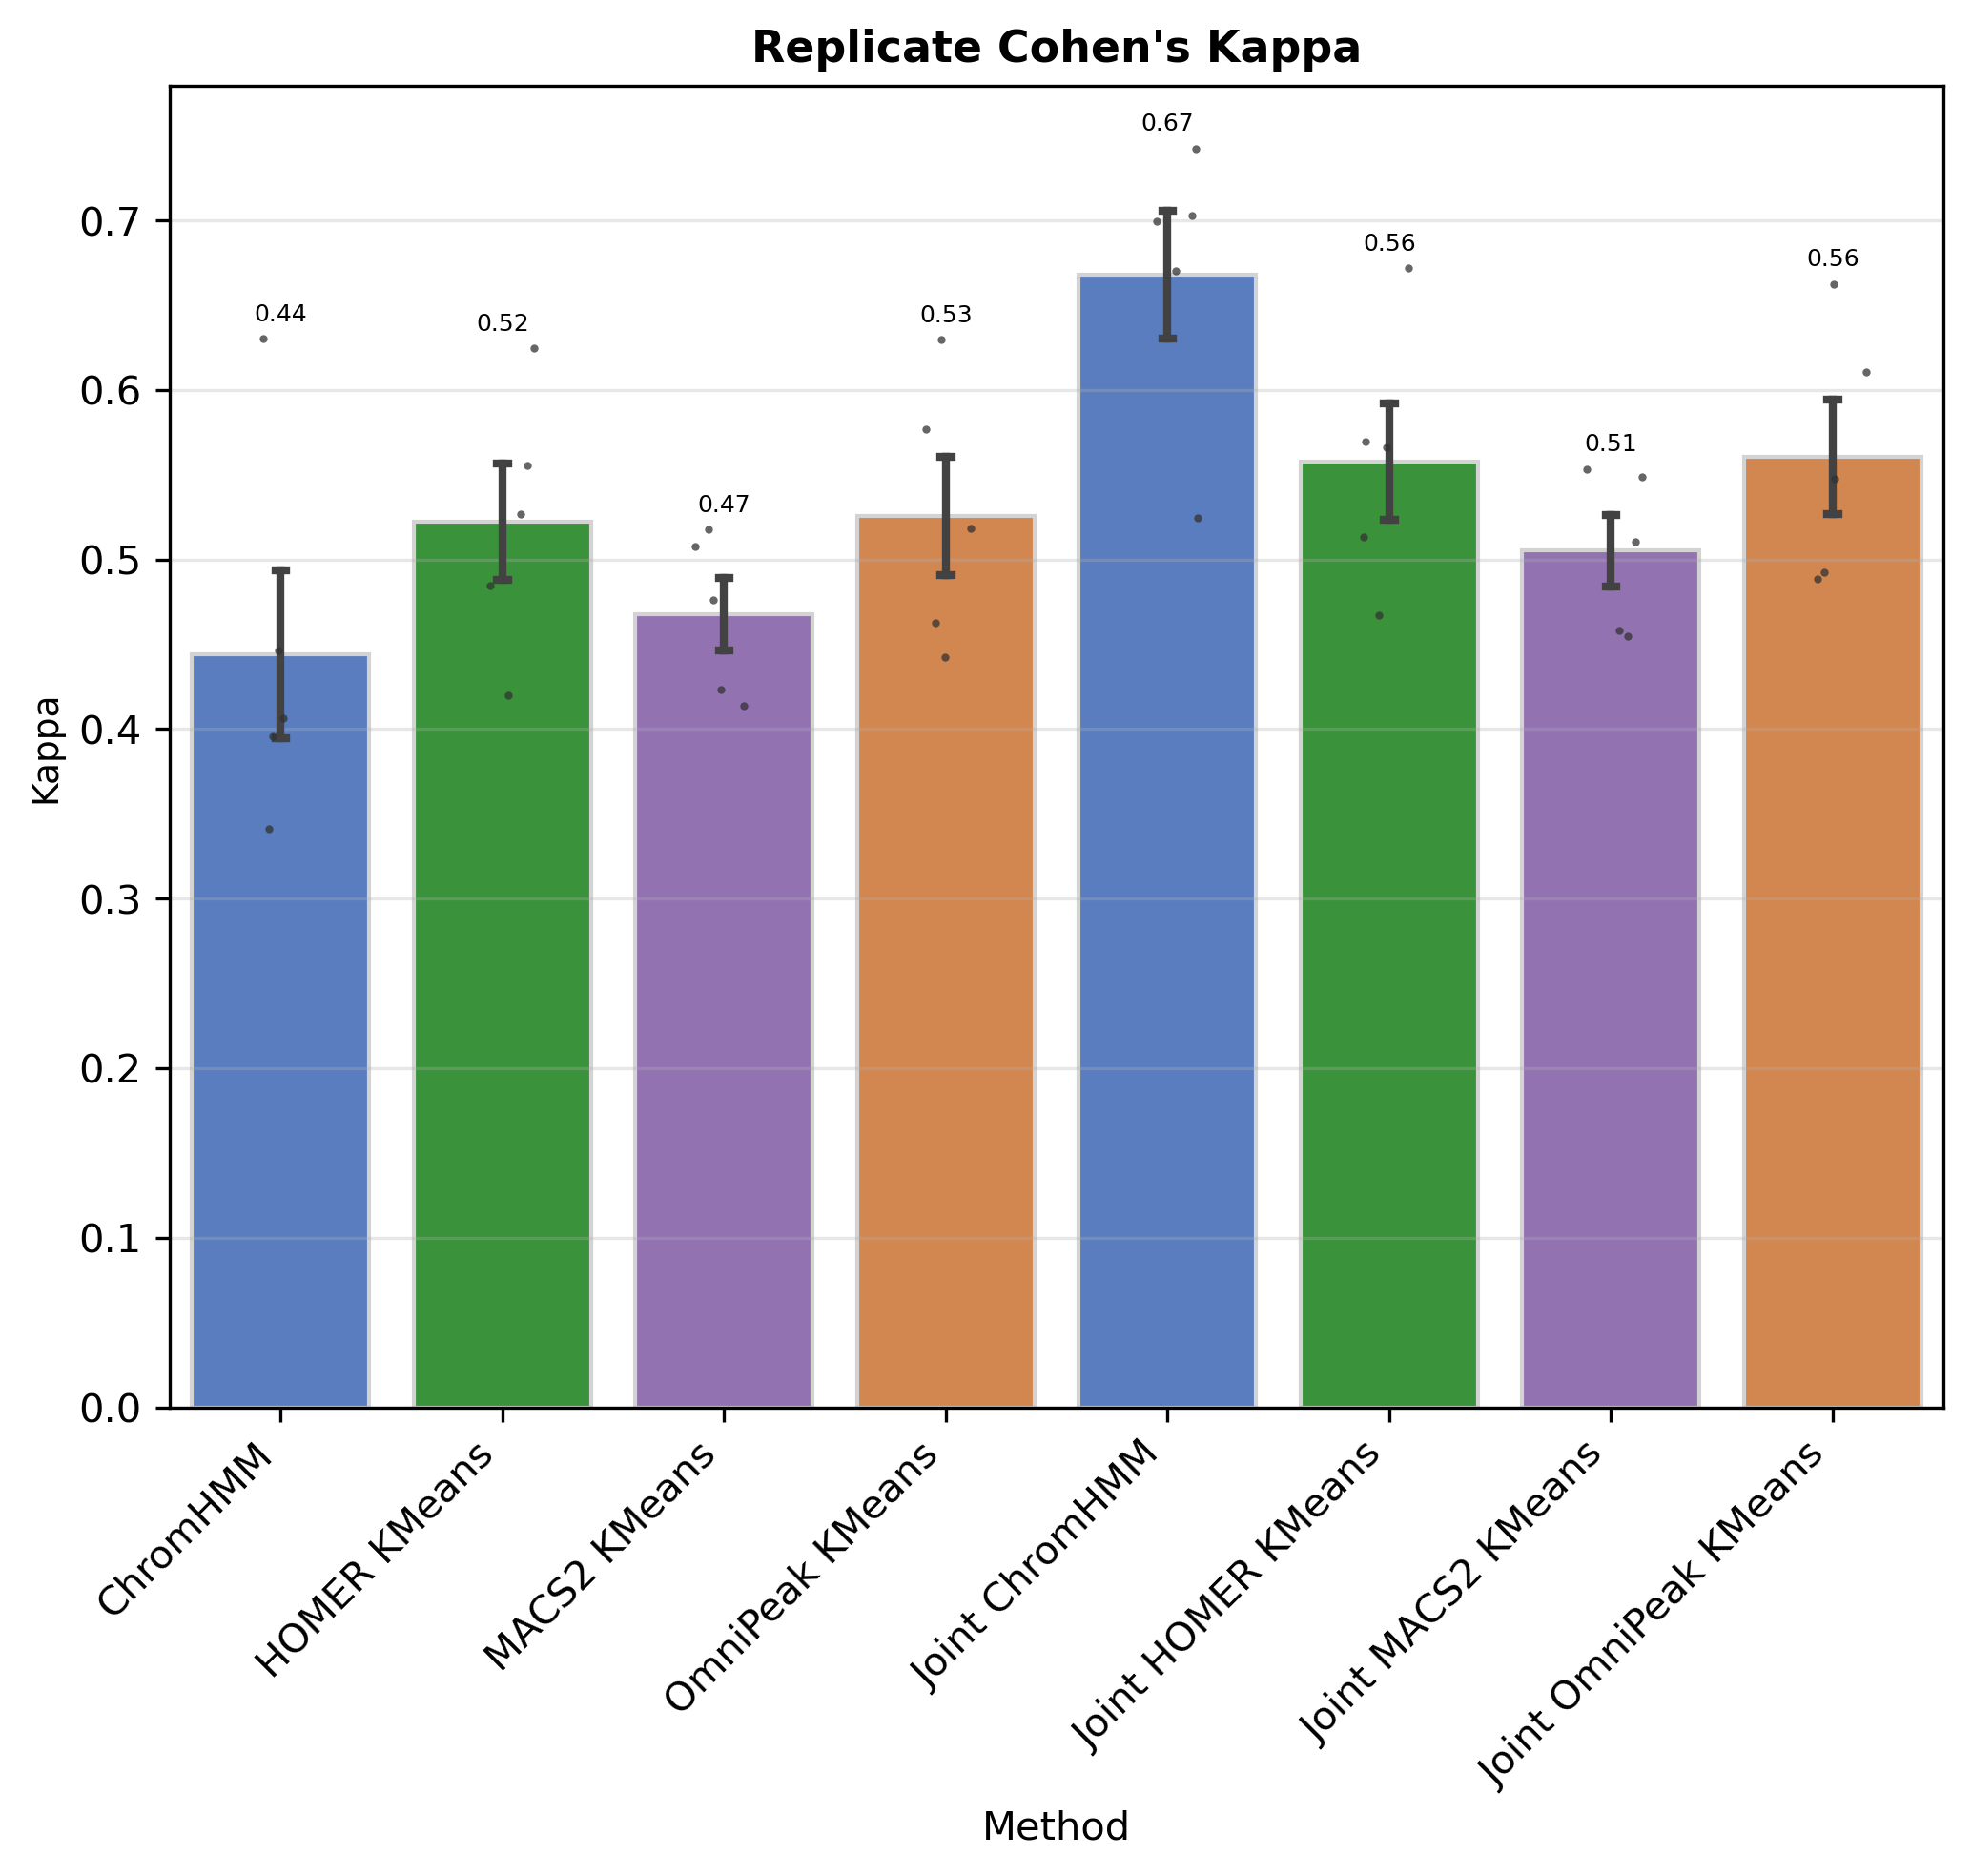

### joint_indiv_jaccard.png


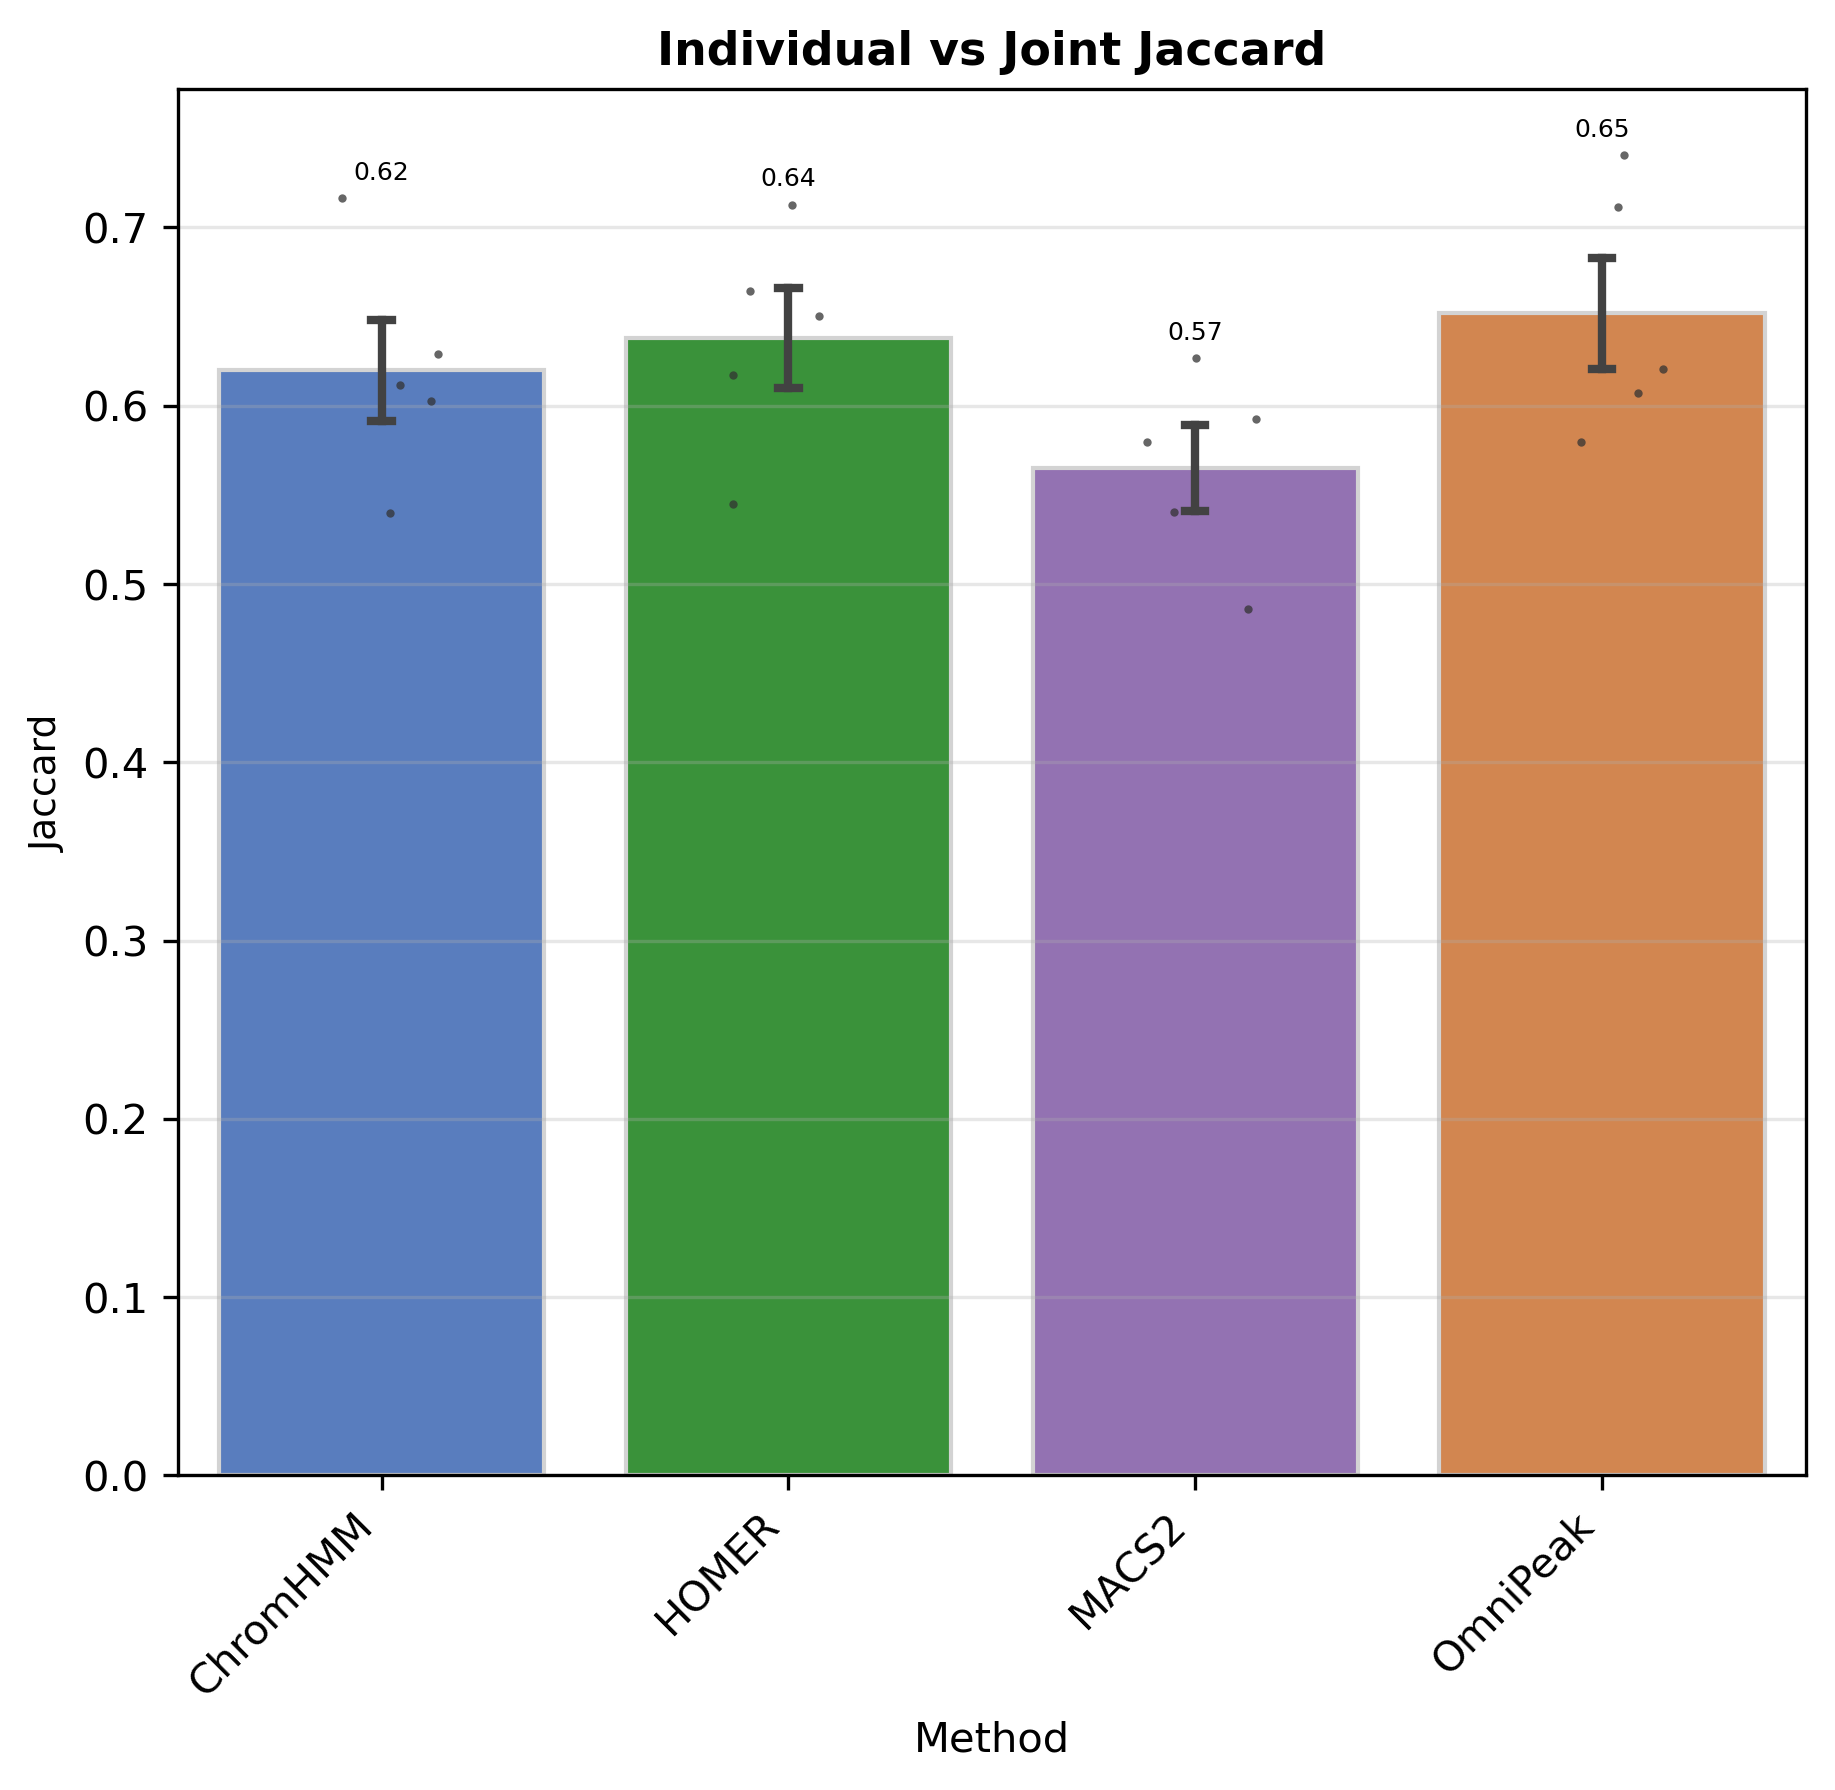

### joint_indiv_kappa.png


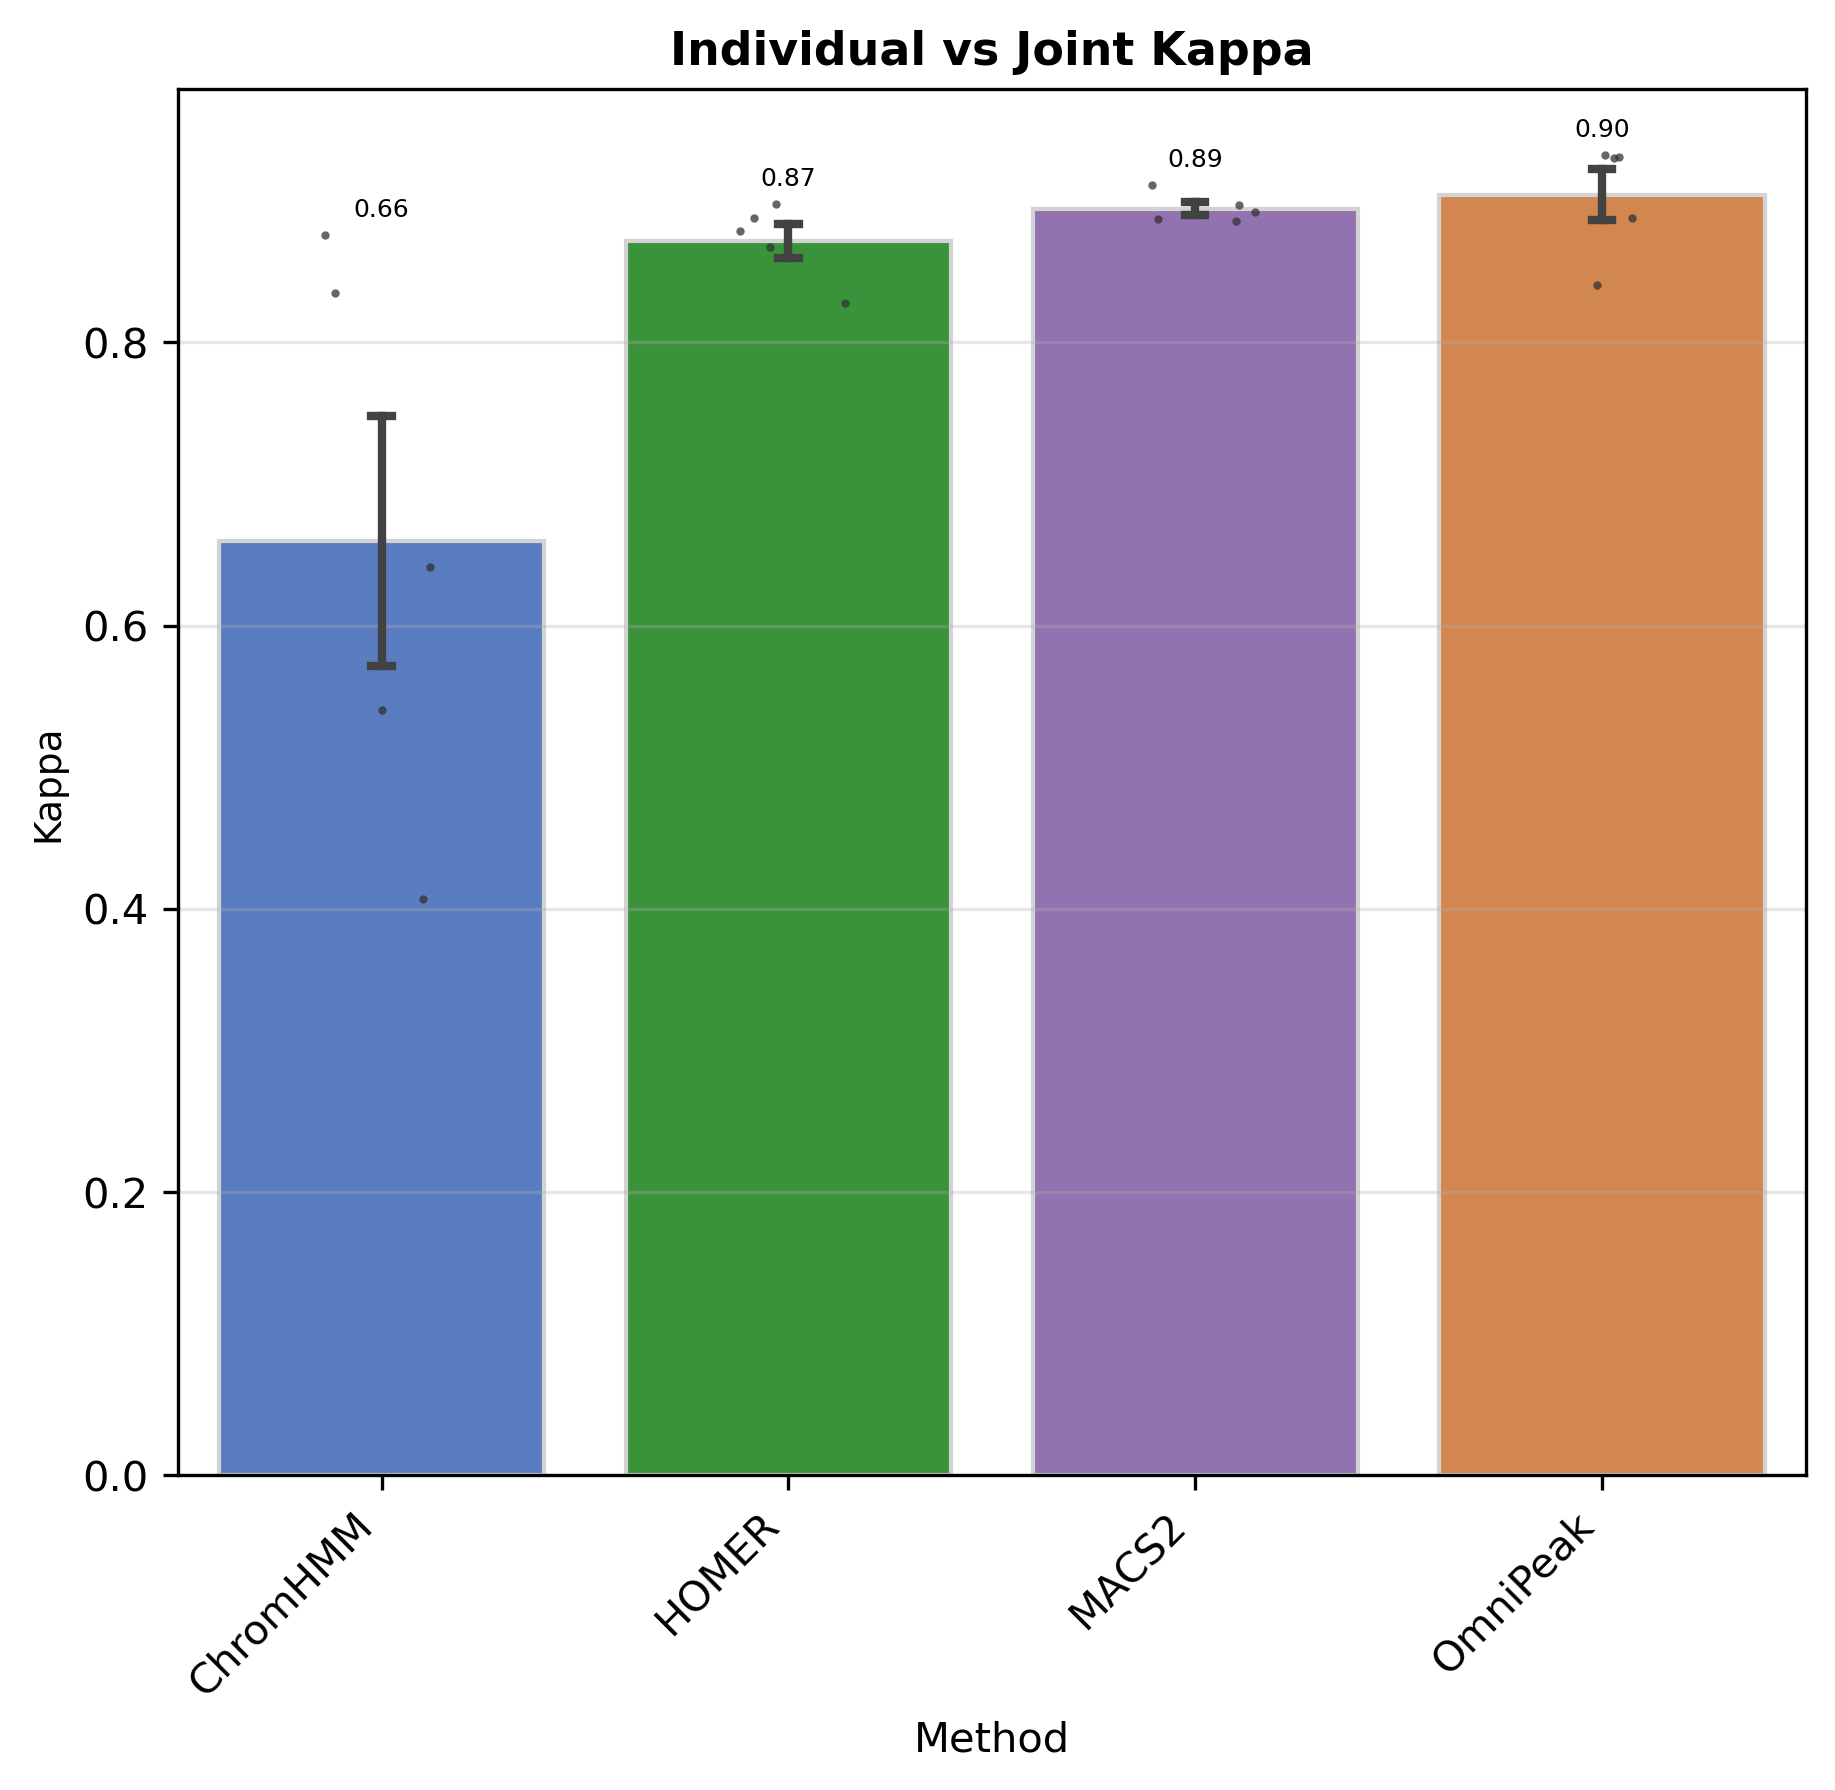

### interpretation_replicate_jaccard_noqh.png


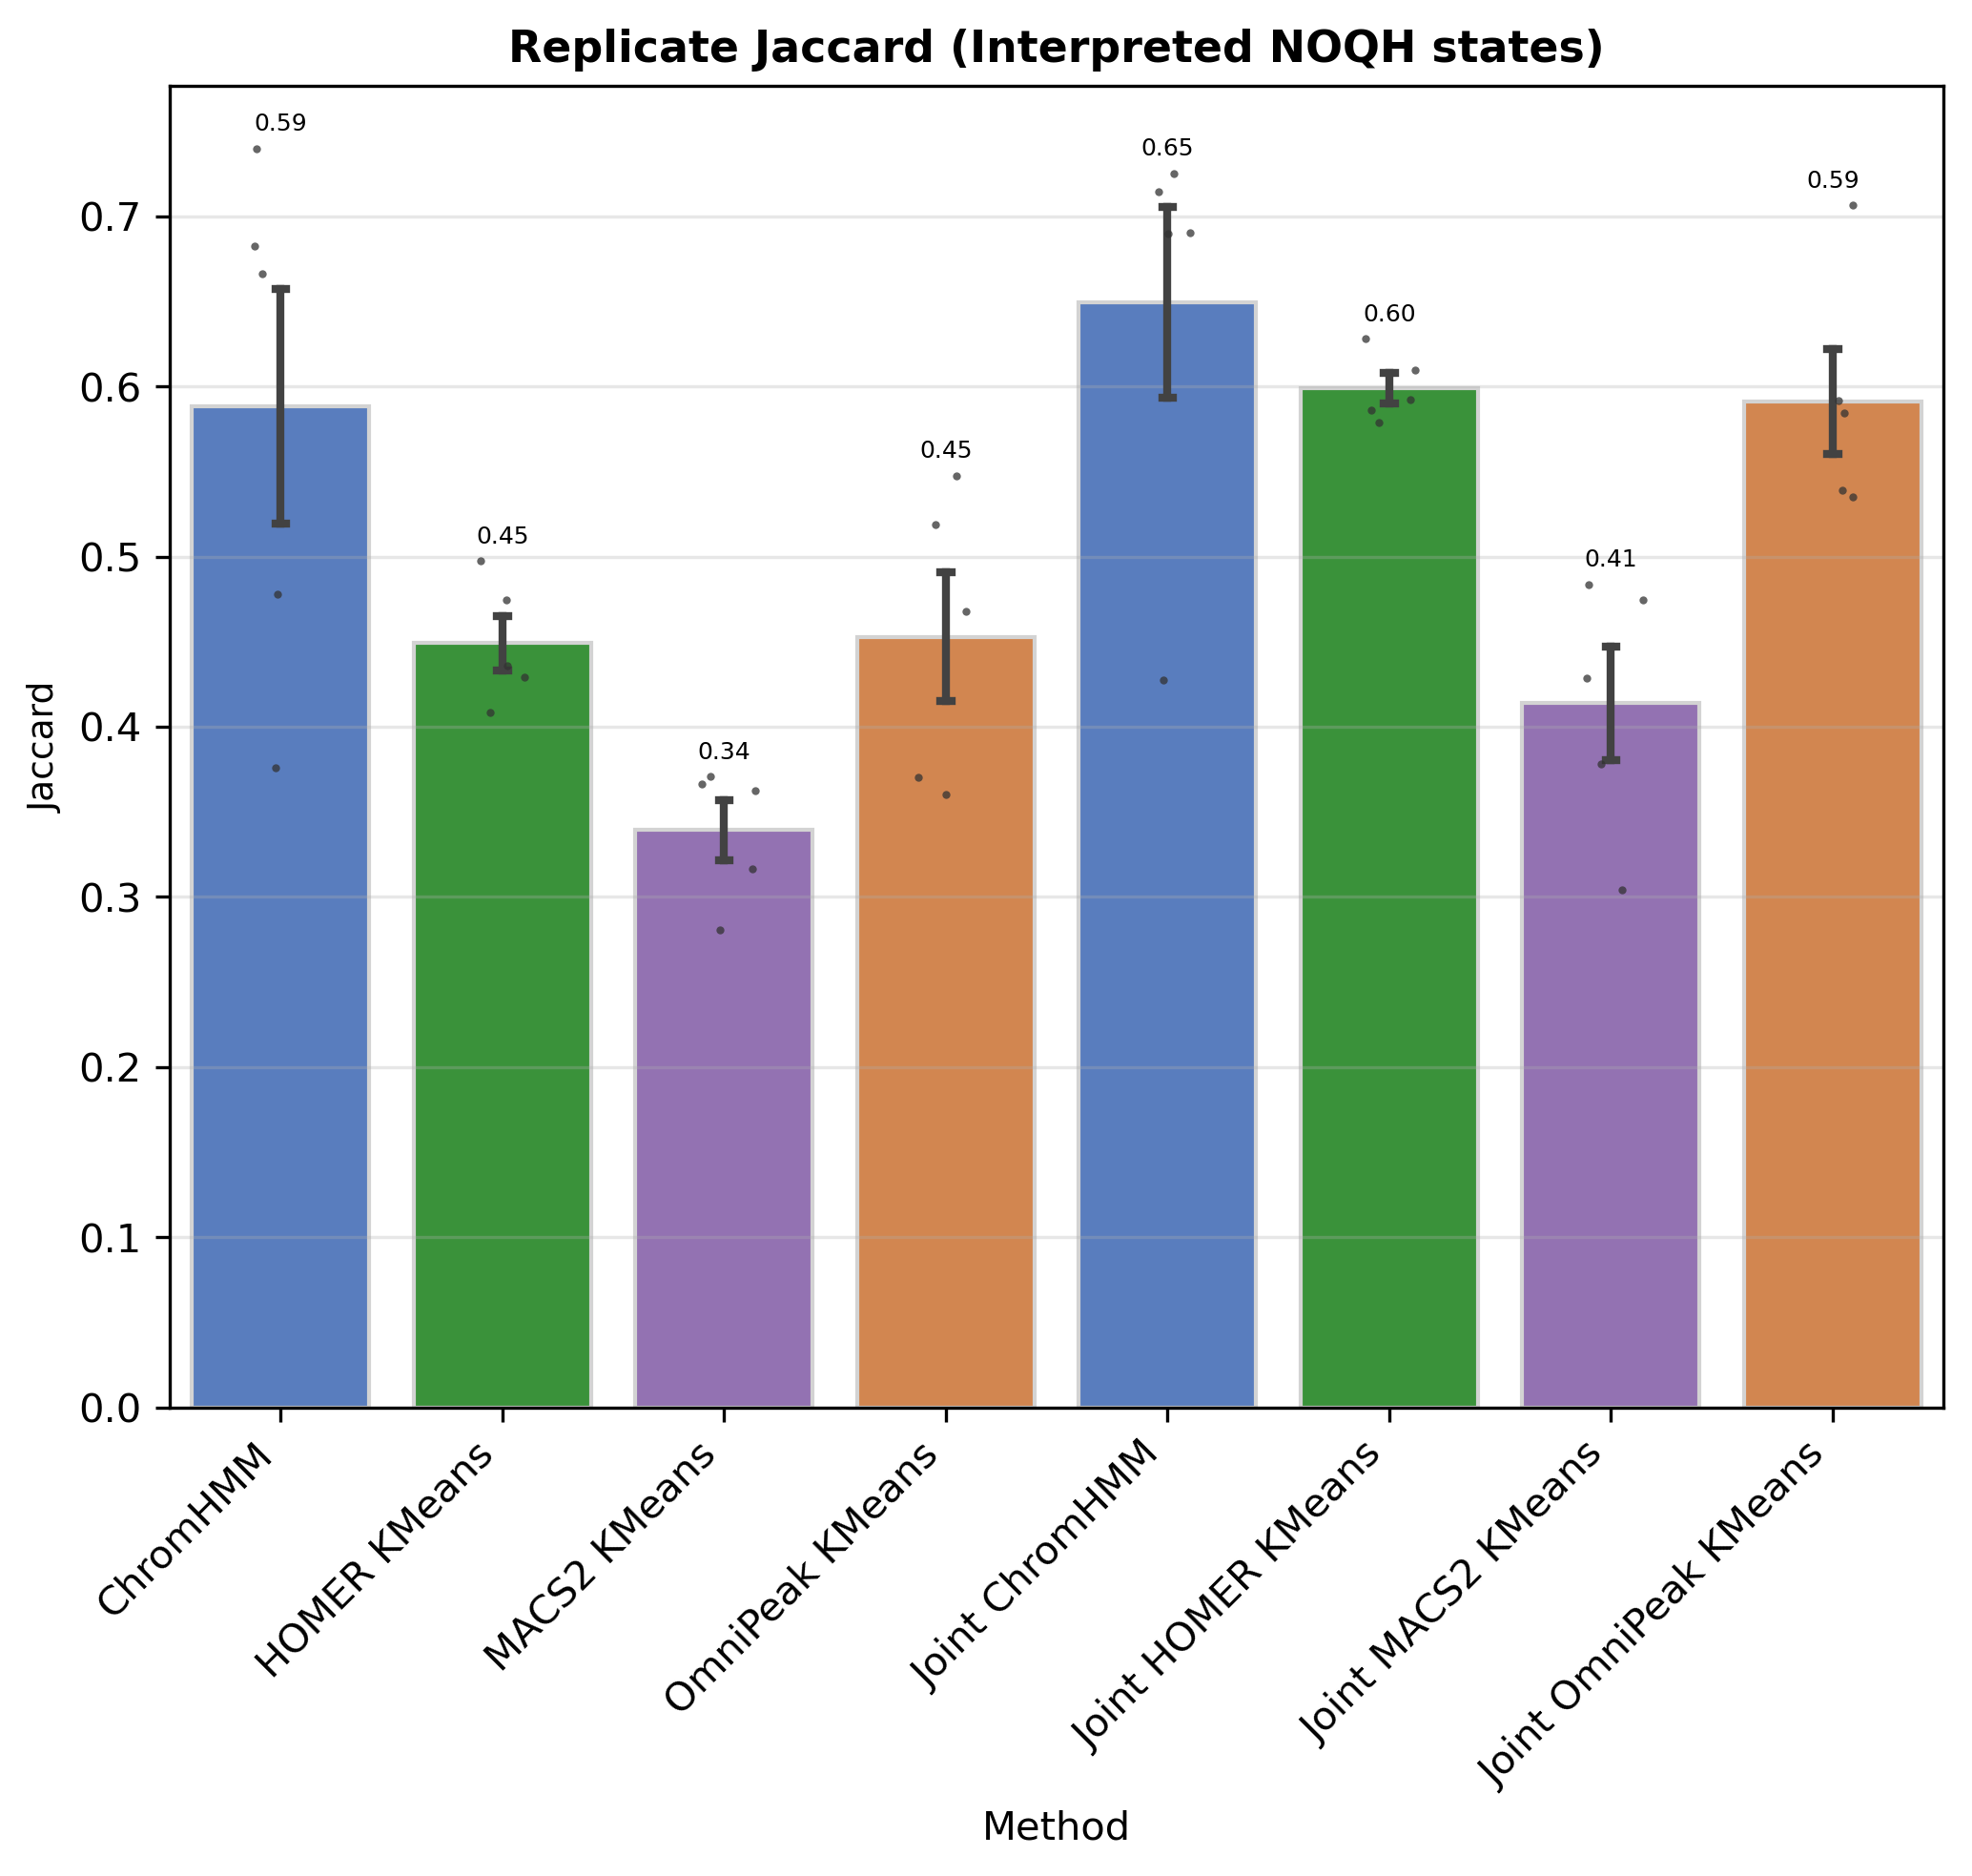

### interpretation_replicate_kappa_noqh.png


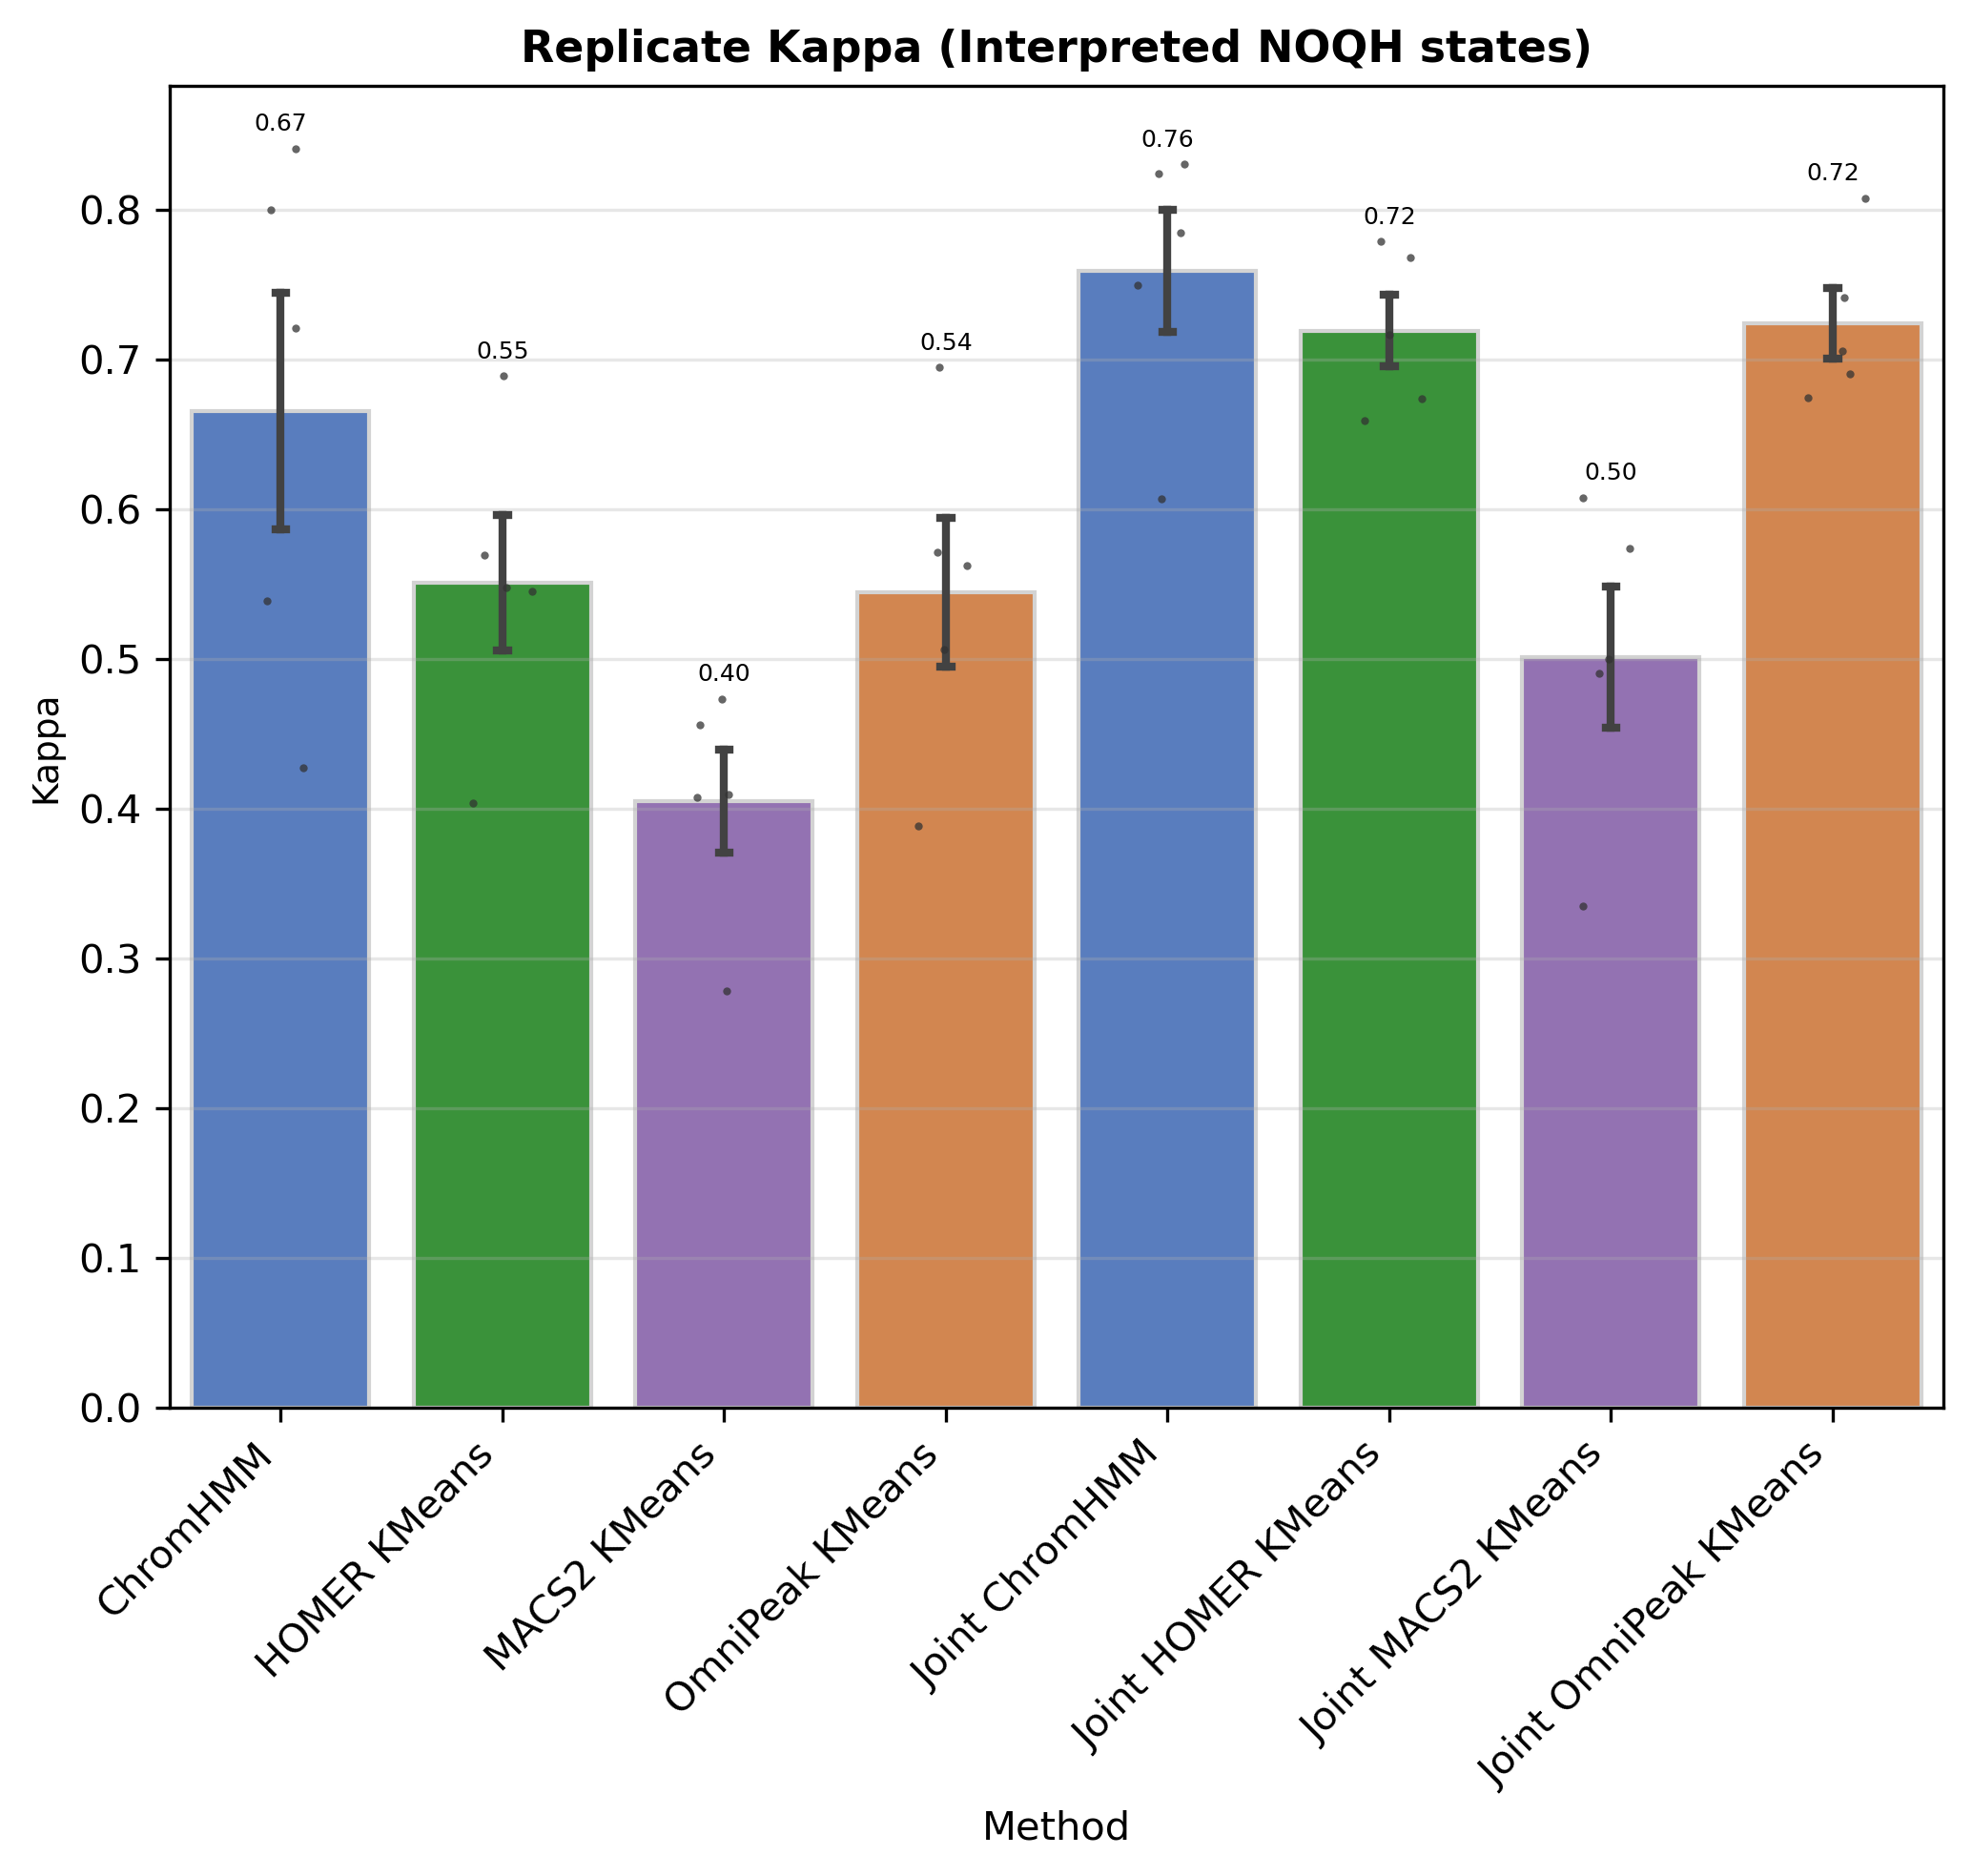

### interpretation_replicate_jaccard_per_type.png


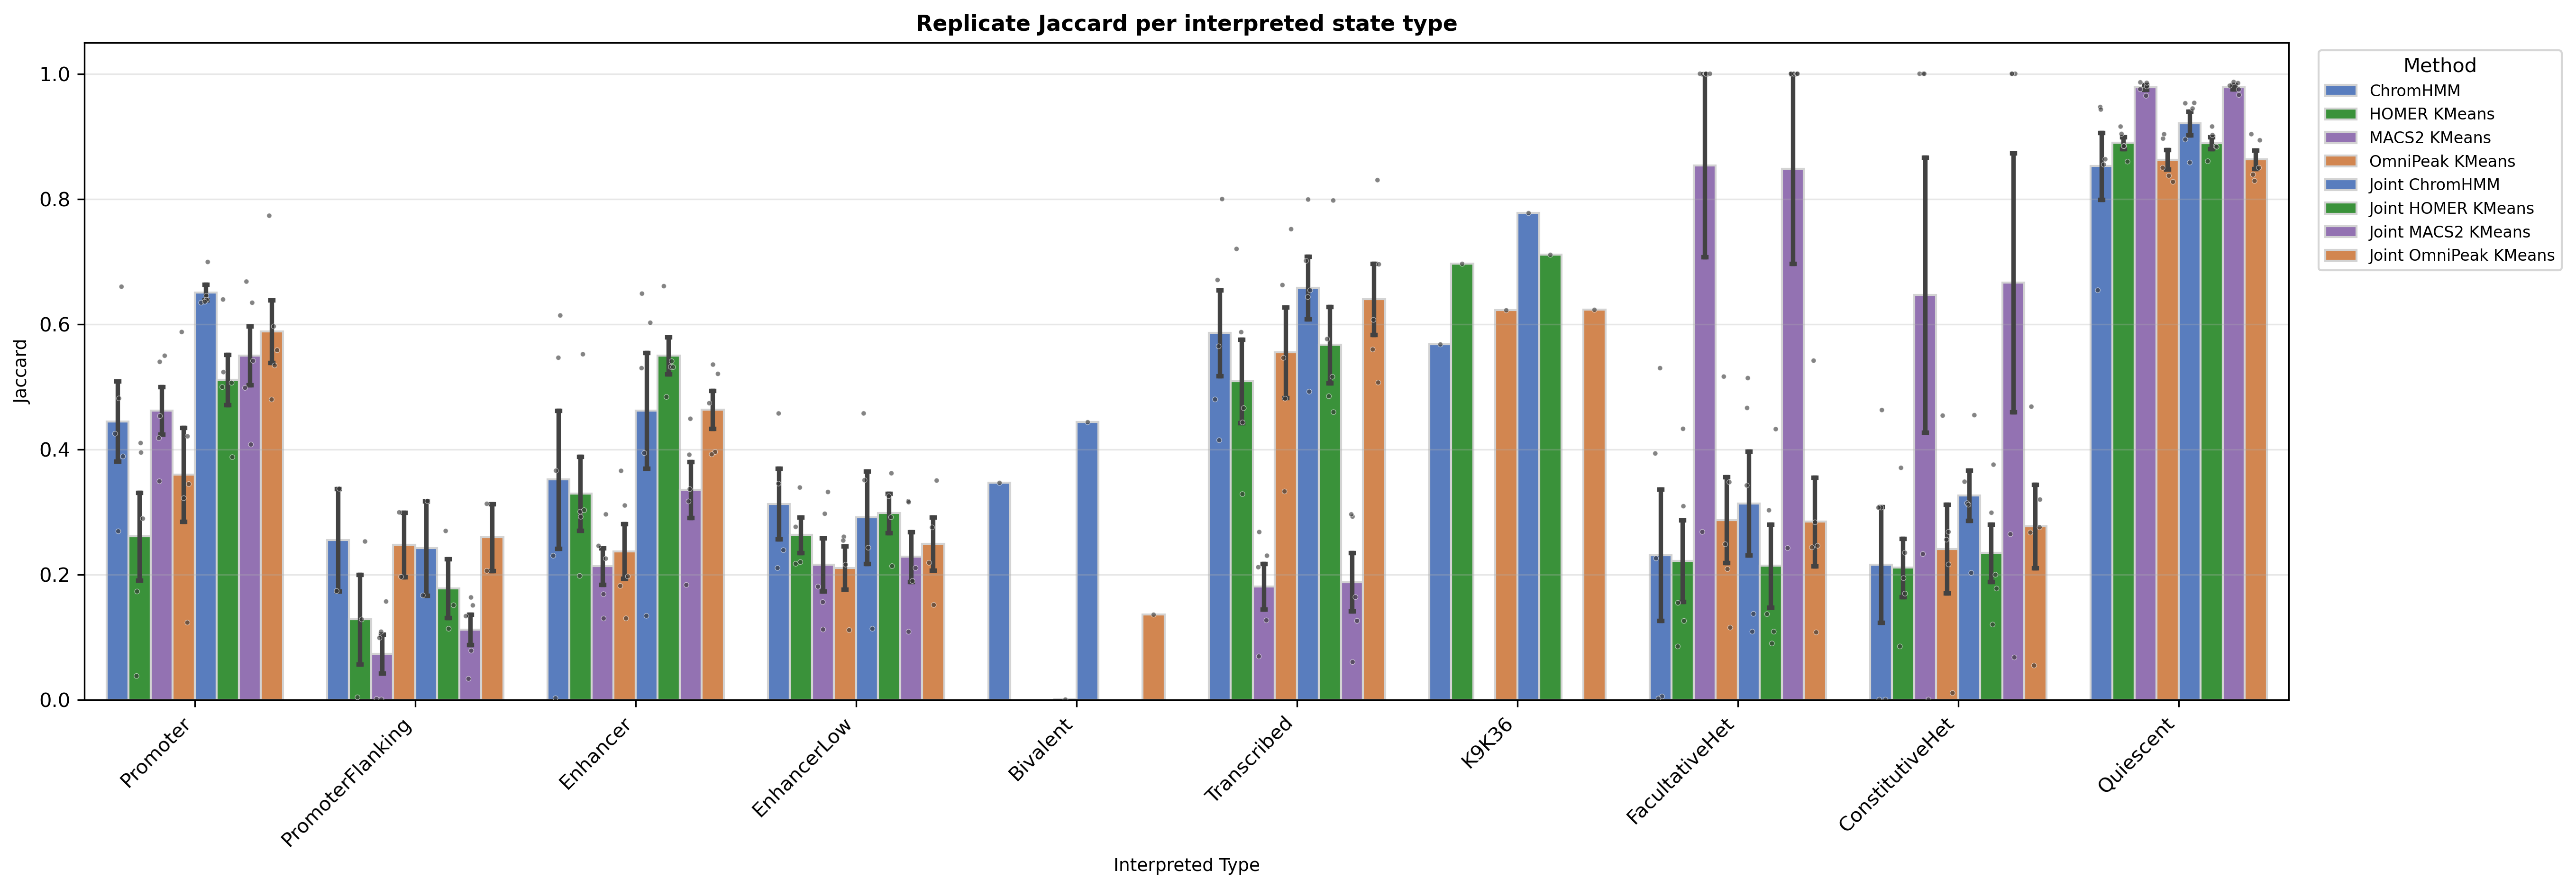

### interpretation_replicate_kappa_per_type.png


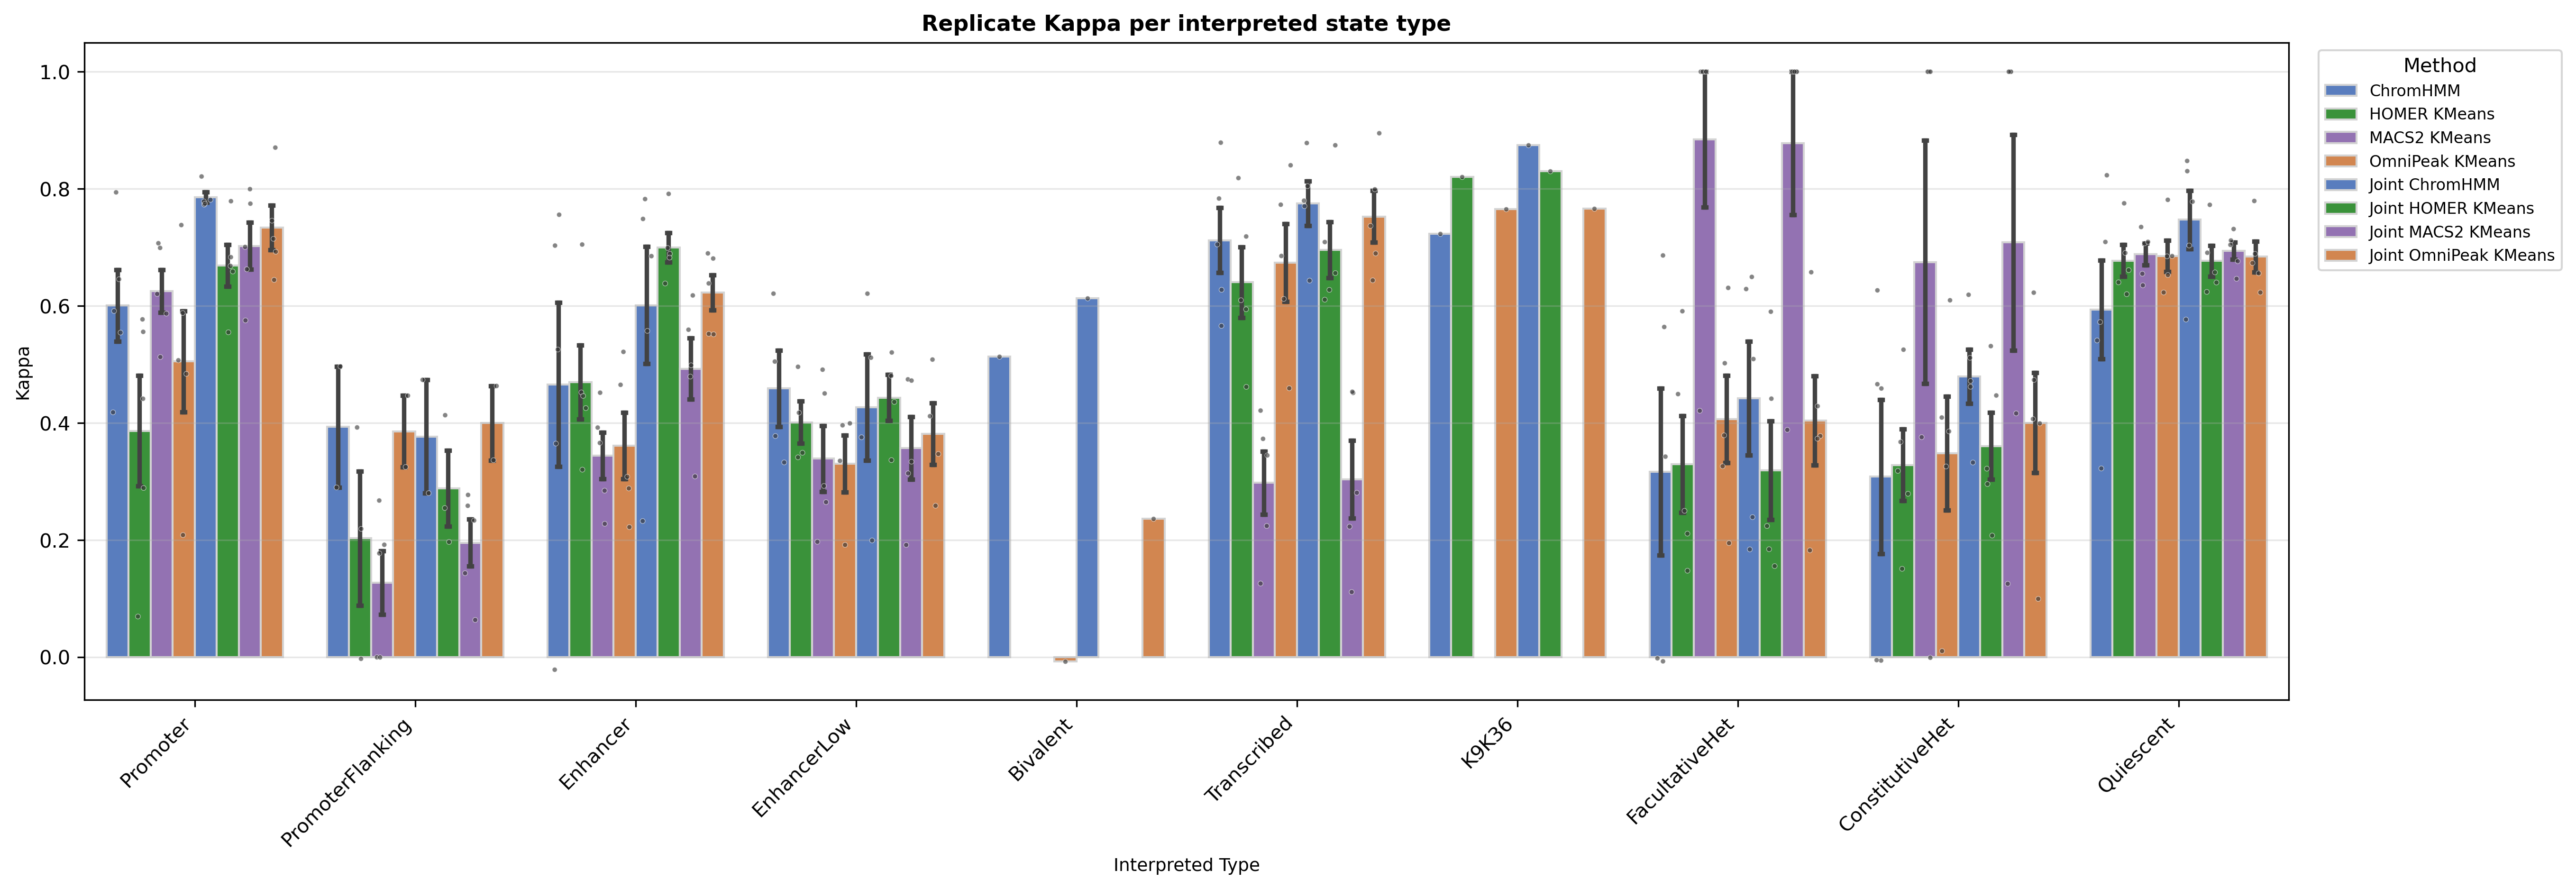

In [13]:
for img in ["n_peaks.png", "peak_length.png", "n_segments.png", "entropy.png",
            "replicate_jaccard.png", "replicate_kappa.png",
            "joint_indiv_jaccard.png", "joint_indiv_kappa.png",
            "interpretation_replicate_jaccard_noqh.png", "interpretation_replicate_kappa_noqh.png",
            "interpretation_replicate_jaccard_per_type.png", "interpretation_replicate_kappa_per_type.png",
            "interpretation_replicate_jaccard_per_type_combined.png", "interpretation_replicate_kappa_per_type_combined.png"]:
    path = f"out/summary_plots/{img}"
    if os.path.exists(path):
        print(f"### {img}")
        display(Image(filename=path))

In [14]:

# # Display per-dataset results
# for ds in DATASETS:
#     ds_header_printed = False
#     for method_key, method_name in METHOD_LABELS:
#         outdir = f"out/{ds}/matched/{method_key}"
#         emissions_png = f"{outdir}/bin_emissions/state_emissions.png"
#         enrichment_png = f"{outdir}/enrichment/enrichment.png"
#
#         if os.path.exists(emissions_png) or os.path.exists(enrichment_png):
#             if not ds_header_printed:
#                 print(f"### Dataset: {ds}")
#                 ds_header_printed = True
#             print(f"#### Method: {method_name}")
#             if os.path.exists(emissions_png):
#                 display(Image(filename=emissions_png))
#             if os.path.exists(enrichment_png):
#                 display(Image(filename=enrichment_png))